# Crazyflie Craziness 2.0 — Trajectory Tracking & Autonomous Flight

Companion notebook to the report **"Trajectory Tracking and Autonomous Flight on the Crazyflie 2.1+"**, built directly from the project repo: **[Raghs-7/crazy-flies (branch: raghav)](https://github.com/Raghs-7/crazy-flies/tree/raghav)**.

All code cells below use **`%%writefile`** to drop the *actual, unmodified* scripts from the repo onto disk exactly as they exist on GitHub — nothing rewritten or simplified. All plots shown are the **actual output plots from the repo / report** (not synthetic placeholders), embedded so they render regardless of environment.

**Layout:**
1. Drone assembly & setup checks
2. Single-drone trajectories — circle & figure-8 (`single drone/`)
3. Multi-drone circle — two Crazyflies, π phase separation (`multi-drone/two_drone_circle/`)
4. Multi-drone tilted ellipse (`multi-drone/two_drone_tilted ellipse/`)
5. Swarming — Boids algorithm (`multi-drone/swarming/`)
6. Trial launch scripts (`trial_launchs/`)
7. PID tuning notes
8. Report figures — baseline vs. tuned flight performance
9. Common issues & troubleshooting

> **Note on running this notebook:** most cells below use `%%writefile` — they just write the real repo script to disk (safe to run, no hardware needed). Actually *flying* any script requires cflib + a Crazyradio PA + the drone/anchors powered on, so those `!python ...` run cells are commented out by default. Scripts marked **(--sim available)** can be run in software-only simulation mode.


In [ ]:
# Environment setup
# !pip install cflib numpy matplotlib pandas

import os
os.makedirs('scripts', exist_ok=True)
os.chdir('scripts')
print("Working directory:", os.getcwd())


## 1. Drone Assembly & Setup Checks

From the report (section 1):

- **LPS Deck** (UWB positioning) + **Crazyradio PA** for wireless comms.
- **4 LPS anchors** configured in **TDoA2 mode**, mounted at varying heights across the flight volume for better altitude estimation; measured X/Y/Z entered into the anchor position table via the LPS Configuration Tool.
- **Cfclient check**: compare the client's reported X/Y/Z against the drone's real-world position, keep the error within **±10 cm** before every flight — checked before every flight session. If it exceeds that: check anchor positions, line-of-sight, and the position estimate before flying.


## 2. Single-Drone Trajectories

Source: `single drone/circle trajectory/` and `single drone/figure-8 trajectory/` in the repo.


### 2.1 Circle Trajectory — README (repo)

# Single Drone Circular Trajectory

## Overview

This module demonstrates autonomous circular trajectory tracking using a single Crazyflie 2.x drone. The trajectory is executed using the Python cflib High-Level Commander interface, which generates position setpoints while the onboard controller handles low-level stabilization.

The objective of this experiment was to understand waypoint-based trajectory generation, evaluate the onboard position controller, and perform PID tuning to achieve smooth and accurate path tracking.

---

## Objectives

* Generate a circular trajectory in the horizontal plane.
* Study the behaviour of the Position High-Level Commander.
* Analyze tracking accuracy.
* Tune PID gains to reduce oscillations and overshoot.
* Record and visualize the executed trajectory.

---

## Repository Contents

```text
circle_trajectory/
├── circle_path.py
├── circle_velocity_control.py
├── circle_trajectory_log.csv
├── circle_trajectory_3d.png
├── circle_trajectory_xy_topdown.png
└── README.md
```

---

## Working Principle

The script computes successive points along a circular path using parametric equations and continuously sends these position setpoints to the Crazyflie.

The onboard controller then performs:

Position Control → Velocity Control → Attitude Control → Motor Commands

No direct motor commands are issued from Python.

---

## Results

The drone successfully completed circular trajectories while maintaining stable altitude. Multiple iterations of PID tuning were performed to improve tracking accuracy and reduce oscillations.

Trajectory plots are included for visual analysis.

---
## Demonstration Video

[Watch the Circular Flight Demo](https://drive.google.com/file/d/1mW-o4R835C64LBfW4WZCZiuCLhXklS2I/view?usp=drive_link)

## Future Improvements

* Variable-radius trajectories
* Helical (3D) trajectories
* Adaptive velocity profiles
* Obstacle avoidance during circular flight


In [ ]:
%%writefile circle_path.py
#!/usr/bin/env python3

import time
import csv
import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import cflib.crtp
from cflib.crazyflie import Crazyflie
from cflib.crazyflie.log import LogConfig
from cflib.crazyflie.syncCrazyflie import SyncCrazyflie
from cflib.utils import uri_helper

# NOTE: reset_estimator is intentionally NOT imported.
# With the LPS deck the Kalman filter already knows the drone's
# absolute lab position — resetting it would destroy that information.

uri = uri_helper.uri_from_env(default='radio://0/80/2M/E7E7E7E701')

# -------- Safe zone (your lab square) --------
# Vertices: (0,1), (0,4), (3,1), (3,4)
SAFE_X_MIN, SAFE_X_MAX = 0.0, 3.0
SAFE_Y_MIN, SAFE_Y_MAX = 1.0, 4.0

# -------- Circle parameters --------
# Centre of the safe square in absolute lab coordinates
CIRCLE_CENTER_X = 1.5
CIRCLE_CENTER_Y = 2.5

RADIUS = 1.2    # metres  (0.3 m margin from every wall)
OMEGA  = 0.7    # rad/s
CIRCLE_DURATION = 20.0   # seconds
DT     = 0.1    # seconds per waypoint (10 Hz)
FLY_Z  = 0.6    # cruise altitude (m)

# How long to wait for the LPS estimator to converge at boot
LPS_SETTLE_TIME = 10.0   # seconds

# -------- Logging globals --------
log_data_list = []
log_conf      = None

# Spawn position read from LPS (filled before flight)
spawn_x = None
spawn_y = None
spawn_z = None


# -------- POSITION READING -------

def read_lps_position(cf):
    """
    Block until the Kalman filter has a stable LPS fix,
    then return (x, y, z) in absolute lab coordinates.

    kalman.stateX/Y/Z are the filtered position estimates that the
    LPS anchors continuously correct.  We sample them once after
    letting the filter settle for LPS_SETTLE_TIME seconds.
    """
    print(f"Waiting {LPS_SETTLE_TIME} s for LPS estimator to settle ...")
    time.sleep(LPS_SETTLE_TIME)

    pos = {}
    done = [False]

    def _cb(timestamp, data, logconf):
        if not done[0]:
            pos['x'] = data.get('kalman.stateX', 0)
            pos['y'] = data.get('kalman.stateY', 0)
            pos['z'] = data.get('kalman.stateZ', 0)
            done[0] = True

    lc = LogConfig(name='SpawnPos', period_in_ms=100)
    lc.add_variable('kalman.stateX', 'float')
    lc.add_variable('kalman.stateY', 'float')
    lc.add_variable('kalman.stateZ', 'float')
    cf.log.add_config(lc)
    lc.data_received_cb.add_callback(_cb)
    lc.start()

    timeout = 5.0
    t0 = time.time()
    while not done[0] and (time.time() - t0) < timeout:
        time.sleep(0.05)

    lc.stop()

    if not done[0]:
        raise RuntimeError("Could not read LPS position within timeout. "
                           "Check that the LPS deck is active and anchors are on.")

    return pos['x'], pos['y'], pos['z']


# -------- LOG CALLBACK ----------

def log_callback(timestamp, data, logconf):
    log_data_list.append({
        'time':       timestamp,
        'actual_x':   data.get('kalman.stateX',  0),
        'actual_y':   data.get('kalman.stateY',  0),
        'actual_z':   data.get('kalman.stateZ',  0),
        'expected_x': data.get('ctrltarget.x',   0),
        'expected_y': data.get('ctrltarget.y',   0),
        'expected_z': data.get('ctrltarget.z',   0),
    })


# -------- LOG SETUP ----------

def setup_logging(cf):
    global log_conf
    log_conf = LogConfig(name='TrajectoryLog', period_in_ms=100)
    log_conf.add_variable('kalman.stateX', 'float')
    log_conf.add_variable('kalman.stateY', 'float')
    log_conf.add_variable('kalman.stateZ', 'float')
    log_conf.add_variable('ctrltarget.x', 'float')
    log_conf.add_variable('ctrltarget.y', 'float')
    log_conf.add_variable('ctrltarget.z', 'float')
    cf.log.add_config(log_conf)
    log_conf.data_received_cb.add_callback(log_callback)


# -------- SAVE CSV ----------

def save_log_to_csv(log_data, filename='/home/dewang/trajectory_log.csv'):
    if not log_data:
        print("No logs to save!")
        return
    keys = ['time', 'actual_x', 'actual_y', 'actual_z',
            'expected_x', 'expected_y', 'expected_z']
    with open(filename, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        for row in log_data:
            writer.writerow(row)
    print(f"Saved CSV: {filename}")


# -------- PLOTTING & ERROR ANALYSIS ----------

def plot_and_save_data(log_data):
    if not log_data:
        print('No data to plot.')
        return

    # Convert timestamps to relative seconds
    t  = np.array([d['time']       for d in log_data]) / 1000.0
    t -= t[0]

    # Extract positions into numpy arrays
    ax_arr = np.array([d['actual_x']   for d in log_data])
    ay_arr = np.array([d['actual_y']   for d in log_data])
    az_arr = np.array([d['actual_z']   for d in log_data])
    
    ex_arr = np.array([d['expected_x'] for d in log_data])
    ey_arr = np.array([d['expected_y'] for d in log_data])
    ez_arr = np.array([d['expected_z'] for d in log_data])

    # -------------------------------------------------------------
    # 1. ERROR CALCULATION
    # -------------------------------------------------------------
    # Mean Absolute Error (MAE) per axis
    error_x = np.mean(np.abs(ax_arr - ex_arr))
    error_y = np.mean(np.abs(ay_arr - ey_arr))
    error_z = np.mean(np.abs(az_arr - ez_arr))

    print("\n" + "="*40)
    print("      AXIS-WISE TRACKING AVERAGE ERROR      ")
    print("="*40)
    print(f"X-Axis Mean Error: {error_x:.4f} meters")
    print(f"Y-Axis Mean Error: {error_y:.4f} meters")
    print(f"Z-Axis Mean Error: {error_z:.4f} meters")
    print("="*40 + "\n")

    # -------------------------------------------------------------
    # 2. PLOT AXIS-WISE TIMELINE COMPARISON (NEW)
    # -------------------------------------------------------------
    fig_axis, axs = plt.subplots(3, 1, figsize=(11, 11), sharex=True)

    # X-axis timeline
    axs[0].plot(t, ex_arr, 'g--', label='Expected X (Target)', linewidth=2)
    axs[0].plot(t, ax_arr, 'r-', label='Actual X (LPS Feedback)', alpha=0.8)
    axs[0].set_ylabel('X Position (m)')
    axs[0].set_title(f'X-Axis Tracking Timeline (Avg Error: {error_x:.3f}m)')
    axs[0].grid(True)
    axs[0].legend(loc='upper right')

    # Y-axis timeline
    axs[1].plot(t, ey_arr, 'g--', label='Expected Y (Target)', linewidth=2)
    axs[1].plot(t, ay_arr, 'r-', label='Actual Y (LPS Feedback)', alpha=0.8)
    axs[1].set_ylabel('Y Position (m)')
    axs[1].set_title(f'Y-Axis Tracking Timeline (Avg Error: {error_y:.3f}m)')
    axs[1].grid(True)
    axs[1].legend(loc='upper right')

    # Z-axis timeline
    axs[2].plot(t, ez_arr, 'g--', label='Expected Z (Target)', linewidth=2)
    axs[2].plot(t, az_arr, 'r-', label='Actual Z (LPS Feedback)', alpha=0.8)
    axs[2].set_xlabel('Time (seconds)')
    axs[2].set_ylabel('Z Position (m)')
    axs[2].set_title(f'Z-Axis Tracking Timeline (Avg Error: {error_z:.3f}m)')
    axs[2].grid(True)
    axs[2].legend(loc='upper right')

    plt.tight_layout()
    plt.savefig("/home/dewang/trajectory_axis_wise.png")
    print("Saved trajectory_axis_wise.png")

    # -------------------------------------------------------------
    # 3. ORIGINAL TOP-DOWN XY PLOT
    # -------------------------------------------------------------
    bx = [SAFE_X_MIN, SAFE_X_MAX, SAFE_X_MAX, SAFE_X_MIN, SAFE_X_MIN]
    by = [SAFE_Y_MIN, SAFE_Y_MIN, SAFE_Y_MAX, SAFE_Y_MAX, SAFE_Y_MIN]

    plt.figure()
    plt.plot(bx, by, 'r--', linewidth=1.5, label='Safety boundary')
    if spawn_x is not None:
        plt.plot(spawn_x, spawn_y, 'ko', markersize=8, label=f'Spawn ({spawn_x:.2f},{spawn_y:.2f})')
    plt.plot(CIRCLE_CENTER_X, CIRCLE_CENTER_Y, 'g+', markersize=12,
             markeredgewidth=2, label='Circle centre')
    plt.plot(ax_arr, ay_arr, label='Actual')
    plt.plot(ex_arr, ey_arr, '--', label='Expected')
    plt.title("Top-down XY — LPS absolute coordinates")
    plt.xlabel('X (m)'); plt.ylabel('Y (m)')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.savefig("/home/dewang/trajectory_xy_topdown.png")
    print("Saved trajectory_xy_topdown.png")

    # -------------------------------------------------------------
    # 4. ORIGINAL 3D PLOT
    # -------------------------------------------------------------
    fig_3d = plt.figure()
    ax3 = fig_3d.add_subplot(111, projection='3d')
    ax3.plot(ax_arr, ay_arr, az_arr, label='Actual', color='red')
    ax3.plot(ex_arr, ey_arr, ez_arr, 'g--', label='Expected')
    ax3.set_xlabel('X (m)')
    ax3.set_ylabel('Y (m)')
    ax3.set_zlabel('Z (m)')
    ax3.set_title("3D Trajectory Comparison")
    ax3.legend()
    plt.savefig("/home/dewang/trajectory_3d.png")
    print("Saved trajectory_3d.png")
    
    # Displays all interactive plots cleanly if window environments allow
    plt.show()


# -------- MAIN SEQUENCE ----------

def run_sequence(cf):
    global spawn_x, spawn_y, spawn_z

    commander = cf.high_level_commander

    # READ SPAWN POSITION FROM LPS
    spawn_x, spawn_y, spawn_z = read_lps_position(cf)
    print(f"LPS spawn position: x={spawn_x:.3f}  y={spawn_y:.3f}  z={spawn_z:.3f}")

    # Safety check — make sure the drone is actually inside the safe zone
    margin = 0.1
    if not (SAFE_X_MIN + margin <= spawn_x <= SAFE_X_MAX - margin and
            SAFE_Y_MIN + margin <= spawn_y <= SAFE_Y_MAX - margin):
        raise RuntimeError(
            f"Spawn position ({spawn_x:.2f}, {spawn_y:.2f}) is outside or "
            f"too close to the safe zone boundary. Aborting."
        )

    log_conf.start()

    # Arm
    try:
        cf.supervisor.send_arming_request(True)
    except AttributeError:
        cf.platform.send_arming_request(True)
    time.sleep(1.0)

    print("Phase 1: Taking off ...")
    commander.takeoff(FLY_Z, 2.5)
    time.sleep(3.5)

    dist = math.sqrt((CIRCLE_CENTER_X - spawn_x)**2 +
                     (CIRCLE_CENTER_Y - spawn_y)**2)
    travel_time = max(3.0, dist / 0.5)

    print(f"Phase 2: Flying to circle centre (dist={dist:.2f} m, t={travel_time:.1f} s) ...")
    commander.go_to(CIRCLE_CENTER_X, CIRCLE_CENTER_Y, FLY_Z,
                    yaw=0.0, duration_s=travel_time, relative=False)
    time.sleep(travel_time + 0.5)

    print(f"Phase 3: Circle — r={RADIUS} m, ω={OMEGA} rad/s, {CIRCLE_DURATION} s ...")

    steps = int(CIRCLE_DURATION / DT)
    theta = 0.0

    for _ in range(steps):
        wx = CIRCLE_CENTER_X + RADIUS * math.cos(theta)
        wy = CIRCLE_CENTER_Y + RADIUS * math.sin(theta)

        # Hard clamp inside safe zone
        wx = max(SAFE_X_MIN + 0.05, min(SAFE_X_MAX - 0.05, wx))
        wy = max(SAFE_Y_MIN + 0.05, min(SAFE_Y_MAX - 0.05, wy))

        commander.go_to(wx, wy, FLY_Z, yaw=0.0, duration_s=DT, relative=False)
        theta += OMEGA * DT
        time.sleep(DT)

    print("Phase 4: Landing ...")
    commander.land(0.0, duration_s=3.0)
    time.sleep(3.5)

    commander.stop()
    log_conf.stop()
    print("Sequence complete.")


# -------- MAIN ----------

if __name__ == '__main__':
    cflib.crtp.init_drivers()

    with SyncCrazyflie(uri, cf=Crazyflie(rw_cache='./cache')) as scf:
        cf = scf.cf

        setup_logging(cf)
        run_sequence(cf)

    save_log_to_csv(log_data_list)
    plot_and_save_data(log_data_list)


In [ ]:
%%writefile circle_velocity_control.py
#!/usr/bin/env python3
"""
Single drone smooth circle flight using send_full_state_setpoint.
Position + velocity + acceleration feedforward reduces PID tracking error.
Firmware handles the actual PID (cascaded PID/PD per Snider 2025).
"""

import time
import csv
import math
import numpy as np
import matplotlib.pyplot as plt

import cflib.crtp
from cflib.crazyflie import Crazyflie
from cflib.crazyflie.log import LogConfig
from cflib.crazyflie.syncCrazyflie import SyncCrazyflie
from cflib.utils import uri_helper

URI = uri_helper.uri_from_env(default='radio://0/80/2M/E7E7E7E701')

# -------- Circle parameters --------
CIRCLE_CENTER_X = 1.5
CIRCLE_CENTER_Y = 2.5
RADIUS          = 1.0    # metres
FLY_Z           = 0.6    # cruise altitude (m)

# -------- Speed & Timing --------
# Keep SPEED <= 0.6 m/s to stay within inner loop bandwidth (~6-8 rad/s).
# Faster speeds cause the inner loop to lag the outer loop setpoint.
SPEED   = 0.5
LOOP_HZ = 50
LOOP_DT = 1.0 / LOOP_HZ

OMEGA        = SPEED / RADIUS
LAP_DURATION = (2.0 * math.pi * RADIUS) / SPEED
N_LAPS       = 2

# Ramp omega 0 -> OMEGA over 2s to avoid entry jerk.
# Important: avoids saturating the Z thrust PD at circle entry.
RAMP_DURATION = 2.0
RAMP_STEPS    = int(RAMP_DURATION * LOOP_HZ)

LPS_SETTLE_TIME = 3.0

# -------- Logging --------
log_data_list = []
log_conf      = None


# ================================================================
# HELPERS
# ================================================================
def yaw_to_quaternion(yaw_rad):
    half = yaw_rad * 0.5
    return [0.0, 0.0, math.sin(half), math.cos(half)]


def smoothstep(t):
    return t * t * (3.0 - 2.0 * t)


# ================================================================
# LPS
# ================================================================
def read_lps_position(cf):
    print(f"Waiting {LPS_SETTLE_TIME}s for LPS estimator to settle...")
    time.sleep(LPS_SETTLE_TIME)

    pos  = {}
    done = [False]

    def _cb(timestamp, data, logconf):
        if not done[0]:
            pos['x'] = data.get('kalman.stateX', 0)
            pos['y'] = data.get('kalman.stateY', 0)
            pos['z'] = data.get('kalman.stateZ', 0)
            done[0]  = True

    lc = LogConfig(name='SpawnPos', period_in_ms=100)
    lc.add_variable('kalman.stateX', 'float')
    lc.add_variable('kalman.stateY', 'float')
    lc.add_variable('kalman.stateZ', 'float')
    cf.log.add_config(lc)
    lc.data_received_cb.add_callback(_cb)
    lc.start()
    t0 = time.time()
    while not done[0] and (time.time() - t0) < 5.0:
        time.sleep(0.05)
    lc.stop()
    if not done[0]:
        raise RuntimeError("LPS position read timeout.")
    return pos['x'], pos['y'], pos['z']


# ================================================================
# LOGGING
# ================================================================
def log_callback(timestamp, data, logconf):
    log_data_list.append({
        'time':     timestamp,
        'actual_x': data.get('kalman.stateX', 0),
        'actual_y': data.get('kalman.stateY', 0),
        'actual_z': data.get('kalman.stateZ', 0),
    })


def setup_logging(cf):
    global log_conf
    log_conf = LogConfig(name='TrajectoryLog', period_in_ms=20)
    log_conf.add_variable('kalman.stateX', 'float')
    log_conf.add_variable('kalman.stateY', 'float')
    log_conf.add_variable('kalman.stateZ', 'float')
    cf.log.add_config(log_conf)
    log_conf.data_received_cb.add_callback(log_callback)


# ================================================================
# FULL STATE SETPOINT
# ================================================================
def compute_circle_state(theta, omega):
    """
    Position  : on the circle at angle theta
    Velocity  : tangent to circle (feedforward pre-cancels outer PID lag)
    Accel     : centripetal (feedforward pre-cancels inner PD lag)
    Yaw       : nose along velocity vector

    With these three feedforwards the firmware PID only corrects
    small residual disturbances rather than chasing a moving target.
    """
    x  = CIRCLE_CENTER_X + RADIUS * math.cos(theta)
    y  = CIRCLE_CENTER_Y + RADIUS * math.sin(theta)
    z  = FLY_Z

    vx = -RADIUS * omega * math.sin(theta)
    vy =  RADIUS * omega * math.cos(theta)
    vz = 0.0

    # Centripetal acceleration inward toward centre
    ax = -RADIUS * omega * omega * math.cos(theta)
    ay = -RADIUS * omega * omega * math.sin(theta)
    az = 0.0

    yaw_rad = math.atan2(vy, vx)
    quat    = yaw_to_quaternion(yaw_rad)

    return [x, y, z], [vx, vy, vz], [ax, ay, az], quat


# ================================================================
# MAIN SEQUENCE
# ================================================================
def run_sequence(cf):
    commander    = cf.commander
    hl_commander = cf.high_level_commander

    spawn_x, spawn_y, spawn_z = read_lps_position(cf)
    print(f"LPS spawn: x={spawn_x:.3f}  y={spawn_y:.3f}  z={spawn_z:.3f}")

    log_conf.start()

    try:
        cf.supervisor.send_arming_request(True)
    except AttributeError:
        cf.platform.send_arming_request(True)
    time.sleep(1.0)

    try:
        # Phase 1: Takeoff
        print("Phase 1: Takeoff...")
        hl_commander.takeoff(FLY_Z, 2.5)
        time.sleep(3.5)

        # Phase 2: Fly to circle entry point theta=0 => (cx+R, cy)
        # entry_yaw=90deg: nose pointing +Y (tangent direction at theta=0)
        entry_x   = CIRCLE_CENTER_X + RADIUS
        entry_y   = CIRCLE_CENTER_Y
        entry_yaw = 90.0

        dist        = math.hypot(entry_x - spawn_x, entry_y - spawn_y)
        travel_time = max(3.5, dist / 0.35)

        print(f"Phase 2: Flying to entry ({entry_x:.2f}, {entry_y:.2f})...")
        hl_commander.go_to(entry_x, entry_y, FLY_Z,
                           yaw=entry_yaw,
                           duration_s=travel_time,
                           relative=False)
        time.sleep(travel_time + 1.0)

        # Phase 3: Circle with full state feedforward
        print(f"Phase 3: Circle  R={RADIUS}m  speed={SPEED}m/s  {N_LAPS} lap(s)...")
        total_steps = RAMP_STEPS + int(LAP_DURATION * N_LAPS * LOOP_HZ)
        start_time  = time.time()
        theta       = 0.0

        for step in range(total_steps):
            if step < RAMP_STEPS:
                current_omega = OMEGA * smoothstep(step / RAMP_STEPS)
            else:
                current_omega = OMEGA

            theta += current_omega * LOOP_DT

            pos_vec, vel_vec, acc_vec, quat_vec = compute_circle_state(theta, current_omega)

            commander.send_full_state_setpoint(
                pos_vec,
                vel_vec,
                acc_vec,
                quat_vec,
                0.0, 0.0, 0.0   # body roll/pitch/yaw rates
            )

            expected_wake = start_time + (step + 1) * LOOP_DT
            sleep_time    = expected_wake - time.time()
            if sleep_time > 0:
                time.sleep(sleep_time)

        # Phase 4: Hold position at entry point
        print("Phase 4: Holding position...")
        for _ in range(int(LOOP_HZ * 1.5)):
            commander.send_position_setpoint(entry_x, entry_y, FLY_Z, entry_yaw)
            time.sleep(LOOP_DT)

    except Exception as e:
        print(f"[ERROR] {e}")
    except KeyboardInterrupt:
        print("[ABORT] Manual interrupt.")

    finally:
        print("Landing...")
        hl_commander.land(0.0, duration_s=3.0)
        time.sleep(3.5)
        hl_commander.stop()
        log_conf.stop()
        print("On ground.")


# ================================================================
# SAVE CSV
# ================================================================
def save_log_to_csv(log_data, filename='/home/dewang/trajectory_log.csv'):
    if not log_data:
        return
    with open(filename, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['time','actual_x','actual_y','actual_z'])
        writer.writeheader()
        writer.writerows(log_data)
    print(f"CSV saved: {filename}")


# ================================================================
# PLOT
# ================================================================
def plot_and_save(log_data):
    if not log_data:
        print("No log data.")
        return

    ax_arr = np.array([d['actual_x'] for d in log_data])
    ay_arr = np.array([d['actual_y'] for d in log_data])

    angles  = np.linspace(0, 2 * math.pi, 300)
    ideal_x = CIRCLE_CENTER_X + RADIUS * np.cos(angles)
    ideal_y = CIRCLE_CENTER_Y + RADIUS * np.sin(angles)

    plt.figure(figsize=(8, 8))
    plt.plot(ideal_x, ideal_y, 'g--', linewidth=1.5, label=f'Ideal (R={RADIUS}m)')
    plt.plot(ax_arr,  ay_arr,  'b-',  linewidth=1.5, alpha=0.85, label='Actual')

    if len(ax_arr) > 1:
        ref_x = CIRCLE_CENTER_X + RADIUS * np.cos(
            np.linspace(0, 2 * math.pi * N_LAPS, len(ax_arr)))
        ref_y = CIRCLE_CENTER_Y + RADIUS * np.sin(
            np.linspace(0, 2 * math.pi * N_LAPS, len(ax_arr)))
        rms = np.sqrt(np.mean((ax_arr - ref_x)**2 + (ay_arr - ref_y)**2))
        print(f"RMS tracking error: {rms*100:.1f} cm")
        plt.title(f'Circle — Full State Feedforward\nRMS error: {rms*100:.1f} cm')
    else:
        plt.title('Circle — Full State Feedforward')

    plt.plot(ax_arr[0],  ay_arr[0],  'ko', markersize=7, label='Start')
    plt.plot(ax_arr[-1], ay_arr[-1], 'rs', markersize=7, label='End')
    plt.plot(CIRCLE_CENTER_X, CIRCLE_CENTER_Y, 'g+', markersize=14, markeredgewidth=2)
    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig('/home/dewang/trajectory_xy.png', dpi=300)
    print("Plot saved: /home/dewang/trajectory_xy.png")


# ================================================================
# ENTRY POINT
# ================================================================
if __name__ == '__main__':
    cflib.crtp.init_drivers()
    with SyncCrazyflie(URI, cf=Crazyflie(rw_cache='./cache')) as scf:
        setup_logging(scf.cf)
        run_sequence(scf.cf)
    save_log_to_csv(log_data_list)
    plot_and_save(log_data_list)

**Actual output plots (from the repo, generated by the scripts above on real hardware):**

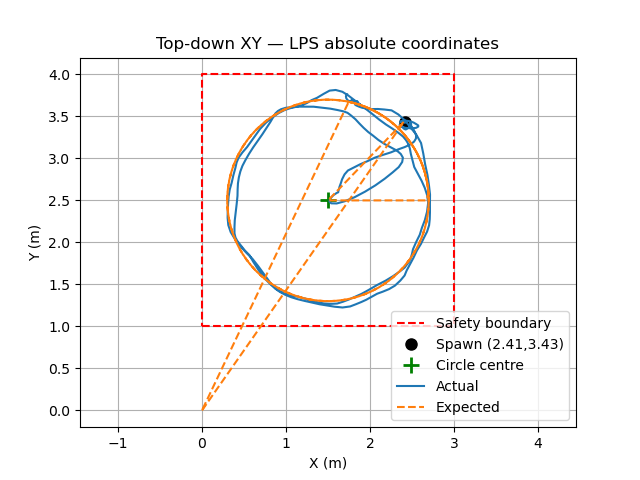

*circle_trajectory_xy_topdown.png — actual vs. expected path, top-down.*

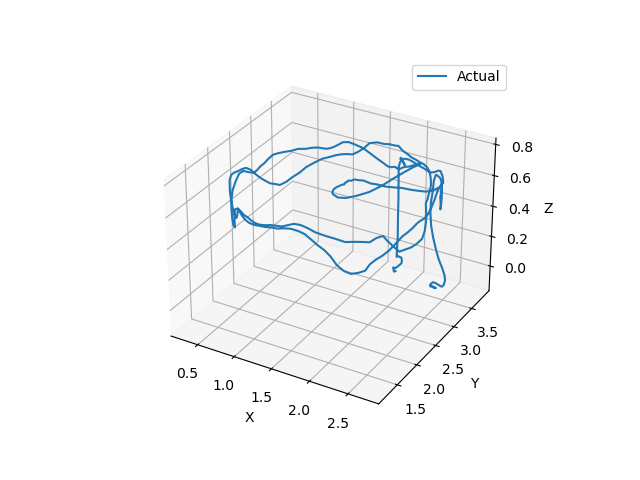

*circle_trajectory_3d.png — 3D trajectory.*

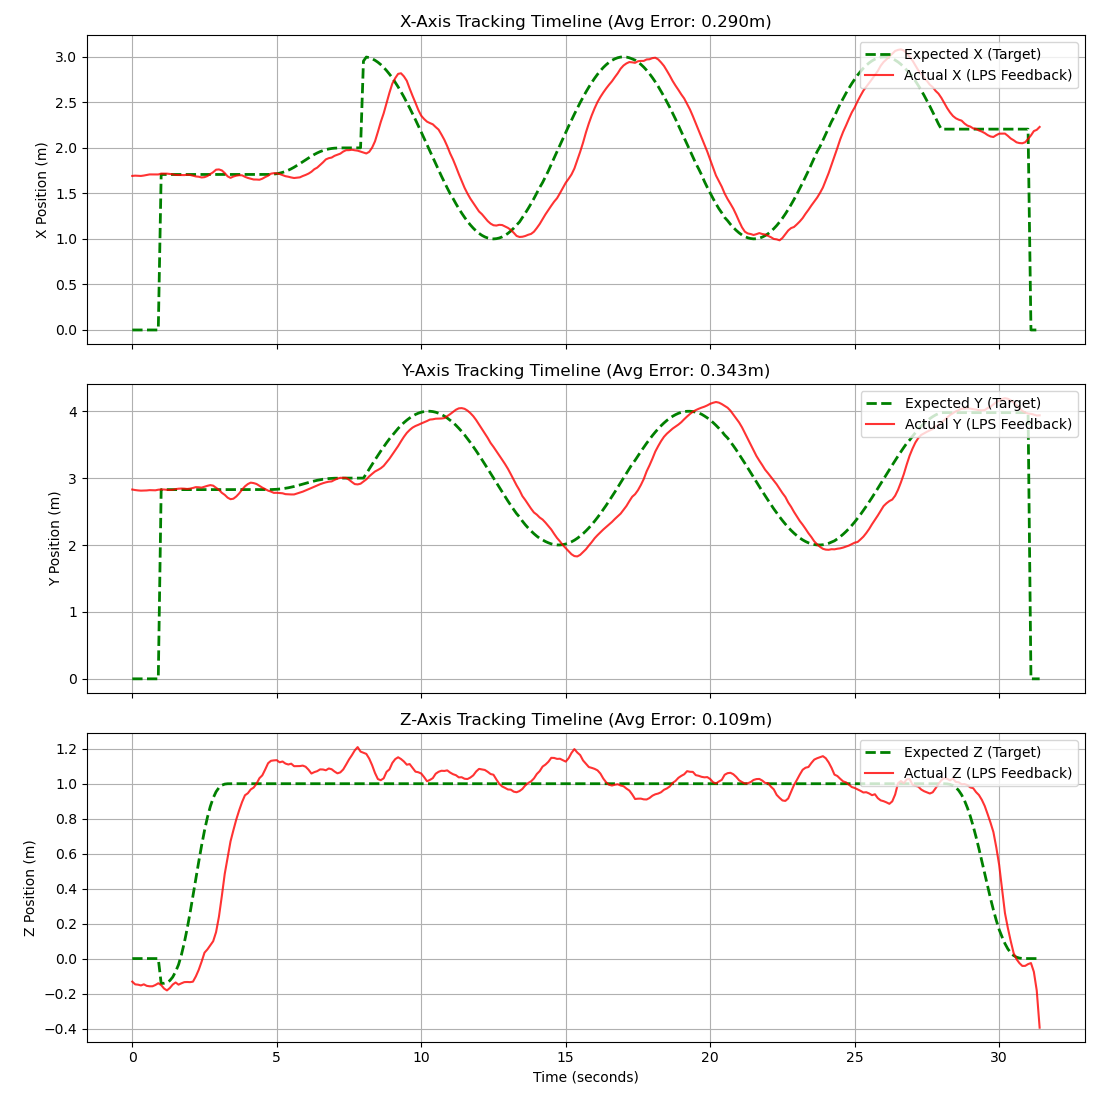

*trajectory_axis_wise(1).png — per-axis (X/Y/Z) tracking timeline.*

In [ ]:
import pandas as pd
log = pd.read_csv('../repo/single drone/circle trajectory/circle_trajectory_log.csv') \
    if os.path.exists('../repo/single drone/circle trajectory/circle_trajectory_log.csv') \
    else None
# If the CSV isn't alongside this notebook, point this at your own copy of
# `circle_trajectory_log.csv` from the repo.
log.head() if log is not None else print("circle_trajectory_log.csv not found next to notebook — update the path above.")


### 2.2 Figure-8 Trajectory — README (repo)

# Single Drone Figure-8 Trajectory

## Overview

This module implements autonomous figure-8 trajectory tracking using the Crazyflie 2.x platform. The experiment extends basic circular motion by introducing continuous changes in curvature, making it a more challenging trajectory for the onboard controller.

---

## Objectives

* Generate a smooth figure-8 trajectory.
* Evaluate controller performance under continuously changing turning directions.
* Analyze tracking accuracy and stability.
* Compare performance against circular trajectory tracking.

---

## Repository Contents

```text
figure8_trajectory/
├── figure-8.py
├── figure-8_trajectory_xy_topdown.png
└── README.md
```

---

## Working Principle

The trajectory is generated by continuously computing position waypoints representing a figure-8 path. These waypoints are transmitted through the Position High-Level Commander while the Crazyflie firmware performs the low-level control.

The changing curvature of the trajectory provides a useful benchmark for evaluating localization quality and PID tuning.

---

## Results

The Crazyflie successfully completed repeated figure-8 trajectories with smooth transitions between loops. Performance improvements were achieved after tuning the controller gains and optimizing localization.

The generated trajectory plots are included for analysis.

---

## Future Improvements

* 3D figure-8 trajectories
* Velocity optimization
* Dynamic waypoint generation
* Real-time trajectory replanning


In [ ]:
%%writefile figure-8.py
import sys
import time
import csv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import cflib.crtp
from cflib.crazyflie import Crazyflie
from cflib.crazyflie.high_level_commander import HighLevelCommander
from cflib.crazyflie.log import LogConfig
from cflib.crazyflie.mem import CompressedSegment, CompressedStart, MemoryElement
from cflib.crazyflie.syncCrazyflie import SyncCrazyflie
from cflib.utils import uri_helper
from cflib.utils.reset_estimator import reset_estimator

# URI to the Crazyflie
uri = uri_helper.uri_from_env(default='radio://0/80/2M/E7E7E7E7E2')

# Trajectory (figure 8)
a = 0.9
b = 0.5
c = 0.5
trajectory = [
    CompressedStart(0.0, 0.0, 0.0, 0.0),
    CompressedSegment(2.0, [0.0, 1.0, 1.0], [0.0, a, 0.0], [], []),
    CompressedSegment(2.0, [1.0, b, 0.0], [-a, -c, 0.0], [], []),
    CompressedSegment(2.0, [-b, -1.0, -1.0], [c, a, 0.0], [], []),
    CompressedSegment(2.0, [-1.0, 0.0, 0.0], [-a, 0.0, 0.0], [], []),
]

# Global variable for logs
log_data_list = []
log_conf = None


def upload_trajectory(cf, trajectory_id, trajectory):
    trajectory_mem = cf.mem.get_mems(MemoryElement.TYPE_TRAJ)[0]
    trajectory_mem.trajectory = trajectory

    if not trajectory_mem.write_data_sync():
        print('Upload failed!')
        sys.exit(1)

    cf.high_level_commander.define_trajectory(
        trajectory_id, 0, len(trajectory),
        type=HighLevelCommander.TRAJECTORY_TYPE_POLY4D_COMPRESSED
    )

    total_duration = 0
    for seg in trajectory[1:]:
        total_duration += seg.duration
    return total_duration


# -------- LOG CALLBACK ----------

def log_callback(timestamp, data, logconf):
    log_data_list.append({
        'time': timestamp,
        'actual_x': data.get('kalman.stateX', 0),
        'actual_y': data.get('kalman.stateY', 0),
        'actual_z': data.get('kalman.stateZ', 0),
        'expected_x': data.get('ctrltarget.x', 0),
        'expected_y': data.get('ctrltarget.y', 0),
        'expected_z': data.get('ctrltarget.z', 0)
    })


# -------- LOG SETUP ----------

def setup_logging(cf):
    global log_conf

    log_conf = LogConfig(name='TrajectoryLog', period_in_ms=100)
    log_conf.add_variable('kalman.stateX', 'float')
    log_conf.add_variable('kalman.stateY', 'float')
    log_conf.add_variable('kalman.stateZ', 'float')
    log_conf.add_variable('ctrltarget.x', 'float')
    log_conf.add_variable('ctrltarget.y', 'float')
    log_conf.add_variable('ctrltarget.z', 'float')

    cf.log.add_config(log_conf)
    log_conf.data_received_cb.add_callback(log_callback)


# -------- SAVE CSV ----------

def save_log_to_csv(log_data, filename='trajectory_log.csv'):
    if not log_data:
        print("No logs to save!")
        return

    keys = ['time', 'actual_x', 'actual_y', 'actual_z',
            'expected_x', 'expected_y', 'expected_z']

    with open(filename, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        for row in log_data:
            writer.writerow(row)

    print(f"Saved CSV: {filename}")


# -------- PLOTTING ----------

def plot_and_save_data(log_data):
    if not log_data:
        print('No data to plot.')
        return

    t = np.array([d['time'] for d in log_data]) / 1000.0
    t -= t[0]

    ax = np.array([d['actual_x'] for d in log_data])
    ay = np.array([d['actual_y'] for d in log_data])
    az = np.array([d['actual_z'] for d in log_data])

    ex = np.array([d['expected_x'] for d in log_data])
    ey = np.array([d['expected_y'] for d in log_data])
    ez = np.array([d['expected_z'] for d in log_data])

    # XY
    plt.figure()
    plt.plot(ax, ay, label='Actual')
    plt.plot(ex, ey, '--', label='Expected')
    plt.title("Top-down XY")
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.savefig("trajectory_xy_topdown.png")
    print("Saved trajectory_xy_topdown.png")

    # X(t)
    plt.figure()
    plt.plot(t, ax)
    plt.plot(t, ex, '--')
    plt.title("X over time")
    plt.grid(True)
    plt.savefig("trajectory_x.png")
    print("Saved trajectory_x.png")

    # Y(t)
    plt.figure()
    plt.plot(t, ay)
    plt.plot(t, ey, '--')
    plt.title("Y over time")
    plt.grid(True)
    plt.savefig("trajectory_y.png")
    print("Saved trajectory_y.png")

    # Z(t)
    plt.figure()
    plt.plot(t, az)
    plt.plot(t, ez, '--')
    plt.title("Z over time")
    plt.grid(True)
    plt.savefig("trajectory_z.png")
    print("Saved trajectory_z.png")

    # 3D
    fig = plt.figure()
    ax3 = fig.add_subplot(111, projection='3d')
    ax3.plot(ax, ay, az)
    ax3.plot(ex, ey, ez, '--')
    ax3.set_title("3D Trajectory")
    plt.show()


# -------- RUN SEQUENCE ----------

def run_sequence(cf, trajectory_id, duration):
    commander = cf.high_level_commander

    log_conf.start()

    cf.platform.send_arming_request(True)
    time.sleep(1.0)

    commander.takeoff(1.0, 2.0)
    time.sleep(3)

    commander.start_trajectory(trajectory_id, 1.0, True)
    time.sleep(duration)

    LAND_X = 2.50
    LAND_Y = 3.36
    SAFE_Z = 0.5

    commander.go_to(LAND_X, LAND_Y, SAFE_Z, 0, 3, relative=False)
    time.sleep(3.2)

    commander.land(0.0, 3.0)
    time.sleep(3.2)

    commander.stop()
    log_conf.stop()


# -------- MAIN ----------

if __name__ == '__main__':
    cflib.crtp.init_drivers()

    with SyncCrazyflie(uri, cf=Crazyflie(rw_cache='./cache')) as scf:
        cf = scf.cf

        setup_logging(cf)
        traj_id = 1

        duration = upload_trajectory(cf, traj_id, trajectory)
        print(f"Trajectory duration: {duration:.1f}s")

        reset_estimator(cf)
        run_sequence(cf, traj_id, duration)

    # ---- SAVE CSV ----
    save_log_to_csv(log_data_list)

    # ---- PLOT ----
    plot_and_save_data(log_data_list)

**Actual output plot (from the repo):**

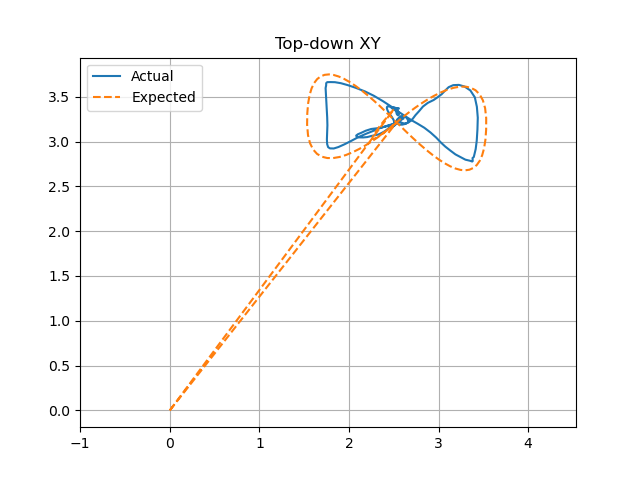

*figure-8_trajectory_xy_topdown.png — actual vs. expected figure-8 path.*

## 3. Multi-Drone Circle — π Phase Separation

Source: `multi-drone/two_drone_circle/` in the repo. Two Crazyflies fly the same circle 180° apart, each on its own communication thread.


# Multi-Drone Circular Trajectory

## Overview

This module demonstrates synchronized circular trajectory tracking using two Crazyflie drones. Each drone is controlled independently through separate communication links while maintaining coordinated flight using Python multithreading.

The experiment serves as a foundation for cooperative multi-robot control and swarm applications.

---

## Objectives

* Simultaneously control two Crazyflies.
* Execute synchronized circular trajectories.
* Develop multithreaded drone control using cflib.
* Validate communication reliability and synchronization.

---

## Repository Contents

```text
two_drone_circle/
├── two_cf_circle_path.py
├── trajectory_plots/
├── logs/
└── README.md
```

---

## Working Principle

Each Crazyflie is assigned an independent communication thread responsible for transmitting position commands.

The program performs:

* Connection establishment
* Synchronized takeoff
* Parallel trajectory execution
* Coordinated landing

The onboard position controllers execute the received position commands independently.

---
## Demonstration

A demonstration of the autonomous dual-drone circular trajectory execution can be viewed below.

**[Watch the Demo Video](https://drive.google.com/file/d/15mfLE9bK-xCZH9vjKYqjsXOArD6pt6ze/view?usp=sharing)**
## Challenges

During development, several issues were encountered:

* TWR localization conflicts
* Communication synchronization
* Position estimation errors
* Anchor placement optimization

These issues were addressed by improving anchor placement, updating localization parameters, and refining the multithreaded implementation.

---

## Results

Both drones successfully completed synchronized circular trajectories while maintaining safe separation and stable localization.

This implementation forms the basis for more advanced swarm behaviours.


In [ ]:
%%writefile two_cf_circle_path.py
#!/usr/bin/env python3
import csv
import math
import time
import threading
import argparse
import os

import numpy as np
import matplotlib
matplotlib.use('Agg')   # headless-safe; pass --show for interactive windows
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

try:
    import cflib.crtp
    from cflib.crazyflie import Crazyflie
    from cflib.crazyflie.syncCrazyflie import SyncCrazyflie
    from cflib.crazyflie.log import LogConfig
    CF_AVAILABLE = True
except ImportError:
    CF_AVAILABLE = False

# =============================================================================
#  SECTION 1 — CONSTANTS
# =============================================================================

URI_7 = 'radio://0/80/2M/E7E7E7E701'
URI_2 = 'radio://0/80/2M/E7E7E7E702'

# Safe zone
SAFE_X_MIN, SAFE_X_MAX = 0.0, 3.0
SAFE_Y_MIN, SAFE_Y_MAX = 1.0, 4.0

# Flight — BOTH drones fly at the SAME altitude (no separation needed)
FLY_Z       = 1.0   # m  cruise altitude for both drones
TAKEOFF_DUR = 2.5    # s

# LPS
LPS_SETTLE  = 10.0    # s – wait for Kalman filter after connect

# Circle
CIRCLE_CX   = (SAFE_X_MIN + SAFE_X_MAX) / 2.0   # 1.5 m
CIRCLE_CY   = (SAFE_Y_MIN + SAFE_Y_MAX) / 2.0   # 2.5 m
CIRCLE_R    = 1.2    # m  (fits inside safe zone with ≥0.15 m wall clearance)
OMEGA       = 0.7    # rad/s  →  one full lap ≈ 8.98 s
CIRCLE_DT   = 0.1    # s per waypoint (10 Hz, matches reference script)
CIRCLE_LAPS = 3      # number of complete revolutions

CIRCLE_DURATION = CIRCLE_LAPS * (2 * math.pi / OMEGA)   # total circle time (s)

# Drone entry points (180° apart on the circle)
CIRCLE_START_7 = (CIRCLE_CX + CIRCLE_R, CIRCLE_CY)   # angle   0° → (2.7, 2.5)
CIRCLE_START_2 = (CIRCLE_CX - CIRCLE_R, CIRCLE_CY)   # angle 180° → (0.3, 2.5)

# Landing pads
LAND_7 = (2.2, 2.0)
LAND_2 = (2.0, 3.0)

# Radio stagger – offset Drone 2's go_to calls slightly so two packets
# never hit the shared 80/2M channel at exactly the same moment.
RADIO_STAGGER = 0.05   # s

# ── Mission timeline ─────────────────────────────────────────────────────────
T_TAKEOFF_END  = 3.5
T_ENTRY_END    = 8.0                               # fly to circle entry point
T_CIRCLE_END   = T_ENTRY_END + CIRCLE_DURATION     # ≈ 34.9 s  (3 laps)
T_LANDNAV_END  = T_CIRCLE_END + 4.5
T_TOTAL        = T_LANDNAV_END + 4.5               # ≈ 43.9 s

# Plot palette
C7  = '#3266ad'   # Drone 7 — blue
C2  = '#c94a2a'   # Drone 2 — coral
CG  = '#888780'   # neutral
CA  = '#3a8a5a'   # green
CB  = '#c4870a'   # amber

# =============================================================================
#  SECTION 2 — SHARED STATE & TELEMETRY
# =============================================================================

_state_lock = threading.Lock()
_drone_pos  = {
    URI_7: np.array([1.0, 2.0, 0.0]),
    URI_2: np.array([2.0, 3.0, 0.0]),
}

_telem_lock = threading.Lock()
_telem = {
    URI_7: {'t': [], 'ax': [], 'ay': [], 'az': [], 'ex': [], 'ey': [], 'ez': []},
    URI_2: {'t': [], 'ax': [], 'ay': [], 'az': [], 'ex': [], 'ey': [], 'ez': []},
}


def _log_telem(uri, t, actual, expected):
    with _telem_lock:
        d = _telem[uri]
        d['t'].append(float(t))
        d['ax'].append(float(actual[0]));   d['ay'].append(float(actual[1]));   d['az'].append(float(actual[2]))
        d['ex'].append(float(expected[0])); d['ey'].append(float(expected[1])); d['ez'].append(float(expected[2]))


def _telem_arrays(uri):
    with _telem_lock:
        return {k: np.array(v) for k, v in _telem[uri].items()}

# =============================================================================
#  SECTION 3 — LPS HELPERS
# =============================================================================

def _read_lps_position(cf) -> np.ndarray:
    """Wait for Kalman filter to settle, then read absolute LPS position."""
    print(f"  [LPS] Waiting {LPS_SETTLE} s for estimator to settle ...")
    time.sleep(LPS_SETTLE)
    pos = {}; done = [False]

    def _cb(ts, data, lc):
        if not done[0]:
            pos['x'] = data.get('kalman.stateX', 0.0)
            pos['y'] = data.get('kalman.stateY', 0.0)
            pos['z'] = data.get('kalman.stateZ', 0.0)
            done[0] = True

    lc = LogConfig(name='SpawnPos', period_in_ms=100)
    for v in ('kalman.stateX', 'kalman.stateY', 'kalman.stateZ'):
        lc.add_variable(v, 'float')
    cf.log.add_config(lc)
    lc.data_received_cb.add_callback(_cb)
    lc.start()

    t0 = time.time()
    while not done[0] and (time.time() - t0) < 6.0:
        time.sleep(0.05)
    lc.stop()

    if not done[0]:
        raise RuntimeError("LPS position read timed out. Check deck and anchors.")
    return np.array([pos['x'], pos['y'], pos['z']])


def _start_state_logging(cf, uri: str) -> 'LogConfig':
    """Continuously update _drone_pos[uri] from Kalman state."""
    def _cb(ts, data, lc):
        with _state_lock:
            _drone_pos[uri] = np.array([
                data.get('kalman.stateX', _drone_pos[uri][0]),
                data.get('kalman.stateY', _drone_pos[uri][1]),
                data.get('kalman.stateZ', _drone_pos[uri][2]),
            ])

    lc = LogConfig(name='StateLog', period_in_ms=100)
    for v in ('kalman.stateX', 'kalman.stateY', 'kalman.stateZ'):
        lc.add_variable(v, 'float')
    cf.log.add_config(lc)
    lc.data_received_cb.add_callback(_cb)
    lc.start()
    return lc


def _start_telem_logging(cf, uri: str) -> 'LogConfig':
    """
    Log kalman state + ctrltarget setpoint into _telem[uri].
    ctrltarget.x/y/z is the firmware's current position setpoint —
    the most accurate record of what the drone was told to do.
    """
    def _cb(ts, data, lc):
        with _state_lock:
            actual = _drone_pos[uri].copy()
        expected = [
            data.get('ctrltarget.x', actual[0]),
            data.get('ctrltarget.y', actual[1]),
            data.get('ctrltarget.z', actual[2]),
        ]
        _log_telem(uri, time.time(), actual, expected)

    lc = LogConfig(name='TelemLog', period_in_ms=100)
    for v in ('ctrltarget.x', 'ctrltarget.y', 'ctrltarget.z'):
        lc.add_variable(v, 'float')
    cf.log.add_config(lc)
    lc.data_received_cb.add_callback(_cb)
    return lc   # caller does lc.start()

# =============================================================================
#  SECTION 4 — CSV SAVE
# =============================================================================

def save_csv(uri, out_dir):
    d = _telem_arrays(uri)
    if len(d['t']) == 0:
        return
    # Normalise timestamps to seconds from mission start
    d['t'] = d['t'] - d['t'][0]
    label = uri[-1]
    path  = os.path.join(out_dir, f'drone_{label}_telem.csv')
    with open(path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['t','ax','ay','az','ex','ey','ez'])
        w.writeheader()
        for i in range(len(d['t'])):
            w.writerow({k: float(d[k][i]) for k in d})
    print(f"  [CSV] Saved {path}")

# =============================================================================
#  SECTION 5 — PER-DRONE FLIGHT THREAD
# =============================================================================

def _drone_thread(uri, other_uri, ready_evt, go_evt, stop_evt):
    label   = uri[-1]
    land_x, land_y = LAND_7 if uri == URI_7 else LAND_2

    # Phase offset: Drone 7 at 0°, Drone 2 at 180°
    start_angle = 0.0 if uri == URI_7 else math.pi
    start_x, start_y = CIRCLE_START_7 if uri == URI_7 else CIRCLE_START_2

    print(f"\n[Drone {label}] Connecting ...")
    try:
        with SyncCrazyflie(uri, cf=Crazyflie(rw_cache=f'./cache_{label}')) as scf:
            cf  = scf.cf
            hlc = cf.high_level_commander

            cf.param.set_value('commander.enHighLevel', '1')
            time.sleep(0.3)
            try:
                cf.supervisor.send_arming_request(True)
            except AttributeError:
                pass
            time.sleep(0.5)

            # Read absolute spawn position from LPS
            spawn = _read_lps_position(cf)
            with _state_lock:
                _drone_pos[uri] = spawn
            print(f"[Drone {label}] Spawn: ({spawn[0]:.2f}, {spawn[1]:.2f}, {spawn[2]:.2f})")

            # Safety check
            margin = 0.1
            if not (SAFE_X_MIN + margin <= spawn[0] <= SAFE_X_MAX - margin and
                    SAFE_Y_MIN + margin <= spawn[1] <= SAFE_Y_MAX - margin):
                raise RuntimeError(
                    f"Drone {label} spawn ({spawn[0]:.2f},{spawn[1]:.2f}) "
                    f"is outside the safe zone. Aborting.")

            state_log = _start_state_logging(cf, uri)
            telem_log = _start_telem_logging(cf, uri)

            print(f"[Drone {label}] Ready — waiting for partner ...")
            ready_evt.set()
            go_evt.wait()

            telem_log.start()   # start recording from takeoff

            # ── Step 1: Takeoff ──────────────────────────────────────────────
            print(f"[Drone {label}] TAKEOFF → z={FLY_Z} m")
            hlc.takeoff(FLY_Z, TAKEOFF_DUR)
            time.sleep(TAKEOFF_DUR + 1.0)

            # ── Step 2: Fly to circle entry point ───────────────────────────
            dist = math.sqrt((start_x - spawn[0])**2 + (start_y - spawn[1])**2)
            entry_dur = max(3.0, dist / 0.5)
            print(f"[Drone {label}] ENTRY → ({start_x:.2f},{start_y:.2f})  "
                  f"angle={math.degrees(start_angle):.0f}°  dur={entry_dur:.1f}s")
            hlc.go_to(start_x, start_y, FLY_Z, yaw=0.0,
                      duration_s=entry_dur, relative=False)
            time.sleep(entry_dur + 0.5)

            # ── Step 3: Dense CCW circle loop ────────────────────────────────
            # Drone 2 starts RADIO_STAGGER seconds after Drone 7 within each tick
            # so both radios never transmit at the exact same instant.
            if uri == URI_2:
                time.sleep(RADIO_STAGGER)

            steps = int(CIRCLE_DURATION / CIRCLE_DT)
            theta = start_angle

            print(f"[Drone {label}] CIRCLE  r={CIRCLE_R}m  ω={OMEGA}rad/s  "
                  f"laps={CIRCLE_LAPS}  steps={steps}")

            for step in range(steps):
                theta += OMEGA * CIRCLE_DT   # advance angle each tick

                wx = CIRCLE_CX + CIRCLE_R * math.cos(theta)
                wy = CIRCLE_CY + CIRCLE_R * math.sin(theta)

                # Hard clamp inside safe zone (safety net for edge cases)
                wx = max(SAFE_X_MIN + 0.05, min(SAFE_X_MAX - 0.05, wx))
                wy = max(SAFE_Y_MIN + 0.05, min(SAFE_Y_MAX - 0.05, wy))

                hlc.go_to(wx, wy, FLY_Z, yaw=0.0,
                          duration_s=CIRCLE_DT, relative=False)
                time.sleep(CIRCLE_DT)

                if step % 90 == 0:
                    deg = math.degrees(theta) % 360
                    print(f"[Drone {label}] CIRCLE step {step+1:4d}/{steps}  "
                          f"({wx:.2f},{wy:.2f})  {deg:.0f}°")

            # ── Step 4: Fly to landing pad ───────────────────────────────────
            print(f"[Drone {label}] LAND-NAV → ({land_x:.2f},{land_y:.2f})")
            hlc.go_to(land_x, land_y, FLY_Z, yaw=0.0,
                      duration_s=4.0, relative=False)
            time.sleep(4.5)

            # ── Step 5: Land ─────────────────────────────────────────────────
            print(f"[Drone {label}] LANDING ↓")
            hlc.land(0.0, duration_s=4.0)
            time.sleep(4.5)
            hlc.stop()

            telem_log.stop()
            state_log.stop()
            print(f"[Drone {label}] Landed safely.")

    except Exception as exc:
        print(f"[Drone {label}] ERROR: {exc}")
        stop_evt.set()
        ready_evt.set()
        raise

# =============================================================================
#  SECTION 6 — SYNTHETIC DATA GENERATOR  (--sim mode)
# =============================================================================

def _lcg(seed):
    s = int(seed) & 0xFFFFFFFF
    while True:
        s = (s * 1664525 + 1013904223) & 0xFFFFFFFF
        yield (s >> 1) / 0x7FFFFFFF - 1.0


def generate_synthetic_mission(seed7=42, seed2=77):
    """
    Simulate the full mission. Both drones at FLY_Z, 180° apart on the circle.
    Returns d7, d2 — dicts of numpy arrays (t, ax, ay, az, ex, ey, ez).
    """
    rng7 = _lcg(seed7)
    rng2 = _lcg(seed2)
    T    = np.arange(0, T_TOTAL + CIRCLE_DT, CIRCLE_DT)

    def clamp(v, lo, hi): return float(np.clip(v, lo, hi))

    def ease(f):
        f = clamp(f, 0, 1)
        return 2*f**2 if f < 0.5 else 1 - (-2*f + 2)**2 / 2

    def lerp(t, t0, t1, v0, v1):
        return v0 + (v1 - v0) * ease((t - t0) / max(t1 - t0, 1e-9))

    def circle_xy(t, start_ang):
        """Position on circle at time t, starting from start_ang, CCW."""
        frac  = clamp((t - T_ENTRY_END) / CIRCLE_DURATION, 0.0, 1.0)
        theta = start_ang + frac * CIRCLE_LAPS * 2 * math.pi
        return (CIRCLE_CX + CIRCLE_R * math.cos(theta),
                CIRCLE_CY + CIRCLE_R * math.sin(theta))

    def phase(t):
        if t <= T_TAKEOFF_END:  return 'takeoff'
        if t <= T_ENTRY_END:    return 'entry'
        if t <= T_CIRCLE_END:   return 'circle'
        if t <= T_LANDNAV_END:  return 'landnav'
        return 'land'

    out7 = {k: [] for k in ('t','ax','ay','az','ex','ey','ez')}
    out2 = {k: [] for k in ('t','ax','ay','az','ex','ey','ez')}
    last7 = list(CIRCLE_START_7)
    last2 = list(CIRCLE_START_2)

    for t in T:
        if t > T_TOTAL:
            break
        ph = phase(t)
        n7 = next(rng7)
        n2 = next(rng2)

        if ph == 'takeoff':
            ex7, ey7 = 1.0, 2.0
            ez7 = lerp(t, 0, T_TAKEOFF_END, 0.0, FLY_Z)
            ex2, ey2 = 2.0, 3.0
            ez2 = lerp(t, 0, T_TAKEOFF_END, 0.0, FLY_Z)

        elif ph == 'entry':
            ez7 = ez2 = FLY_Z
            ex7 = lerp(t, T_TAKEOFF_END, T_ENTRY_END, 1.0, CIRCLE_START_7[0])
            ey7 = lerp(t, T_TAKEOFF_END, T_ENTRY_END, 2.0, CIRCLE_START_7[1])
            ex2 = lerp(t, T_TAKEOFF_END, T_ENTRY_END, 2.0, CIRCLE_START_2[0])
            ey2 = lerp(t, T_TAKEOFF_END, T_ENTRY_END, 3.0, CIRCLE_START_2[1])

        elif ph == 'circle':
            ez7 = ez2 = FLY_Z
            ex7, ey7 = circle_xy(t, 0.0)         # Drone 7 at θ
            ex2, ey2 = circle_xy(t, math.pi)      # Drone 2 at θ + π
            last7 = [ex7, ey7]
            last2 = [ex2, ey2]

        elif ph == 'landnav':
            ez7 = ez2 = FLY_Z
            ex7 = lerp(t, T_CIRCLE_END, T_LANDNAV_END, last7[0], LAND_7[0])
            ey7 = lerp(t, T_CIRCLE_END, T_LANDNAV_END, last7[1], LAND_7[1])
            ex2 = lerp(t, T_CIRCLE_END, T_LANDNAV_END, last2[0], LAND_2[0])
            ey2 = lerp(t, T_CIRCLE_END, T_LANDNAV_END, last2[1], LAND_2[1])

        else:  # land
            ex7, ey7 = LAND_7
            ez7 = lerp(t, T_LANDNAV_END, T_TOTAL, FLY_Z, 0.0)
            ex2, ey2 = LAND_2
            ez2 = lerp(t, T_LANDNAV_END, T_TOTAL, FLY_Z, 0.0)

        noise = 0.8   # scale for LPS-like noise
        for d, ex, ey, ez, n in [(out7, ex7, ey7, ez7, n7),
                                  (out2, ex2, ey2, ez2, n2)]:
            d['t'].append(float(t))
            d['ex'].append(ex);  d['ey'].append(ey);  d['ez'].append(ez)
            d['ax'].append(ex + n * 0.035 * noise)
            d['ay'].append(ey + n * 0.028 * noise)
            d['az'].append(ez + n * 0.018)

    def to_np(d): return {k: np.array(v) for k, v in d.items()}
    return to_np(out7), to_np(out2)

# =============================================================================
#  SECTION 7 — METRICS
# =============================================================================

def _mae(actual, expected):
    return float(np.mean(np.abs(actual - expected)))

def _rms(actual, expected):
    return float(np.sqrt(np.mean((actual - expected) ** 2)))

def _rolling_rms_3d(d, win):
    err2 = (d['ax']-d['ex'])**2 + (d['ay']-d['ey'])**2 + (d['az']-d['ez'])**2
    return np.sqrt(np.convolve(err2, np.ones(win)/win, mode='same'))

def print_summary(d7, d2):
    print("\n" + "="*52)
    print("   AXIS-WISE TRACKING MAE SUMMARY")
    print("="*52)
    for lbl, d in [('Drone 7', d7), ('Drone 2', d2)]:
        mx = _mae(d['ax'], d['ex'])
        my = _mae(d['ay'], d['ey'])
        mz = _mae(d['az'], d['ez'])
        print(f"  {lbl}  X:{mx*100:.2f}cm  Y:{my*100:.2f}cm  Z:{mz*100:.2f}cm")
    print("="*52 + "\n")

# =============================================================================
#  SECTION 8 — PLOT HELPERS
# =============================================================================

matplotlib.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'grid.linestyle': '--',
    'figure.dpi': 120,
    'lines.linewidth': 1.5,
    'savefig.bbox': 'tight',
    'savefig.dpi': 140,
})


def _add_safezone(ax):
    ax.add_patch(mpatches.FancyBboxPatch(
        (SAFE_X_MIN, SAFE_Y_MIN),
        SAFE_X_MAX-SAFE_X_MIN, SAFE_Y_MAX-SAFE_Y_MIN,
        boxstyle='square,pad=0', linewidth=1.0,
        edgecolor='#444', facecolor='#eef3f8', zorder=0, alpha=0.4))
    bx = [SAFE_X_MIN, SAFE_X_MAX, SAFE_X_MAX, SAFE_X_MIN, SAFE_X_MIN]
    by = [SAFE_Y_MIN, SAFE_Y_MIN, SAFE_Y_MAX, SAFE_Y_MAX, SAFE_Y_MIN]
    ax.plot(bx, by, 'r--', lw=1.1, alpha=0.5, label='Safety boundary')


def _draw_circle_overlay(ax):
    theta = np.linspace(0, 2*math.pi, 360)
    ax.plot(CIRCLE_CX + CIRCLE_R*np.cos(theta),
            CIRCLE_CY + CIRCLE_R*np.sin(theta),
            ':', color=CG, lw=1.4, alpha=0.7, zorder=1,
            label=f'Planned circle  r={CIRCLE_R}m')
    # 16 evenly-spaced reference tick marks
    a16 = np.linspace(0, 2*math.pi, 17)[:-1]
    ax.scatter(CIRCLE_CX + CIRCLE_R*np.cos(a16),
               CIRCLE_CY + CIRCLE_R*np.sin(a16),
               s=18, color=CG, alpha=0.45, zorder=3)
    ax.scatter(CIRCLE_CX, CIRCLE_CY, marker='+', s=90,
               color=CG, linewidths=1.4, zorder=4)
    ax.annotate(f'Centre\n({CIRCLE_CX},{CIRCLE_CY})',
                (CIRCLE_CX, CIRCLE_CY),
                textcoords='offset points', xytext=(6, -16),
                fontsize=7.5, color=CG)


def _phase_vlines(ax, ymax):
    quarter = (2*math.pi / OMEGA) / 4
    marks = [
        (T_TAKEOFF_END,                 'Takeoff'),
        (T_ENTRY_END,                   'Circle start'),
        (T_ENTRY_END + quarter,         '90°'),
        (T_ENTRY_END + 2*quarter,       '180°'),
        (T_ENTRY_END + 3*quarter,       '270°'),
        (T_ENTRY_END + 4*quarter,       'Lap 1'),
        (T_ENTRY_END + 8*quarter,       'Lap 2'),
        (T_CIRCLE_END,                  'Land nav'),
    ]
    for tv, name in marks:
        if tv > T_TOTAL:
            continue
        ax.axvline(tv, color=CG, ls=':', lw=0.6, alpha=0.45)
        ax.text(tv + 0.3, ymax * 0.93, name, fontsize=6.5, color=CG)

# =============================================================================
#  SECTION 9 — PLOTS
# =============================================================================

def plot_xy(d7, d2, out_dir):
    """Figure 1: XY top-down — actual vs expected with circle overlay."""
    fig, ax = plt.subplots(figsize=(7, 7))
    fig.suptitle('Figure 1 — XY Top-Down: Actual vs Expected  (π phase separation)',
                 fontweight='bold')
    _add_safezone(ax)
    _draw_circle_overlay(ax)

    every = 3
    for d, color, label in [(d7, C7, 'Drone 7'), (d2, C2, 'Drone 2')]:
        ax.plot(d['ex'][::every], d['ey'][::every], '--', color=color, lw=0.9, alpha=0.5)
        ax.plot(d['ax'][::every], d['ay'][::every], '-',  color=color, lw=1.4,
                label=f'{label} actual')

    # Entry points (always diametrically opposite)
    ax.scatter(*CIRCLE_START_7, marker='>', s=100, color=C7, zorder=5)
    ax.scatter(*CIRCLE_START_2, marker='<', s=100, color=C2, zorder=5)
    ax.annotate(f'D7 entry\n(0°)', CIRCLE_START_7,
                textcoords='offset points', xytext=(6, 4), fontsize=8, color=C7)
    ax.annotate(f'D2 entry\n(180°)', CIRCLE_START_2,
                textcoords='offset points', xytext=(-58, 4), fontsize=8, color=C2)

    # Dashed diametrically-opposite line (to show 2R separation)
    ax.annotate('', xy=CIRCLE_START_7, xytext=CIRCLE_START_2,
                arrowprops=dict(arrowstyle='<->', color=CG, lw=0.9, alpha=0.5))
    ax.text(CIRCLE_CX, CIRCLE_CY + 0.12, f'2R = {2*CIRCLE_R}m',
            ha='center', fontsize=8, color=CG)

    # Landing pads
    ax.scatter(*LAND_7, marker='*', s=140, color=C7, zorder=5)
    ax.scatter(*LAND_2, marker='*', s=140, color=C2, zorder=5)
    ax.annotate('L7', LAND_7, textcoords='offset points', xytext=(5, 5), fontsize=8)
    ax.annotate('L2', LAND_2, textcoords='offset points', xytext=(5, 5), fontsize=8)

    handles = [
        Line2D([0],[0], color=C7, lw=1.4,  label='Drone 7 actual'),
        Line2D([0],[0], color=C7, lw=0.9, ls='--', alpha=0.6, label='Drone 7 expected'),
        Line2D([0],[0], color=C2, lw=1.4,  label='Drone 2 actual'),
        Line2D([0],[0], color=C2, lw=0.9, ls='--', alpha=0.6, label='Drone 2 expected'),
        Line2D([0],[0], color=CG, lw=1.4, ls=':', alpha=0.7, label=f'Planned circle r={CIRCLE_R}m'),
        Line2D([0],[0], color='r', lw=1.1, ls='--', alpha=0.5, label='Safety boundary'),
        Line2D([0],[0], marker='*', color=C7, lw=0, markersize=9, label='Land pad 7'),
        Line2D([0],[0], marker='*', color=C2, lw=0, markersize=9, label='Land pad 2'),
    ]
    ax.legend(handles=handles, fontsize=7.5, loc='upper left', framealpha=0.85)
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
    ax.set_xlim(-0.15, 3.15); ax.set_ylim(0.75, 4.25)
    ax.set_aspect('equal')
    ax.set_title(
        f'Both drones at z={FLY_Z}m  |  Phase Δ=π  |  '
        f'c=({CIRCLE_CX},{CIRCLE_CY})  r={CIRCLE_R}m  ω={OMEGA}rad/s  '
        f'laps={CIRCLE_LAPS}', fontsize=8.5)

    plt.tight_layout()
    path = os.path.join(out_dir, '01_xy_trajectory.png')
    fig.savefig(path); plt.close(fig)
    print(f"  Saved: {path}")
    return path


def plot_axes(d7, d2, out_dir):
    """Figure 2: Per-axis position timelines."""
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle('Figure 2 — Axis-wise Position Timeline: Actual vs Expected',
                 fontweight='bold')
    every = 2

    for d, color, label in [(d7, C7, 'Drone 7'), (d2, C2, 'Drone 2')]:
        T = d['t'][::every]
        for i, (ak, ek) in enumerate([('ax','ex'), ('ay','ey'), ('az','ez')]):
            mae = _mae(d[ak], d[ek])
            axes[i].plot(T, d[ek][::every], '--', color=color, lw=1.3, alpha=0.55)
            axes[i].plot(T, d[ak][::every], '-',  color=color, lw=1.2,
                         label=f'{label}  (MAE={mae*100:.2f}cm)')

    # Reference altitude line
    axes[2].axhline(FLY_Z, color=CG, ls=':', lw=1.0, alpha=0.7,
                    label=f'Cruise z={FLY_Z}m (both drones)')

    configs = [
        ('X position (m)', (SAFE_X_MIN-0.1, SAFE_X_MAX+0.1), 'X-Axis Tracking'),
        ('Y position (m)', (SAFE_Y_MIN-0.1, SAFE_Y_MAX+0.1), 'Y-Axis Tracking'),
        ('Altitude Z (m)', (-0.05, 1.0),                      'Z-Axis (both at same height)'),
    ]
    for ax, (ylabel, ylim, title) in zip(axes, configs):
        _phase_vlines(ax, ylim[1])
        ax.set_ylabel(ylabel); ax.set_ylim(*ylim)
        ax.set_title(title + '  (Dashed = expected / ctrltarget)', fontsize=9)
        ax.legend(fontsize=7.5, ncol=2, loc='upper right', framealpha=0.8)

    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    path = os.path.join(out_dir, '02_xyz_axes.png')
    fig.savefig(path); plt.close(fig)
    print(f"  Saved: {path}")
    return path


def plot_rms(d7, d2, out_dir):
    """Figure 3: Per-axis RMS bars + rolling 3-D RMS curve."""
    rms7 = {a: _rms(d7[f'a{a}'], d7[f'e{a}']) for a in ('x','y','z')}
    rms2 = {a: _rms(d2[f'a{a}'], d2[f'e{a}']) for a in ('x','y','z')}
    rms7['3D'] = math.sqrt(sum(rms7[a]**2 for a in ('x','y','z')))
    rms2['3D'] = math.sqrt(sum(rms2[a]**2 for a in ('x','y','z')))

    win   = 50   # 5 s rolling window at 0.1 s/sample
    roll7 = _rolling_rms_3d(d7, win)
    roll2 = _rolling_rms_3d(d2, win)

    fig = plt.figure(figsize=(12, 8))
    fig.suptitle('Figure 3 — RMS Tracking Error Analysis', fontweight='bold')
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.3)

    for idx, (lbl, rms_d, color) in enumerate([('7', rms7, C7), ('2', rms2, C2)]):
        ax = fig.add_subplot(gs[0, idx])
        keys = ['x','y','z','3D']
        vals = [rms_d[k] for k in keys]
        bars = ax.bar(['X','Y','Z','3D'], vals,
                      color=[color+'88']*3 + [color],
                      edgecolor=color, linewidth=0.8, width=0.5)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.0002,
                    f'{val*100:.2f}cm', ha='center', va='bottom', fontsize=8)
        ax.set_title(f'Per-Axis RMS — Drone {lbl}')
        ax.set_ylabel('RMS error (m)')
        ax.set_ylim(0, max(vals) * 1.4)

    ax_r = fig.add_subplot(gs[1, :])
    every = 3
    ax_r.plot(d7['t'][::every], roll7[::every], color=C7, lw=1.4,
              label='Drone 7  rolling 3D RMS')
    ax_r.plot(d2['t'][::every], roll2[::every], color=C2, lw=1.4,
              label='Drone 2  rolling 3D RMS')
    ax_r.fill_between(d7['t'][::every], roll7[::every], alpha=0.12, color=C7)
    ax_r.fill_between(d2['t'][::every], roll2[::every], alpha=0.12, color=C2)
    _phase_vlines(ax_r, max(roll7.max(), roll2.max()) * 1.1 or 0.1)
    ax_r.set_xlabel('Time (s)'); ax_r.set_ylabel('3D RMS error (m)')
    ax_r.set_title(
        f'Rolling 3D RMS (win={win*CIRCLE_DT:.0f}s) | '
        f'Drone7={rms7["3D"]*100:.2f}cm  Drone2={rms2["3D"]*100:.2f}cm')
    ax_r.legend(fontsize=9)

    path = os.path.join(out_dir, '03_rms_error.png')
    fig.savefig(path); plt.close(fig)
    print(f"  Saved: {path}")
    return path, rms7, rms2


def plot_separation(d7, d2, out_dir):
    """
    Figure 4: Inter-drone XY distance.
    During the circle phase this should stay very close to 2R = 2.4 m.
    """
    n = min(len(d7['t']), len(d2['t']))
    sep = np.sqrt((d7['ax'][:n]-d2['ax'][:n])**2 +
                  (d7['ay'][:n]-d2['ay'][:n])**2)
    T   = d7['t'][:n]

    fig, ax = plt.subplots(figsize=(12, 5))
    fig.suptitle('Figure 4 — Inter-Drone XY Separation  (target ≈ 2R = 2.4 m)',
                 fontweight='bold')

    every = 3
    ax.plot(T[::every], sep[::every], color=C7, lw=1.5, label='XY distance')
    ax.axhline(2*CIRCLE_R, color=CA,  ls='--', lw=1.2,
               label=f'Expected π-separation  2R={2*CIRCLE_R}m')
    ax.axhline(0.5,        color=C2,  ls='--', lw=1.0,
               label='Proximity alert (< 0.5m)')

    # Shade under the proximity threshold
    ax.fill_between(T[::every], 0, np.minimum(sep[::every], 0.5),
                    alpha=0.2, color=C2)

    # Shade the circle phase
    ax.axvspan(T_ENTRY_END, T_CIRCLE_END, alpha=0.06, color=CA,
               label='Circle phase')

    _phase_vlines(ax, sep.max() * 1.15)
    ax.set_xlabel('Time (s)'); ax.set_ylabel('XY distance (m)')
    ax.set_ylim(0, sep.max() * 1.20)
    ax.legend(fontsize=8.5, loc='upper right')
    ax.set_title(
        f'min={sep.min():.3f}m  avg={sep.mean():.3f}m  '
        f'(circle phase min should be ≈ {2*CIRCLE_R}m)', fontsize=9)

    plt.tight_layout()
    path = os.path.join(out_dir, '04_separation.png')
    fig.savefig(path); plt.close(fig)
    print(f"  Saved: {path}")
    return path


def plot_3d(d7, d2, out_dir):
    """Figure 5: 3-D trajectory — both drones at the same altitude."""
    fig = plt.figure(figsize=(10, 8))
    fig.suptitle('Figure 5 — 3-D Trajectory: Actual vs Expected', fontweight='bold')
    ax3 = fig.add_subplot(111, projection='3d')

    every = 3
    for d, color, label in [(d7, C7, 'Drone 7'), (d2, C2, 'Drone 2')]:
        ax3.plot(d['ax'][::every], d['ay'][::every], d['az'][::every],
                 color=color, lw=1.3, label=f'{label} actual')
        ax3.plot(d['ex'][::every], d['ey'][::every], d['ez'][::every],
                 '--', color=color, lw=0.8, alpha=0.5, label=f'{label} expected')

    # Draw circle projection at cruise altitude
    theta = np.linspace(0, 2*math.pi, 300)
    cx_pts = CIRCLE_CX + CIRCLE_R * np.cos(theta)
    cy_pts = CIRCLE_CY + CIRCLE_R * np.sin(theta)
    ax3.plot(cx_pts, cy_pts, np.full_like(cx_pts, FLY_Z),
             ':', color=CG, lw=1.0, alpha=0.5, label=f'Circle at z={FLY_Z}m')

    ax3.set_xlabel('X (m)'); ax3.set_ylabel('Y (m)'); ax3.set_zlabel('Z (m)')
    ax3.set_title(
        f'Both drones cruise at z={FLY_Z}m  |  Phase Δ=π  |  '
        f'Dotted circle at cruise altitude', fontsize=9)
    ax3.legend(fontsize=8, loc='upper left')

    plt.tight_layout()
    path = os.path.join(out_dir, '05_trajectory_3d.png')
    fig.savefig(path); plt.close(fig)
    print(f"  Saved: {path}")
    return path


def generate_all_plots(d7, d2, out_dir='.'):
    os.makedirs(out_dir, exist_ok=True)
    print('\n' + '='*55)
    print('  Post-Flight Analysis — Generating 5 Plots')
    print('='*55)
    print_summary(d7, d2)

    plot_xy(d7, d2, out_dir)
    plot_axes(d7, d2, out_dir)
    _, rms7, rms2 = plot_rms(d7, d2, out_dir)
    plot_separation(d7, d2, out_dir)
    plot_3d(d7, d2, out_dir)

    print()
    print('  ─── RMS Summary ─────────────────────────────────────────')
    for lbl, rd in [('Drone 7', rms7), ('Drone 2', rms2)]:
        print(f'  {lbl}  X:{rd["x"]*100:.2f}cm  Y:{rd["y"]*100:.2f}cm  '
              f'Z:{rd["z"]*100:.2f}cm  →  3D: {rd["3D"]*100:.2f}cm')
    print('  ─────────────────────────────────────────────────────────')
    print(f'\n  ✓ All plots saved to "{os.path.abspath(out_dir)}"')

# =============================================================================
#  SECTION 10 — REAL FLIGHT MAIN
# =============================================================================

def run_real_flight(out_dir):
    if not CF_AVAILABLE:
        raise RuntimeError(
            "cflib not found.  pip install cflib\n"
            "Or simulate:  python dual_drone_circle.py --sim")

    print('='*55)
    print('  Dual-Drone Circle  —  π phase separation')
    print('='*55)
    print(f'  Both drones at z = {FLY_Z} m  (same altitude, safe by π)')
    print(f'  Drone 7  start={CIRCLE_START_7}  land={LAND_7}')
    print(f'  Drone 2  start={CIRCLE_START_2}  land={LAND_2}')
    print(f'  Circle   c=({CIRCLE_CX},{CIRCLE_CY})  r={CIRCLE_R}m  '
          f'ω={OMEGA}rad/s  laps={CIRCLE_LAPS}  dt={CIRCLE_DT}s')
    print(f'  Safe zone  X[{SAFE_X_MIN},{SAFE_X_MAX}]  Y[{SAFE_Y_MIN},{SAFE_Y_MAX}]')
    print('='*55)
    input('\nPress ENTER to verify anchors and start: ')

    cflib.crtp.init_drivers()

    stop_evt = threading.Event()
    go_evt   = threading.Event()
    ready_7  = threading.Event()
    ready_2  = threading.Event()

    t7 = threading.Thread(
        target=_drone_thread,
        args=(URI_7, URI_2, ready_7, go_evt, stop_evt), daemon=True)
    t2 = threading.Thread(
        target=_drone_thread,
        args=(URI_2, URI_7, ready_2, go_evt, stop_evt), daemon=True)
    t7.start(); t2.start()

    ready_7.wait(timeout=90)
    ready_2.wait(timeout=90)

    if not ready_7.is_set() or not ready_2.is_set() or stop_evt.is_set():
        print('[Main] Pre-flight timeout or error. Aborting.')
        stop_evt.set()
        return

    print('[Main] Both drones ready — departing in 3 s ...')
    time.sleep(3.0)
    go_evt.set()

    try:
        t7.join(); t2.join()
    except KeyboardInterrupt:
        print('\n[Main] Abort ...')
        stop_evt.set()
        t7.join(timeout=5); t2.join(timeout=5)

    print('\n[Main] Mission complete.')
    os.makedirs(out_dir, exist_ok=True)
    save_csv(URI_7, out_dir)
    save_csv(URI_2, out_dir)
    d7 = _telem_arrays(URI_7)
    d2 = _telem_arrays(URI_2)
    generate_all_plots(d7, d2, out_dir)

# =============================================================================
#  SECTION 11 — ENTRY POINT
# =============================================================================

def main():
    parser = argparse.ArgumentParser(
        description='Two Crazyflies revolving on the same circle with π phase separation.',
        formatter_class=argparse.RawDescriptionHelpFormatter)
    parser.add_argument('--sim',   action='store_true', help='Simulate without hardware')
    parser.add_argument('--out',   metavar='DIR', default='./plots',
                        help='Output directory for PNGs and CSVs')
    parser.add_argument('--show',  action='store_true', help='Open interactive windows')
    parser.add_argument('--seed7', type=int, default=42)
    parser.add_argument('--seed2', type=int, default=77)
    args = parser.parse_args()

    if args.show:
        matplotlib.use('TkAgg')

    if args.sim:
        print('='*55)
        print('  Simulation mode')
        print(f'  Circle   c=({CIRCLE_CX},{CIRCLE_CY})  r={CIRCLE_R}m  '
              f'ω={OMEGA}rad/s  laps={CIRCLE_LAPS}')
        print(f'  Drone 7  angle=  0°  entry={CIRCLE_START_7}')
        print(f'  Drone 2  angle=180°  entry={CIRCLE_START_2}  (π offset)')
        print(f'  Both at z={FLY_Z}m  |  XY separation always = 2R = {2*CIRCLE_R}m')
        print(f'  Total mission: ~{T_TOTAL:.0f}s')
        print('='*55)
        d7, d2 = generate_synthetic_mission(seed7=args.seed7, seed2=args.seed2)
        print(f'  Generated {len(d7["t"])} samples  ({d7["t"][-1]:.1f}s)')
        generate_all_plots(d7, d2, args.out)
        if args.show:
            plt.show()
    else:
        run_real_flight(args.out)

if __name__ == '__main__':
    main()



Run the real script's own simulation mode to generate the plots and CSVs exactly as the repo does (no hardware required):

```bash
!python two_cf_circle_path.py --sim --out ./two_drone_circle_out
```

**Actual output plots already generated by this script on hardware (from the repo):**

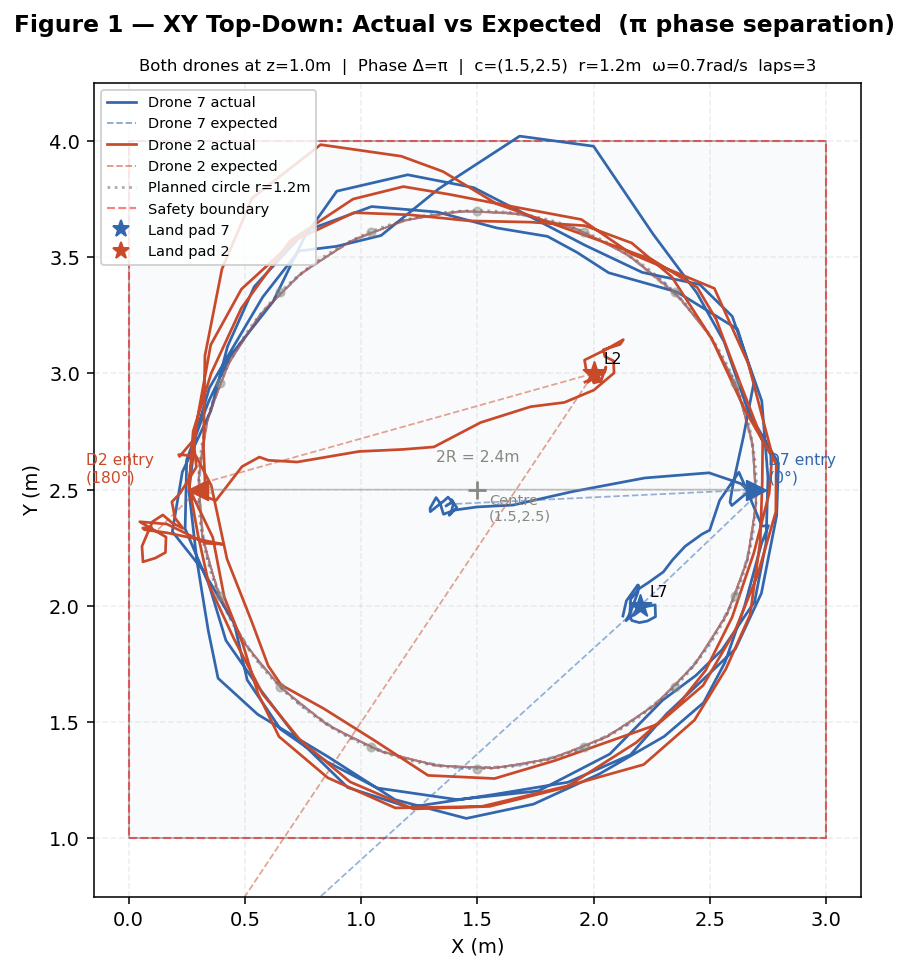

*01_xy_trajectory.png — XY top-down, both drones, π phase separation.*

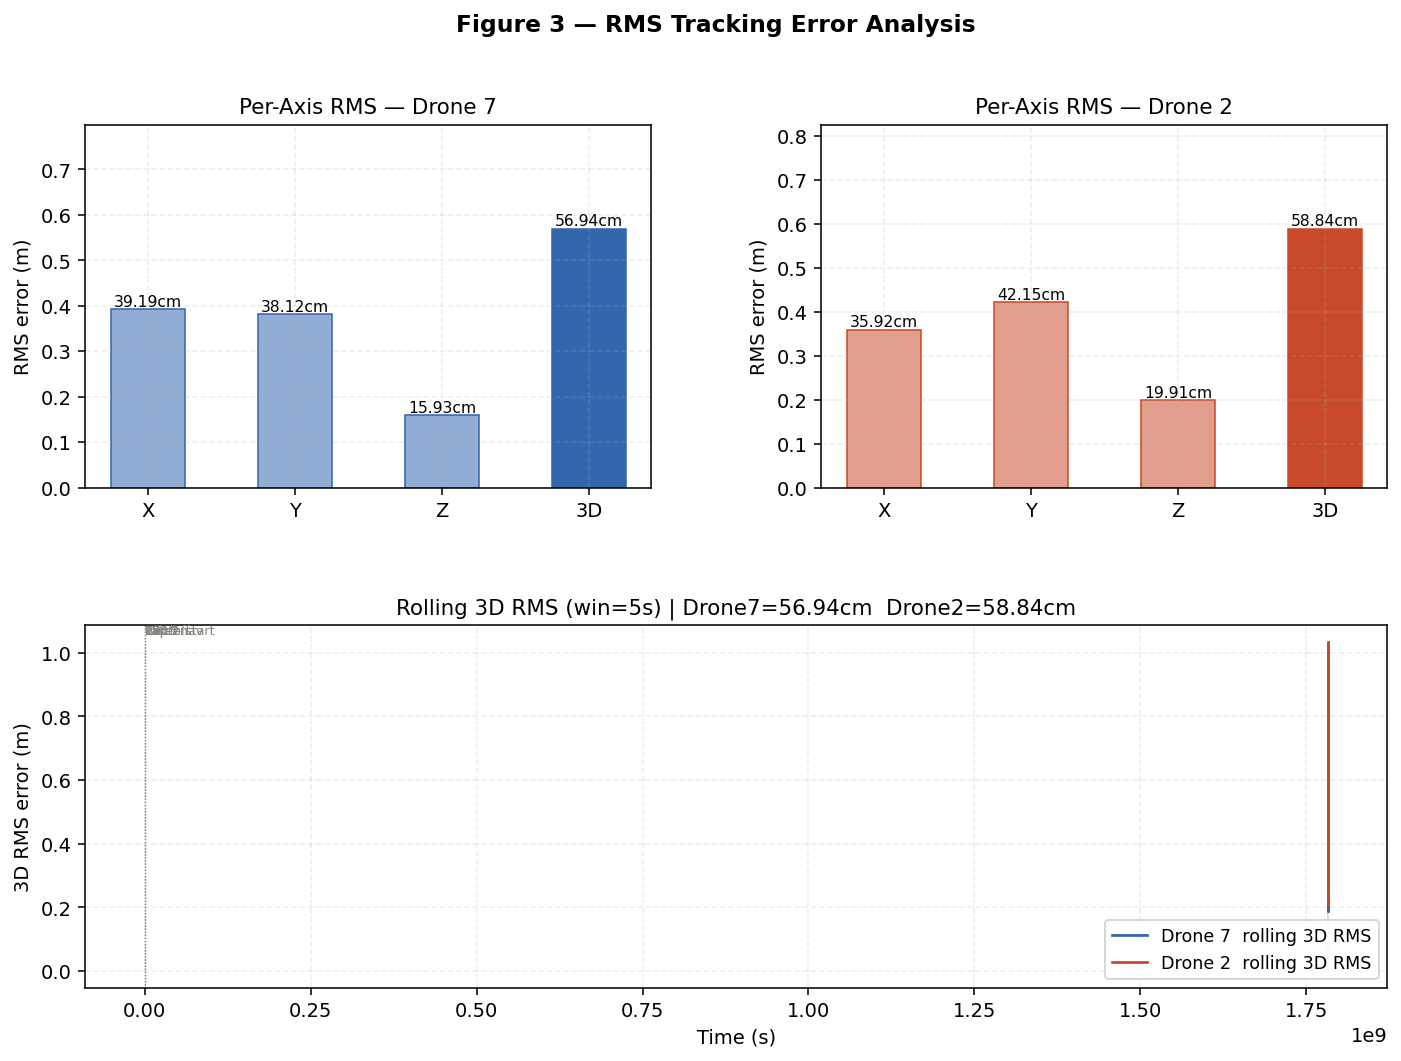

*03_rms_error.png — per-axis + rolling 3D RMS tracking error.*

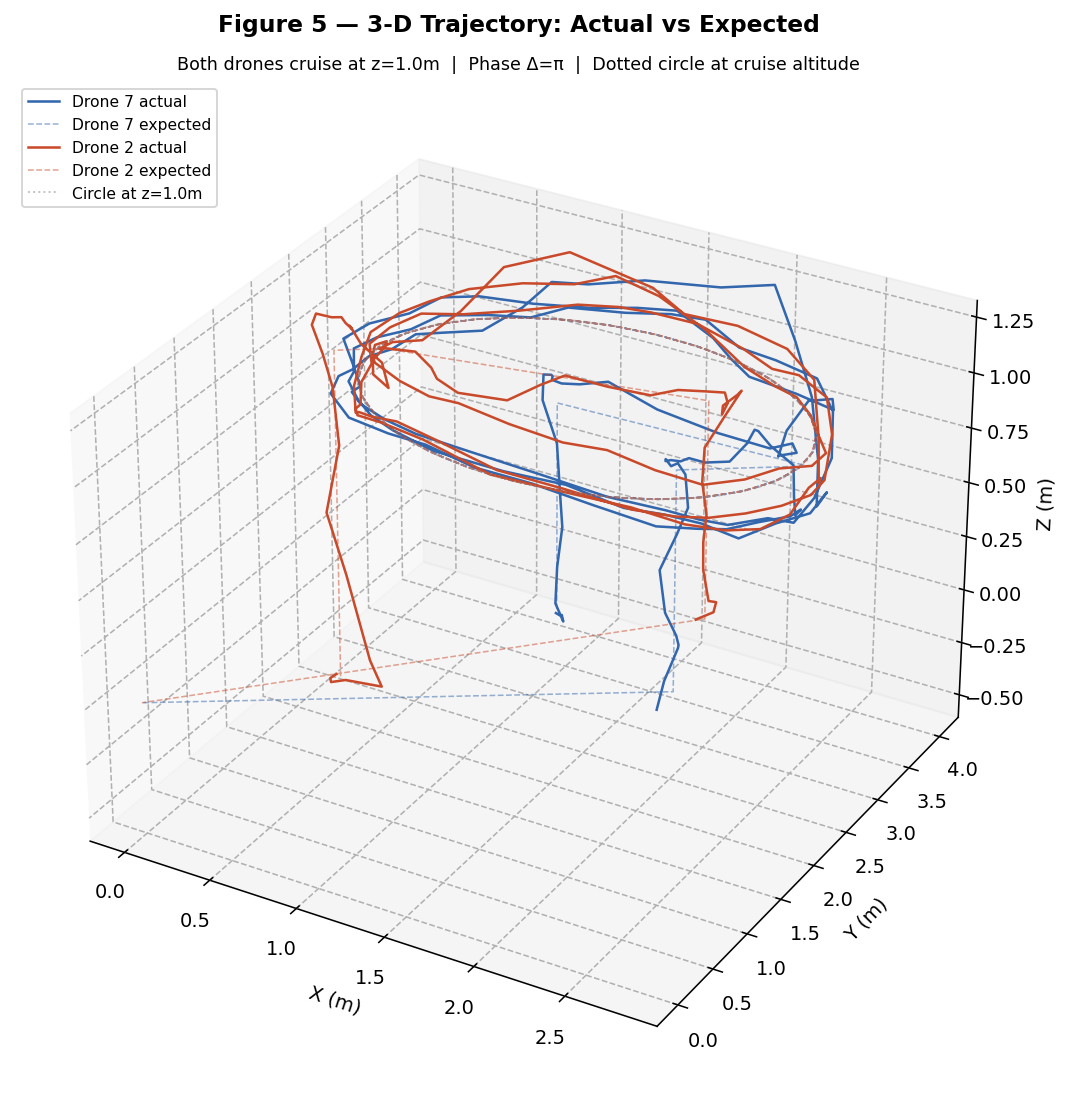

*05_trajectory_3d.png — 3D trajectory, both drones at cruise altitude.*

In [ ]:
# Uncomment to regenerate these plots yourself via the script's own --sim mode:
# !python two_cf_circle_path.py --sim --out ./two_drone_circle_out
# from IPython.display import Image, display
# display(Image('./two_drone_circle_out/01_xy_trajectory.png'))


## 4. Multi-Drone Tilted Ellipse

Source: `multi-drone/two_drone_tilted ellipse/` in the repo.


# Tilted Elliptical Trajectory

## Overview

This module demonstrates autonomous tilted elliptical trajectory tracking using a Crazyflie 2.x drone. The trajectory is generated by computing elliptical waypoints and rotating them by a specified angle before transmitting position setpoints through the Python cflib High-Level Commander.

This experiment extends basic trajectory generation by introducing geometric transformations, enabling more complex flight paths for autonomous navigation and trajectory planning.

---

## Objectives

* Generate a tilted elliptical flight trajectory.
* Implement waypoint generation using parametric ellipse equations.
* Apply rotational transformation to tilt the ellipse.
* Evaluate the drone's trajectory tracking accuracy and stability.

---

## Repository Contents

```text
tilted_ellipse/
├── tilted_ellipse.py
├── xy_topdown
├── 3d_trajectory
└── README.md
```

---

## Working Principle

The trajectory is generated using the parametric equation of an ellipse. Each waypoint is rotated by a predefined angle using a 2D rotation matrix before being sent as position commands to the Crazyflie.

The program performs:

* Connection establishment
* Autonomous takeoff
* Tilted elliptical trajectory execution
* Smooth landing

The onboard position controller continuously tracks the transmitted position setpoints throughout the flight.

---

## Demonstration

A demonstration of the autonomous tilted elliptical trajectory execution can be viewed below.

**[Watch the Demo Video](https://drive.google.com/file/d/1TcJyxby6fFiHaD0dReTwEvtiwoeNjhGc/view?usp=sharing)**

---

## Challenges

During development, several challenges were encountered:

* Maintaining smooth motion along the rotated trajectory
* Position estimation inaccuracies
* Localization drift during continuous motion
* Selecting an appropriate waypoint resolution for smooth tracking

These challenges were addressed by tuning the waypoint spacing, refining trajectory generation, and optimizing localization parameters.

---

## Results

The Crazyflie successfully completed the tilted elliptical trajectory while maintaining stable flight and accurately following the desired path.

This implementation demonstrates geometric trajectory generation and provides a foundation for more advanced autonomous flight patterns and motion planning.

In [ ]:
%%writefile tilted_ellipse.py
#!/usr/bin/env python3
import csv
import math
import time
import threading
import argparse
import os

import numpy as np
import matplotlib
matplotlib.use('Agg')   # headless-safe; pass --show for interactive windows
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

try:
    import cflib.crtp
    from cflib.crazyflie import Crazyflie
    from cflib.crazyflie.syncCrazyflie import SyncCrazyflie
    from cflib.crazyflie.log import LogConfig
    CF_AVAILABLE = True
except ImportError:
    CF_AVAILABLE = False

# =============================================================================
#  SECTION 1 — CONSTANTS
# =============================================================================

URI_7 = 'radio://0/80/2M/E7E7E7E701'
URI_2 = 'radio://0/80/2M/E7E7E7E702'

# Safe zone
SAFE_X_MIN, SAFE_X_MAX = 0.0, 3.0
SAFE_Y_MIN, SAFE_Y_MAX = 1.0, 4.0

# Flight — nominal cruise altitude (both drones oscillate around this)
FLY_Z       = 1.0   # m  reference/mean altitude
TAKEOFF_DUR = 2.5    # s

# LPS
LPS_SETTLE  = 10.0    # s – wait for Kalman filter after connect

# ── Tilted ellipse path ─────────────────────────────────────────────────────
# The XY footprint is an ellipse. Altitude is NOT constant anymore: it swings
# sinusoidally with the path angle theta, so the loop looks like a circular/
# elliptical hoop that's been tilted on an axis — high on one side, low on
# the opposite side. Because the two drones stay pi apart in theta, one is
# always near the high point while the other is near the low point.
CIRCLE_CX   = (SAFE_X_MIN + SAFE_X_MAX) / 2.0   # 1.5 m
CIRCLE_CY   = (SAFE_Y_MIN + SAFE_Y_MAX) / 2.0   # 2.5 m
ELLIPSE_A   = 1.2    # m  semi-axis along X (fits inside safe zone w/ margin)
ELLIPSE_B   = 0.9    # m  semi-axis along Y (fits inside safe zone w/ margin)
TILT_AMP    = 0.35   # m  altitude swing amplitude: z = FLY_Z ± TILT_AMP
TILT_PHASE  = 0.0    # rad  rotates *where* the high/low points sit on the loop
Z_MIN, Z_MAX = 0.35, 1.65   # hard altitude safety clamp (independent of FLY_Z)

OMEGA       = 0.7    # rad/s  →  one full lap ≈ 8.98 s
CIRCLE_DT   = 0.1    # s per waypoint (10 Hz, matches reference script)
CIRCLE_LAPS = 3      # number of complete revolutions

CIRCLE_DURATION = CIRCLE_LAPS * (2 * math.pi / OMEGA)   # total circle time (s)


def _ellipse_point(theta: float):
    """
    Position on the tilted ellipse at path angle theta.
    theta=0            -> +X side, HIGH point  (z = FLY_Z + TILT_AMP)
    theta=pi           -> -X side, LOW point   (z = FLY_Z - TILT_AMP)
    (exact high/low locations rotate with TILT_PHASE)
    """
    x = CIRCLE_CX + ELLIPSE_A * math.cos(theta)
    y = CIRCLE_CY + ELLIPSE_B * math.sin(theta)
    z = FLY_Z + TILT_AMP * math.cos(theta + TILT_PHASE)
    z = max(Z_MIN, min(Z_MAX, z))
    return x, y, z


# Drone entry points (180° apart on the ellipse)
CIRCLE_START_7 = _ellipse_point(0.0)         # angle   0°
CIRCLE_START_2 = _ellipse_point(math.pi)     # angle 180°

# Landing pads
LAND_7 = (2.2, 2.0)
LAND_2 = (2.0, 3.0)

# Radio stagger – offset Drone 2's go_to calls slightly so two packets
# never hit the shared 80/2M channel at exactly the same moment.
RADIO_STAGGER = 0.05   # s

# ── Mission timeline ─────────────────────────────────────────────────────────
T_TAKEOFF_END  = 3.5
T_ENTRY_END    = 8.0                               # fly to ellipse entry point
T_CIRCLE_END   = T_ENTRY_END + CIRCLE_DURATION     # ≈ 34.9 s  (3 laps)
T_LANDNAV_END  = T_CIRCLE_END + 4.5
T_TOTAL        = T_LANDNAV_END + 4.5               # ≈ 43.9 s

# Plot palette
C7  = '#3266ad'   # Drone 7 — blue
C2  = '#c94a2a'   # Drone 2 — coral
CG  = '#888780'   # neutral
CA  = '#3a8a5a'   # green
CB  = '#c4870a'   # amber

# =============================================================================
#  SECTION 2 — SHARED STATE & TELEMETRY
# =============================================================================

_state_lock = threading.Lock()
_drone_pos  = {
    URI_7: np.array([1.0, 2.0, 0.0]),
    URI_2: np.array([2.0, 3.0, 0.0]),
}

_telem_lock = threading.Lock()
_telem = {
    URI_7: {'t': [], 'ax': [], 'ay': [], 'az': [], 'ex': [], 'ey': [], 'ez': []},
    URI_2: {'t': [], 'ax': [], 'ay': [], 'az': [], 'ex': [], 'ey': [], 'ez': []},
}


def _log_telem(uri, t, actual, expected):
    with _telem_lock:
        d = _telem[uri]
        d['t'].append(float(t))
        d['ax'].append(float(actual[0]));   d['ay'].append(float(actual[1]));   d['az'].append(float(actual[2]))
        d['ex'].append(float(expected[0])); d['ey'].append(float(expected[1])); d['ez'].append(float(expected[2]))


def _telem_arrays(uri):
    with _telem_lock:
        return {k: np.array(v) for k, v in _telem[uri].items()}

# =============================================================================
#  SECTION 3 — LPS HELPERS
# =============================================================================

def _read_lps_position(cf) -> np.ndarray:
    """Wait for Kalman filter to settle, then read absolute LPS position."""
    print(f"  [LPS] Waiting {LPS_SETTLE} s for estimator to settle ...")
    time.sleep(LPS_SETTLE)
    pos = {}; done = [False]

    def _cb(ts, data, lc):
        if not done[0]:
            pos['x'] = data.get('kalman.stateX', 0.0)
            pos['y'] = data.get('kalman.stateY', 0.0)
            pos['z'] = data.get('kalman.stateZ', 0.0)
            done[0] = True

    lc = LogConfig(name='SpawnPos', period_in_ms=100)
    for v in ('kalman.stateX', 'kalman.stateY', 'kalman.stateZ'):
        lc.add_variable(v, 'float')
    cf.log.add_config(lc)
    lc.data_received_cb.add_callback(_cb)
    lc.start()

    t0 = time.time()
    while not done[0] and (time.time() - t0) < 6.0:
        time.sleep(0.05)
    lc.stop()

    if not done[0]:
        raise RuntimeError("LPS position read timed out. Check deck and anchors.")
    return np.array([pos['x'], pos['y'], pos['z']])


def _start_state_logging(cf, uri: str) -> 'LogConfig':
    """Continuously update _drone_pos[uri] from Kalman state."""
    def _cb(ts, data, lc):
        with _state_lock:
            _drone_pos[uri] = np.array([
                data.get('kalman.stateX', _drone_pos[uri][0]),
                data.get('kalman.stateY', _drone_pos[uri][1]),
                data.get('kalman.stateZ', _drone_pos[uri][2]),
            ])

    lc = LogConfig(name='StateLog', period_in_ms=100)
    for v in ('kalman.stateX', 'kalman.stateY', 'kalman.stateZ'):
        lc.add_variable(v, 'float')
    cf.log.add_config(lc)
    lc.data_received_cb.add_callback(_cb)
    lc.start()
    return lc


def _start_telem_logging(cf, uri: str) -> 'LogConfig':
    """
    Log kalman state + ctrltarget setpoint into _telem[uri].
    ctrltarget.x/y/z is the firmware's current position setpoint —
    the most accurate record of what the drone was told to do.
    """
    def _cb(ts, data, lc):
        with _state_lock:
            actual = _drone_pos[uri].copy()
        expected = [
            data.get('ctrltarget.x', actual[0]),
            data.get('ctrltarget.y', actual[1]),
            data.get('ctrltarget.z', actual[2]),
        ]
        _log_telem(uri, time.time(), actual, expected)

    lc = LogConfig(name='TelemLog', period_in_ms=100)
    for v in ('ctrltarget.x', 'ctrltarget.y', 'ctrltarget.z'):
        lc.add_variable(v, 'float')
    cf.log.add_config(lc)
    lc.data_received_cb.add_callback(_cb)
    return lc   # caller does lc.start()

# =============================================================================
#  SECTION 4 — CSV SAVE
# =============================================================================

def save_csv(uri, out_dir):
    d = _telem_arrays(uri)
    if len(d['t']) == 0:
        return
    # Normalise timestamps to seconds from mission start
    d['t'] = d['t'] - d['t'][0]
    label = uri[-1]
    path  = os.path.join(out_dir, f'drone_{label}_telem.csv')
    with open(path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['t','ax','ay','az','ex','ey','ez'])
        w.writeheader()
        for i in range(len(d['t'])):
            w.writerow({k: float(d[k][i]) for k in d})
    print(f"  [CSV] Saved {path}")

# =============================================================================
#  SECTION 5 — PER-DRONE FLIGHT THREAD
# =============================================================================

def _drone_thread(uri, other_uri, ready_evt, go_evt, stop_evt):
    label   = uri[-1]
    land_x, land_y = LAND_7 if uri == URI_7 else LAND_2

    # Phase offset: Drone 7 at 0°, Drone 2 at 180°
    start_angle = 0.0 if uri == URI_7 else math.pi
    start_x, start_y, start_z = CIRCLE_START_7 if uri == URI_7 else CIRCLE_START_2

    print(f"\n[Drone {label}] Connecting ...")
    try:
        with SyncCrazyflie(uri, cf=Crazyflie(rw_cache=f'./cache_{label}')) as scf:
            cf  = scf.cf
            hlc = cf.high_level_commander

            cf.param.set_value('commander.enHighLevel', '1')
            time.sleep(0.3)
            try:
                cf.supervisor.send_arming_request(True)
            except AttributeError:
                pass
            time.sleep(0.5)

            # Read absolute spawn position from LPS
            spawn = _read_lps_position(cf)
            with _state_lock:
                _drone_pos[uri] = spawn
            print(f"[Drone {label}] Spawn: ({spawn[0]:.2f}, {spawn[1]:.2f}, {spawn[2]:.2f})")

            # Safety check
            margin = 0.1
            if not (SAFE_X_MIN + margin <= spawn[0] <= SAFE_X_MAX - margin and
                    SAFE_Y_MIN + margin <= spawn[1] <= SAFE_Y_MAX - margin):
                raise RuntimeError(
                    f"Drone {label} spawn ({spawn[0]:.2f},{spawn[1]:.2f}) "
                    f"is outside the safe zone. Aborting.")

            state_log = _start_state_logging(cf, uri)
            telem_log = _start_telem_logging(cf, uri)

            print(f"[Drone {label}] Ready — waiting for partner ...")
            ready_evt.set()
            go_evt.wait()

            telem_log.start()   # start recording from takeoff

            # ── Step 1: Takeoff ──────────────────────────────────────────────
            print(f"[Drone {label}] TAKEOFF → z={FLY_Z} m")
            hlc.takeoff(FLY_Z, TAKEOFF_DUR)
            time.sleep(TAKEOFF_DUR + 1.0)

            # ── Step 2: Fly to ellipse entry point (at its tilted height) ────
            dist = math.sqrt((start_x - spawn[0])**2 + (start_y - spawn[1])**2)
            entry_dur = max(3.0, dist / 0.5)
            print(f"[Drone {label}] ENTRY → ({start_x:.2f},{start_y:.2f},{start_z:.2f})  "
                  f"angle={math.degrees(start_angle):.0f}°  dur={entry_dur:.1f}s")
            hlc.go_to(start_x, start_y, start_z, yaw=0.0,
                      duration_s=entry_dur, relative=False)
            time.sleep(entry_dur + 0.5)

            # ── Step 3: Dense CCW tilted-ellipse loop ────────────────────────
            # Drone 2 starts RADIO_STAGGER seconds after Drone 7 within each tick
            # so both radios never transmit at the exact same instant.
            if uri == URI_2:
                time.sleep(RADIO_STAGGER)

            steps = int(CIRCLE_DURATION / CIRCLE_DT)
            theta = start_angle

            print(f"[Drone {label}] ELLIPSE  a={ELLIPSE_A}m b={ELLIPSE_B}m  "
                  f"tilt=±{TILT_AMP}m  ω={OMEGA}rad/s  laps={CIRCLE_LAPS}  steps={steps}")

            for step in range(steps):
                theta += OMEGA * CIRCLE_DT   # advance angle each tick

                wx, wy, wz = _ellipse_point(theta)

                # Hard clamp inside safe zone / altitude (safety net for edge cases)
                wx = max(SAFE_X_MIN + 0.05, min(SAFE_X_MAX - 0.05, wx))
                wy = max(SAFE_Y_MIN + 0.05, min(SAFE_Y_MAX - 0.05, wy))
                wz = max(Z_MIN, min(Z_MAX, wz))

                hlc.go_to(wx, wy, wz, yaw=0.0,
                          duration_s=CIRCLE_DT, relative=False)
                time.sleep(CIRCLE_DT)

                if step % 90 == 0:
                    deg = math.degrees(theta) % 360
                    print(f"[Drone {label}] ELLIPSE step {step+1:4d}/{steps}  "
                          f"({wx:.2f},{wy:.2f},{wz:.2f})  {deg:.0f}°")

            # ── Step 4: Fly to landing pad (settle back to FLY_Z) ────────────
            print(f"[Drone {label}] LAND-NAV → ({land_x:.2f},{land_y:.2f})")
            hlc.go_to(land_x, land_y, FLY_Z, yaw=0.0,
                      duration_s=4.0, relative=False)
            time.sleep(4.5)

            # ── Step 5: Land ─────────────────────────────────────────────────
            print(f"[Drone {label}] LANDING ↓")
            hlc.land(0.0, duration_s=4.0)
            time.sleep(4.5)
            hlc.stop()

            telem_log.stop()
            state_log.stop()
            print(f"[Drone {label}] Landed safely.")

    except Exception as exc:
        print(f"[Drone {label}] ERROR: {exc}")
        stop_evt.set()
        ready_evt.set()
        raise

# =============================================================================
#  SECTION 6 — SYNTHETIC DATA GENERATOR  (--sim mode)
# =============================================================================

def _lcg(seed):
    s = int(seed) & 0xFFFFFFFF
    while True:
        s = (s * 1664525 + 1013904223) & 0xFFFFFFFF
        yield (s >> 1) / 0x7FFFFFFF - 1.0


def generate_synthetic_mission(seed7=42, seed2=77):
    """
    Simulate the full mission. Drones stay 180° apart in theta on a shared
    tilted ellipse, so their altitudes are always mirror images of each other:
    when Drone 7 is near the high point, Drone 2 is near the low point.
    Returns d7, d2 — dicts of numpy arrays (t, ax, ay, az, ex, ey, ez).
    """
    rng7 = _lcg(seed7)
    rng2 = _lcg(seed2)
    T    = np.arange(0, T_TOTAL + CIRCLE_DT, CIRCLE_DT)

    def clamp(v, lo, hi): return float(np.clip(v, lo, hi))

    def ease(f):
        f = clamp(f, 0, 1)
        return 2*f**2 if f < 0.5 else 1 - (-2*f + 2)**2 / 2

    def lerp(t, t0, t1, v0, v1):
        return v0 + (v1 - v0) * ease((t - t0) / max(t1 - t0, 1e-9))

    def ellipse_xyz(t, start_ang):
        """Position on the tilted ellipse at time t, starting from start_ang, CCW."""
        frac  = clamp((t - T_ENTRY_END) / CIRCLE_DURATION, 0.0, 1.0)
        theta = start_ang + frac * CIRCLE_LAPS * 2 * math.pi
        return _ellipse_point(theta)

    def phase(t):
        if t <= T_TAKEOFF_END:  return 'takeoff'
        if t <= T_ENTRY_END:    return 'entry'
        if t <= T_CIRCLE_END:   return 'circle'
        if t <= T_LANDNAV_END:  return 'landnav'
        return 'land'

    out7 = {k: [] for k in ('t','ax','ay','az','ex','ey','ez')}
    out2 = {k: [] for k in ('t','ax','ay','az','ex','ey','ez')}
    last7 = list(CIRCLE_START_7)
    last2 = list(CIRCLE_START_2)

    for t in T:
        if t > T_TOTAL:
            break
        ph = phase(t)
        n7 = next(rng7)
        n2 = next(rng2)

        if ph == 'takeoff':
            ex7, ey7 = 1.0, 2.0
            ez7 = lerp(t, 0, T_TAKEOFF_END, 0.0, FLY_Z)
            ex2, ey2 = 2.0, 3.0
            ez2 = lerp(t, 0, T_TAKEOFF_END, 0.0, FLY_Z)

        elif ph == 'entry':
            ex7 = lerp(t, T_TAKEOFF_END, T_ENTRY_END, 1.0, CIRCLE_START_7[0])
            ey7 = lerp(t, T_TAKEOFF_END, T_ENTRY_END, 2.0, CIRCLE_START_7[1])
            ez7 = lerp(t, T_TAKEOFF_END, T_ENTRY_END, FLY_Z, CIRCLE_START_7[2])
            ex2 = lerp(t, T_TAKEOFF_END, T_ENTRY_END, 2.0, CIRCLE_START_2[0])
            ey2 = lerp(t, T_TAKEOFF_END, T_ENTRY_END, 3.0, CIRCLE_START_2[1])
            ez2 = lerp(t, T_TAKEOFF_END, T_ENTRY_END, FLY_Z, CIRCLE_START_2[2])

        elif ph == 'circle':
            ex7, ey7, ez7 = ellipse_xyz(t, 0.0)         # Drone 7 at θ
            ex2, ey2, ez2 = ellipse_xyz(t, math.pi)     # Drone 2 at θ + π
            last7 = [ex7, ey7, ez7]
            last2 = [ex2, ey2, ez2]

        elif ph == 'landnav':
            ex7 = lerp(t, T_CIRCLE_END, T_LANDNAV_END, last7[0], LAND_7[0])
            ey7 = lerp(t, T_CIRCLE_END, T_LANDNAV_END, last7[1], LAND_7[1])
            ez7 = lerp(t, T_CIRCLE_END, T_LANDNAV_END, last7[2], FLY_Z)
            ex2 = lerp(t, T_CIRCLE_END, T_LANDNAV_END, last2[0], LAND_2[0])
            ey2 = lerp(t, T_CIRCLE_END, T_LANDNAV_END, last2[1], LAND_2[1])
            ez2 = lerp(t, T_CIRCLE_END, T_LANDNAV_END, last2[2], FLY_Z)

        else:  # land
            ex7, ey7 = LAND_7
            ez7 = lerp(t, T_LANDNAV_END, T_TOTAL, FLY_Z, 0.0)
            ex2, ey2 = LAND_2
            ez2 = lerp(t, T_LANDNAV_END, T_TOTAL, FLY_Z, 0.0)

        noise = 0.8   # scale for LPS-like noise
        for d, ex, ey, ez, n in [(out7, ex7, ey7, ez7, n7),
                                  (out2, ex2, ey2, ez2, n2)]:
            d['t'].append(float(t))
            d['ex'].append(ex);  d['ey'].append(ey);  d['ez'].append(ez)
            d['ax'].append(ex + n * 0.035 * noise)
            d['ay'].append(ey + n * 0.028 * noise)
            d['az'].append(ez + n * 0.018)

    def to_np(d): return {k: np.array(v) for k, v in d.items()}
    return to_np(out7), to_np(out2)

# =============================================================================
#  SECTION 7 — METRICS
# =============================================================================

def _mae(actual, expected):
    return float(np.mean(np.abs(actual - expected)))

def _rms(actual, expected):
    return float(np.sqrt(np.mean((actual - expected) ** 2)))

def _rolling_rms_3d(d, win):
    err2 = (d['ax']-d['ex'])**2 + (d['ay']-d['ey'])**2 + (d['az']-d['ez'])**2
    return np.sqrt(np.convolve(err2, np.ones(win)/win, mode='same'))

def print_summary(d7, d2):
    print("\n" + "="*52)
    print("   AXIS-WISE TRACKING MAE SUMMARY")
    print("="*52)
    for lbl, d in [('Drone 7', d7), ('Drone 2', d2)]:
        mx = _mae(d['ax'], d['ex'])
        my = _mae(d['ay'], d['ey'])
        mz = _mae(d['az'], d['ez'])
        print(f"  {lbl}  X:{mx*100:.2f}cm  Y:{my*100:.2f}cm  Z:{mz*100:.2f}cm")
    print("="*52 + "\n")

# =============================================================================
#  SECTION 8 — PLOT HELPERS
# =============================================================================

matplotlib.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'grid.linestyle': '--',
    'figure.dpi': 120,
    'lines.linewidth': 1.5,
    'savefig.bbox': 'tight',
    'savefig.dpi': 140,
})


def _add_safezone(ax):
    ax.add_patch(mpatches.FancyBboxPatch(
        (SAFE_X_MIN, SAFE_Y_MIN),
        SAFE_X_MAX-SAFE_X_MIN, SAFE_Y_MAX-SAFE_Y_MIN,
        boxstyle='square,pad=0', linewidth=1.0,
        edgecolor='#444', facecolor='#eef3f8', zorder=0, alpha=0.4))
    bx = [SAFE_X_MIN, SAFE_X_MAX, SAFE_X_MAX, SAFE_X_MIN, SAFE_X_MIN]
    by = [SAFE_Y_MIN, SAFE_Y_MIN, SAFE_Y_MAX, SAFE_Y_MAX, SAFE_Y_MIN]
    ax.plot(bx, by, 'r--', lw=1.1, alpha=0.5, label='Safety boundary')


def _draw_ellipse_overlay(ax):
    theta = np.linspace(0, 2*math.pi, 360)
    ax.plot(CIRCLE_CX + ELLIPSE_A*np.cos(theta),
            CIRCLE_CY + ELLIPSE_B*np.sin(theta),
            ':', color=CG, lw=1.4, alpha=0.7, zorder=1,
            label=f'Planned ellipse  a={ELLIPSE_A}m b={ELLIPSE_B}m')
    # 16 evenly-spaced reference tick marks
    a16 = np.linspace(0, 2*math.pi, 17)[:-1]
    ax.scatter(CIRCLE_CX + ELLIPSE_A*np.cos(a16),
               CIRCLE_CY + ELLIPSE_B*np.sin(a16),
               s=18, color=CG, alpha=0.45, zorder=3)
    ax.scatter(CIRCLE_CX, CIRCLE_CY, marker='+', s=90,
               color=CG, linewidths=1.4, zorder=4)
    ax.annotate(f'Centre\n({CIRCLE_CX},{CIRCLE_CY})',
                (CIRCLE_CX, CIRCLE_CY),
                textcoords='offset points', xytext=(6, -16),
                fontsize=7.5, color=CG)


def _phase_vlines(ax, ymax):
    quarter = (2*math.pi / OMEGA) / 4
    marks = [
        (T_TAKEOFF_END,                 'Takeoff'),
        (T_ENTRY_END,                   'Ellipse start'),
        (T_ENTRY_END + quarter,         '90°'),
        (T_ENTRY_END + 2*quarter,       '180°'),
        (T_ENTRY_END + 3*quarter,       '270°'),
        (T_ENTRY_END + 4*quarter,       'Lap 1'),
        (T_ENTRY_END + 8*quarter,       'Lap 2'),
        (T_CIRCLE_END,                  'Land nav'),
    ]
    for tv, name in marks:
        if tv > T_TOTAL:
            continue
        ax.axvline(tv, color=CG, ls=':', lw=0.6, alpha=0.45)
        ax.text(tv + 0.3, ymax * 0.93, name, fontsize=6.5, color=CG)

# =============================================================================
#  SECTION 9 — PLOTS
# =============================================================================

def plot_xy(d7, d2, out_dir):
    """Figure 1: XY top-down — actual vs expected with ellipse overlay."""
    fig, ax = plt.subplots(figsize=(7, 7))
    fig.suptitle('Figure 1 — XY Top-Down: Actual vs Expected  (π phase separation)',
                 fontweight='bold')
    _add_safezone(ax)
    _draw_ellipse_overlay(ax)

    every = 3
    for d, color, label in [(d7, C7, 'Drone 7'), (d2, C2, 'Drone 2')]:
        ax.plot(d['ex'][::every], d['ey'][::every], '--', color=color, lw=0.9, alpha=0.5)
        ax.plot(d['ax'][::every], d['ay'][::every], '-',  color=color, lw=1.4,
                label=f'{label} actual')

    # Entry points (always diametrically opposite in theta)
    ax.scatter(CIRCLE_START_7[0], CIRCLE_START_7[1], marker='>', s=100, color=C7, zorder=5)
    ax.scatter(CIRCLE_START_2[0], CIRCLE_START_2[1], marker='<', s=100, color=C2, zorder=5)
    ax.annotate(f'D7 entry\n(0°, HIGH)', (CIRCLE_START_7[0], CIRCLE_START_7[1]),
                textcoords='offset points', xytext=(6, 4), fontsize=8, color=C7)
    ax.annotate(f'D2 entry\n(180°, LOW)', (CIRCLE_START_2[0], CIRCLE_START_2[1]),
                textcoords='offset points', xytext=(-58, 4), fontsize=8, color=C2)

    # Landing pads
    ax.scatter(*LAND_7, marker='*', s=140, color=C7, zorder=5)
    ax.scatter(*LAND_2, marker='*', s=140, color=C2, zorder=5)
    ax.annotate('L7', LAND_7, textcoords='offset points', xytext=(5, 5), fontsize=8)
    ax.annotate('L2', LAND_2, textcoords='offset points', xytext=(5, 5), fontsize=8)

    handles = [
        Line2D([0],[0], color=C7, lw=1.4,  label='Drone 7 actual'),
        Line2D([0],[0], color=C7, lw=0.9, ls='--', alpha=0.6, label='Drone 7 expected'),
        Line2D([0],[0], color=C2, lw=1.4,  label='Drone 2 actual'),
        Line2D([0],[0], color=C2, lw=0.9, ls='--', alpha=0.6, label='Drone 2 expected'),
        Line2D([0],[0], color=CG, lw=1.4, ls=':', alpha=0.7,
               label=f'Planned ellipse a={ELLIPSE_A}m b={ELLIPSE_B}m'),
        Line2D([0],[0], color='r', lw=1.1, ls='--', alpha=0.5, label='Safety boundary'),
        Line2D([0],[0], marker='*', color=C7, lw=0, markersize=9, label='Land pad 7'),
        Line2D([0],[0], marker='*', color=C2, lw=0, markersize=9, label='Land pad 2'),
    ]
    ax.legend(handles=handles, fontsize=7.5, loc='upper left', framealpha=0.85)
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
    ax.set_xlim(-0.15, 3.15); ax.set_ylim(0.75, 4.25)
    ax.set_aspect('equal')
    ax.set_title(
        f'z tilts ±{TILT_AMP}m around {FLY_Z}m as drones go around  |  Phase Δ=π  |  '
        f'c=({CIRCLE_CX},{CIRCLE_CY})  a={ELLIPSE_A}m b={ELLIPSE_B}m  ω={OMEGA}rad/s  '
        f'laps={CIRCLE_LAPS}', fontsize=8.5)

    plt.tight_layout()
    path = os.path.join(out_dir, '01_xy_trajectory.png')
    fig.savefig(path); plt.close(fig)
    print(f"  Saved: {path}")
    return path


def plot_axes(d7, d2, out_dir):
    """Figure 2: Per-axis position timelines."""
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle('Figure 2 — Axis-wise Position Timeline: Actual vs Expected',
                 fontweight='bold')
    every = 2

    for d, color, label in [(d7, C7, 'Drone 7'), (d2, C2, 'Drone 2')]:
        T = d['t'][::every]
        for i, (ak, ek) in enumerate([('ax','ex'), ('ay','ey'), ('az','ez')]):
            mae = _mae(d[ak], d[ek])
            axes[i].plot(T, d[ek][::every], '--', color=color, lw=1.3, alpha=0.55)
            axes[i].plot(T, d[ak][::every], '-',  color=color, lw=1.2,
                         label=f'{label}  (MAE={mae*100:.2f}cm)')

    # Reference altitude band (tilt swings between these two lines)
    axes[2].axhline(FLY_Z + TILT_AMP, color=CG, ls=':', lw=1.0, alpha=0.6,
                    label=f'High side z={FLY_Z+TILT_AMP:.2f}m')
    axes[2].axhline(FLY_Z - TILT_AMP, color=CG, ls=':', lw=1.0, alpha=0.6,
                    label=f'Low side z={FLY_Z-TILT_AMP:.2f}m')

    configs = [
        ('X position (m)', (SAFE_X_MIN-0.1, SAFE_X_MAX+0.1), 'X-Axis Tracking'),
        ('Y position (m)', (SAFE_Y_MIN-0.1, SAFE_Y_MAX+0.1), 'Y-Axis Tracking'),
        ('Altitude Z (m)', (Z_MIN-0.15, Z_MAX+0.15),          'Z-Axis (tilted — swaps high/low as drones orbit)'),
    ]
    for ax, (ylabel, ylim, title) in zip(axes, configs):
        _phase_vlines(ax, ylim[1])
        ax.set_ylabel(ylabel); ax.set_ylim(*ylim)
        ax.set_title(title + '  (Dashed = expected / ctrltarget)', fontsize=9)
        ax.legend(fontsize=7.5, ncol=2, loc='upper right', framealpha=0.8)

    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    path = os.path.join(out_dir, '02_xyz_axes.png')
    fig.savefig(path); plt.close(fig)
    print(f"  Saved: {path}")
    return path


def plot_rms(d7, d2, out_dir):
    """Figure 3: Per-axis RMS bars + rolling 3-D RMS curve."""
    rms7 = {a: _rms(d7[f'a{a}'], d7[f'e{a}']) for a in ('x','y','z')}
    rms2 = {a: _rms(d2[f'a{a}'], d2[f'e{a}']) for a in ('x','y','z')}
    rms7['3D'] = math.sqrt(sum(rms7[a]**2 for a in ('x','y','z')))
    rms2['3D'] = math.sqrt(sum(rms2[a]**2 for a in ('x','y','z')))

    win   = 50   # 5 s rolling window at 0.1 s/sample
    roll7 = _rolling_rms_3d(d7, win)
    roll2 = _rolling_rms_3d(d2, win)

    fig = plt.figure(figsize=(12, 8))
    fig.suptitle('Figure 3 — RMS Tracking Error Analysis', fontweight='bold')
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.3)

    for idx, (lbl, rms_d, color) in enumerate([('7', rms7, C7), ('2', rms2, C2)]):
        ax = fig.add_subplot(gs[0, idx])
        keys = ['x','y','z','3D']
        vals = [rms_d[k] for k in keys]
        bars = ax.bar(['X','Y','Z','3D'], vals,
                      color=[color+'88']*3 + [color],
                      edgecolor=color, linewidth=0.8, width=0.5)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.0002,
                    f'{val*100:.2f}cm', ha='center', va='bottom', fontsize=8)
        ax.set_title(f'Per-Axis RMS — Drone {lbl}')
        ax.set_ylabel('RMS error (m)')
        ax.set_ylim(0, max(vals) * 1.4)

    ax_r = fig.add_subplot(gs[1, :])
    every = 3
    ax_r.plot(d7['t'][::every], roll7[::every], color=C7, lw=1.4,
              label='Drone 7  rolling 3D RMS')
    ax_r.plot(d2['t'][::every], roll2[::every], color=C2, lw=1.4,
              label='Drone 2  rolling 3D RMS')
    ax_r.fill_between(d7['t'][::every], roll7[::every], alpha=0.12, color=C7)
    ax_r.fill_between(d2['t'][::every], roll2[::every], alpha=0.12, color=C2)
    _phase_vlines(ax_r, max(roll7.max(), roll2.max()) * 1.1 or 0.1)
    ax_r.set_xlabel('Time (s)'); ax_r.set_ylabel('3D RMS error (m)')
    ax_r.set_title(
        f'Rolling 3D RMS (win={win*CIRCLE_DT:.0f}s) | '
        f'Drone7={rms7["3D"]*100:.2f}cm  Drone2={rms2["3D"]*100:.2f}cm')
    ax_r.legend(fontsize=9)

    path = os.path.join(out_dir, '03_rms_error.png')
    fig.savefig(path); plt.close(fig)
    print(f"  Saved: {path}")
    return path, rms7, rms2


def plot_separation(d7, d2, out_dir):
    """
    Figure 4: Inter-drone 3D distance.
    On a flat circle this would sit near 2R at all times; on the tilted
    ellipse it now oscillates, since the two drones are also offset in Z
    (one near the high point, one near the low point) as well as XY.
    """
    n = min(len(d7['t']), len(d2['t']))
    sep_xy = np.sqrt((d7['ax'][:n]-d2['ax'][:n])**2 +
                     (d7['ay'][:n]-d2['ay'][:n])**2)
    sep_3d = np.sqrt((d7['ax'][:n]-d2['ax'][:n])**2 +
                      (d7['ay'][:n]-d2['ay'][:n])**2 +
                      (d7['az'][:n]-d2['az'][:n])**2)
    T   = d7['t'][:n]

    fig, ax = plt.subplots(figsize=(12, 5))
    fig.suptitle('Figure 4 — Inter-Drone Separation (XY vs full 3D)',
                 fontweight='bold')

    every = 3
    ax.plot(T[::every], sep_xy[::every], color=C7, lw=1.3, alpha=0.7, label='XY distance')
    ax.plot(T[::every], sep_3d[::every], color=CA, lw=1.6, label='3D distance')
    ax.axhline(0.5, color=C2, ls='--', lw=1.0, label='Proximity alert (< 0.5m)')

    # Shade under the proximity threshold
    ax.fill_between(T[::every], 0, np.minimum(sep_3d[::every], 0.5),
                    alpha=0.2, color=C2)

    # Shade the ellipse phase
    ax.axvspan(T_ENTRY_END, T_CIRCLE_END, alpha=0.06, color=CA,
               label='Ellipse phase')

    _phase_vlines(ax, sep_3d.max() * 1.15)
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Distance (m)')
    ax.set_ylim(0, sep_3d.max() * 1.20)
    ax.legend(fontsize=8.5, loc='upper right')
    ax.set_title(
        f'3D min={sep_3d.min():.3f}m  avg={sep_3d.mean():.3f}m  '
        f'(tilt adds a Z component on top of the XY separation)', fontsize=9)

    plt.tight_layout()
    path = os.path.join(out_dir, '04_separation.png')
    fig.savefig(path); plt.close(fig)
    print(f"  Saved: {path}")
    return path


def plot_3d(d7, d2, out_dir):
    """Figure 5: 3-D trajectory — the tilted ellipse itself."""
    fig = plt.figure(figsize=(10, 8))
    fig.suptitle('Figure 5 — 3-D Trajectory: Actual vs Expected', fontweight='bold')
    ax3 = fig.add_subplot(111, projection='3d')

    every = 3
    for d, color, label in [(d7, C7, 'Drone 7'), (d2, C2, 'Drone 2')]:
        ax3.plot(d['ax'][::every], d['ay'][::every], d['az'][::every],
                 color=color, lw=1.3, label=f'{label} actual')
        ax3.plot(d['ex'][::every], d['ey'][::every], d['ez'][::every],
                 '--', color=color, lw=0.8, alpha=0.5, label=f'{label} expected')

    # Draw the tilted-ellipse skeleton itself
    theta = np.linspace(0, 2*math.pi, 300)
    skel = np.array([_ellipse_point(th) for th in theta])
    ax3.plot(skel[:,0], skel[:,1], skel[:,2],
             ':', color=CG, lw=1.1, alpha=0.6, label='Tilted ellipse path')

    ax3.set_xlabel('X (m)'); ax3.set_ylabel('Y (m)'); ax3.set_zlabel('Z (m)')
    ax3.set_title(
        f'Tilted ellipse: a={ELLIPSE_A}m b={ELLIPSE_B}m  z=FLY_Z±{TILT_AMP}m  |  '
        f'Phase Δ=π  →  drones sit on opposite sides of the tilt', fontsize=9)
    ax3.legend(fontsize=8, loc='upper left')

    plt.tight_layout()
    path = os.path.join(out_dir, '05_trajectory_3d.png')
    fig.savefig(path); plt.close(fig)
    print(f"  Saved: {path}")
    return path


def generate_all_plots(d7, d2, out_dir='.'):
    os.makedirs(out_dir, exist_ok=True)
    print('\n' + '='*55)
    print('  Post-Flight Analysis — Generating 5 Plots')
    print('='*55)
    print_summary(d7, d2)

    plot_xy(d7, d2, out_dir)
    plot_axes(d7, d2, out_dir)
    _, rms7, rms2 = plot_rms(d7, d2, out_dir)
    plot_separation(d7, d2, out_dir)
    plot_3d(d7, d2, out_dir)

    print()
    print('  ─── RMS Summary ─────────────────────────────────────────')
    for lbl, rd in [('Drone 7', rms7), ('Drone 2', rms2)]:
        print(f'  {lbl}  X:{rd["x"]*100:.2f}cm  Y:{rd["y"]*100:.2f}cm  '
              f'Z:{rd["z"]*100:.2f}cm  →  3D: {rd["3D"]*100:.2f}cm')
    print('  ─────────────────────────────────────────────────────────')
    print(f'\n  ✓ All plots saved to "{os.path.abspath(out_dir)}"')

# =============================================================================
#  SECTION 10 — REAL FLIGHT MAIN
# =============================================================================

def run_real_flight(out_dir):
    if not CF_AVAILABLE:
        raise RuntimeError(
            "cflib not found.  pip install cflib\n"
            "Or simulate:  python real_boids_swarm_tilted_ellipse.py --sim")

    print('='*55)
    print('  Dual-Drone Tilted Ellipse  —  π phase separation')
    print('='*55)
    print(f'  Nominal altitude z = {FLY_Z} m,  tilt swing = ±{TILT_AMP} m')
    print(f'  Drone 7  start={CIRCLE_START_7}  land={LAND_7}')
    print(f'  Drone 2  start={CIRCLE_START_2}  land={LAND_2}')
    print(f'  Ellipse  c=({CIRCLE_CX},{CIRCLE_CY})  a={ELLIPSE_A}m b={ELLIPSE_B}m  '
          f'ω={OMEGA}rad/s  laps={CIRCLE_LAPS}  dt={CIRCLE_DT}s')
    print(f'  Safe zone  X[{SAFE_X_MIN},{SAFE_X_MAX}]  Y[{SAFE_Y_MIN},{SAFE_Y_MAX}]  '
          f'Z[{Z_MIN},{Z_MAX}]')
    print('='*55)
    input('\nPress ENTER to verify anchors and start: ')

    cflib.crtp.init_drivers()

    stop_evt = threading.Event()
    go_evt   = threading.Event()
    ready_7  = threading.Event()
    ready_2  = threading.Event()

    t7 = threading.Thread(
        target=_drone_thread,
        args=(URI_7, URI_2, ready_7, go_evt, stop_evt), daemon=True)
    t2 = threading.Thread(
        target=_drone_thread,
        args=(URI_2, URI_7, ready_2, go_evt, stop_evt), daemon=True)
    t7.start(); t2.start()

    ready_7.wait(timeout=90)
    ready_2.wait(timeout=90)

    if not ready_7.is_set() or not ready_2.is_set() or stop_evt.is_set():
        print('[Main] Pre-flight timeout or error. Aborting.')
        stop_evt.set()
        return

    print('[Main] Both drones ready — departing in 3 s ...')
    time.sleep(3.0)
    go_evt.set()

    try:
        t7.join(); t2.join()
    except KeyboardInterrupt:
        print('\n[Main] Abort ...')
        stop_evt.set()
        t7.join(timeout=5); t2.join(timeout=5)

    print('\n[Main] Mission complete.')
    os.makedirs(out_dir, exist_ok=True)
    save_csv(URI_7, out_dir)
    save_csv(URI_2, out_dir)
    d7 = _telem_arrays(URI_7)
    d2 = _telem_arrays(URI_2)
    generate_all_plots(d7, d2, out_dir)

# =============================================================================
#  SECTION 11 — ENTRY POINT
# =============================================================================

def main():
    parser = argparse.ArgumentParser(
        description='Two Crazyflies revolving on a shared tilted ellipse with π phase separation.',
        formatter_class=argparse.RawDescriptionHelpFormatter)
    parser.add_argument('--sim',   action='store_true', help='Simulate without hardware')
    parser.add_argument('--out',   metavar='DIR', default='./plots',
                        help='Output directory for PNGs and CSVs')
    parser.add_argument('--show',  action='store_true', help='Open interactive windows')
    parser.add_argument('--seed7', type=int, default=42)
    parser.add_argument('--seed2', type=int, default=77)
    args = parser.parse_args()

    if args.show:
        matplotlib.use('TkAgg')

    if args.sim:
        print('='*55)
        print('  Simulation mode')
        print(f'  Ellipse  c=({CIRCLE_CX},{CIRCLE_CY})  a={ELLIPSE_A}m b={ELLIPSE_B}m  '
              f'ω={OMEGA}rad/s  laps={CIRCLE_LAPS}')
        print(f'  Tilt     z = {FLY_Z} ± {TILT_AMP} m  (phase={TILT_PHASE} rad)')
        print(f'  Drone 7  angle=  0°  entry={CIRCLE_START_7}')
        print(f'  Drone 2  angle=180°  entry={CIRCLE_START_2}  (π offset → opposite tilt side)')
        print(f'  Total mission: ~{T_TOTAL:.0f}s')
        print('='*55)
        d7, d2 = generate_synthetic_mission(seed7=args.seed7, seed2=args.seed2)
        print(f'  Generated {len(d7["t"])} samples  ({d7["t"][-1]:.1f}s)')
        generate_all_plots(d7, d2, args.out)
        if args.show:
            plt.show()
    else:
        run_real_flight(args.out)

if __name__ == '__main__':
    main()


```bash
!python tilted_ellipse.py --sim --out ./tilted_ellipse_out
```

**Actual output plots (from the repo):**

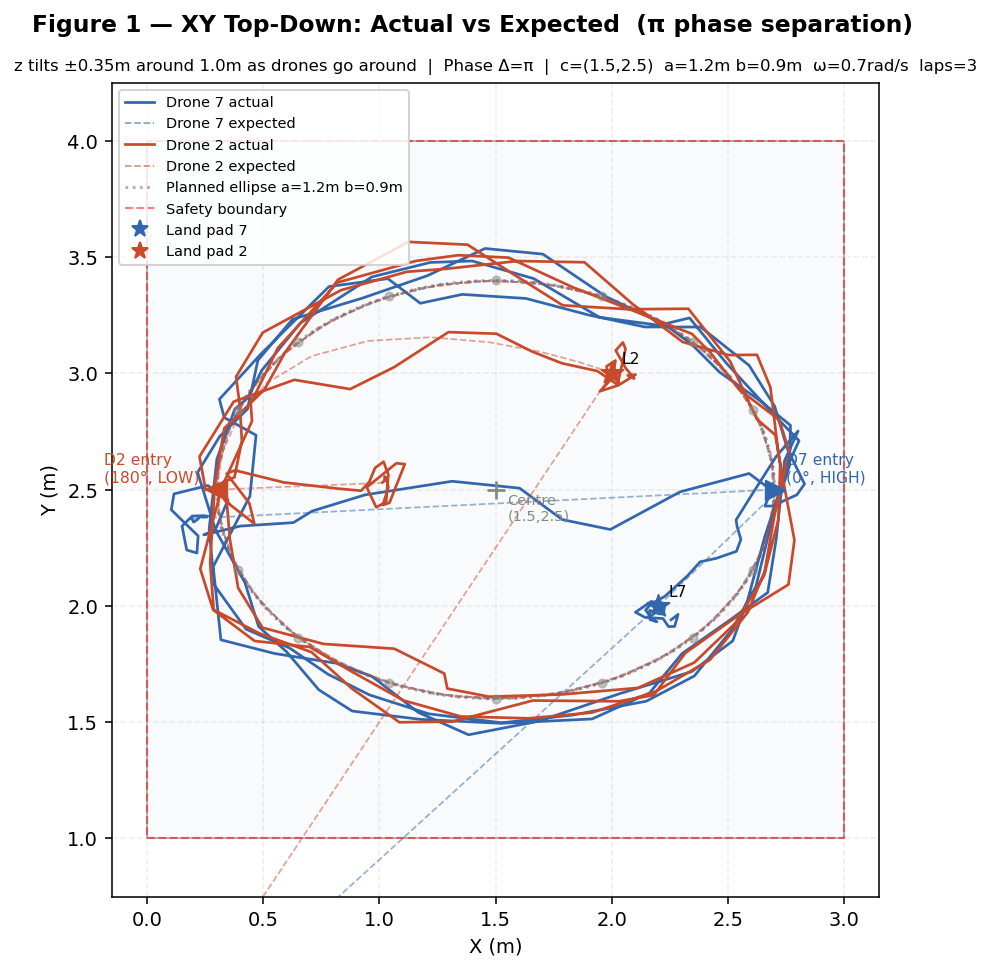

*01_xy_trajectory.png — tilted ellipse, both drones, XY top-down.*

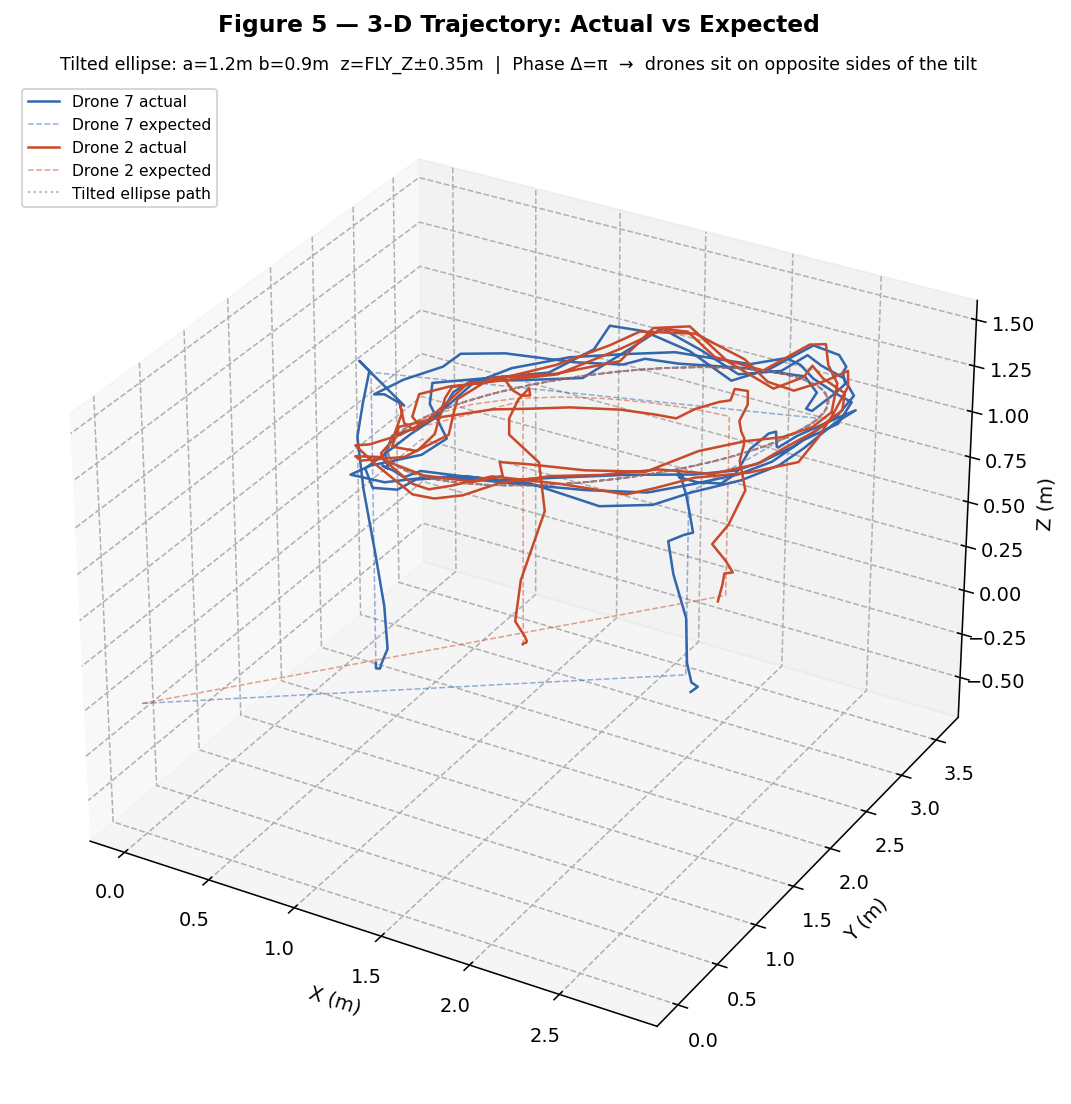

*05_trajectory_3d.png — 3D trajectory.*

In [ ]:
# Uncomment to run the tilted-ellipse script's own simulation mode:
# !python tilted_ellipse.py --sim --out ./tilted_ellipse_out


## 5. Swarming — Boids Algorithm

Source: `multi-drone/swarming/` in the repo. Decentralized swarm behaviour (separation, alignment, cohesion) validated in simulation before hardware deployment.


# Swarm Behaviour using Boids Algorithm

## Overview

This module implements decentralized swarm behaviour for multiple Crazyflie drones using the Boids algorithm. The objective is to enable autonomous collective motion through simple local interaction rules without centralized path planning.

The implementation was first validated in simulation before being deployed on physical hardware.

---

## Objectives

* Understand decentralized swarm intelligence.
* Implement Boids-based collective behaviour.
* Validate swarm algorithms in simulation.
* Deploy the algorithm on Crazyflie drones.

---

## Repository Contents

```text
swarming/
├── real_boids_swarm.py
├── plots/
├── logs/
└── README.md
```

---

## Swarm Rules

The Boids algorithm is based on three fundamental behaviours:

### Separation

Avoid collisions with neighbouring drones.

### Alignment

Match the heading and velocity of nearby drones.

### Cohesion

Move towards the local center of neighbouring drones.

The combination of these simple behaviours produces complex and coordinated swarm motion.

---

## Development Process

The swarm controller was initially developed and tested in Gazebo using ROS 2 and CrazySwarm to minimize hardware risks. After validating the behaviour in simulation, the implementation was transferred to the real Crazyflie platform.

---

## Results

The implemented swarm algorithm successfully demonstrated coordinated collective motion while maintaining collision avoidance and stable inter-drone spacing.

This work provides the foundation for future formation control and large-scale autonomous swarms.


In [ ]:
%%writefile real_boids_swarm.py
#!/usr/bin/env python3
"""
real_boids_swarm_square.py
===========================
Real-hardware Boids swarm for TWO Crazyflie drones via LPS positioning,
with integrated post-flight analysis plots.

Mission profile
---------------
  1. Both drones take off to their assigned altitude planes (0.3 m separation).
  2. Fly the four corners of a square path inside the safe zone:
       C0 (0.15, 1.15)  →  C1 (2.85, 1.15)
       C1 (2.85, 1.15)  →  C2 (2.85, 3.85)
       C2 (2.85, 3.85)  →  C3 (0.15, 3.85)
       C3 (0.15, 3.85)  →  C0 (0.15, 1.15)   ← closes the loop
  3. Run Boids swarm loop for 60 s (starting from C0 after the square).
  4. Navigate to dedicated landing pads and land:
       Drone 7  →  (2.2, 2.0)
       Drone 2  →  (2.0, 3.0)

Post-flight plots (auto-generated after landing)
-------------------------------------------------
  Figure 1 – XY plane       : actual vs expected trajectory (top-down)
  Figure 2 – X / Y / Z axes : position vs time, actual vs expected
  Figure 3 – RMS error      : per-axis bar charts + rolling 3-D RMS curve
  Figure 4 – Separation     : XY and 3-D inter-drone distance vs time
  Figure 5 – Boids forces   : sep / cohesion / wall / net magnitudes per tick

Hardware config
---------------
  Drone 7 : radio://0/80/2M/E7E7E7E7E7
  Drone 2 : radio://0/80/2M/E7E7E7E7E2
  Channel : 80 / 2M  (shared)

Safe zone (XY)
--------------
  X range : [0.0, 3.0]   Y range : [1.0, 4.0]   Z max : 1.2

Usage
-----
  # Simulate (no Crazyflie hardware needed):
  python real_boids_swarm_square.py --sim

  # Real hardware flight:
  python real_boids_swarm_square.py

  # Save plots to a custom folder:
  python real_boids_swarm_square.py --sim --out ./my_results

Dependencies
------------
  pip install cflib matplotlib numpy
"""

import time
import threading
import argparse
import os

import numpy as np
import matplotlib
matplotlib.use('Agg')          # headless-safe; switch to 'TkAgg' for live windows
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# ── Crazyflie imports (guarded so the script runs in plot-only / sim mode) ──
try:
    import cflib.crtp
    from cflib.crazyflie import Crazyflie
    from cflib.crazyflie.syncCrazyflie import SyncCrazyflie
    from cflib.crazyflie.log import LogConfig
    CF_AVAILABLE = True
except ImportError:
    CF_AVAILABLE = False

# =============================================================================
#  SECTION 1 — CONSTANTS  (shared by flight code AND plot code)
# =============================================================================

# Radio URIs
URI_7 = 'radio://0/80/2M/E7E7E7E7E7'
URI_2 = 'radio://0/80/2M/E7E7E7E7E2'

# Safe zone (absolute lab coordinates, metres)
SAFE_X_MIN, SAFE_X_MAX = 0.0, 3.0
SAFE_Y_MIN, SAFE_Y_MAX = 1.0, 4.0
SAFE_Z_MIN, SAFE_Z_MAX = 0.0, 1.2
CLAMP_MARGIN = 0.15
WALL_MARGIN  = 0.35

# Flight parameters
CRUISE_Z_7  = 0.6
CRUISE_Z_2  = 0.9
TAKEOFF_DUR = 2.5
LPS_SETTLE  = 4.0

# ── Square path corners (counter-clockwise, inset by CLAMP_MARGIN) ──────────
#   C0 = bottom-left   C1 = bottom-right
#   C3 = top-left      C2 = top-right
SQ_C0 = (SAFE_X_MIN + CLAMP_MARGIN, SAFE_Y_MIN + CLAMP_MARGIN)  # (0.15, 1.15)
SQ_C1 = (SAFE_X_MAX - CLAMP_MARGIN, SAFE_Y_MIN + CLAMP_MARGIN)  # (2.85, 1.15)
SQ_C2 = (SAFE_X_MAX - CLAMP_MARGIN, SAFE_Y_MAX - CLAMP_MARGIN)  # (2.85, 3.85)
SQ_C3 = (SAFE_X_MIN + CLAMP_MARGIN, SAFE_Y_MAX - CLAMP_MARGIN)  # (0.15, 3.85)
SQUARE_CORNERS = (SQ_C0, SQ_C1, SQ_C2, SQ_C3)

# Time (seconds) to fly each side of the square; sides are ~2.7 m long
SIDE_DUR = 5.0   # s per side  (≈ 0.54 m/s average ground speed)

# Landing pads
LAND_7 = (2.2, 2.0)
LAND_2 = (2.0, 3.0)

# Boids parameters
SEP_DIST     = 0.8
SEP_WEIGHT   = 1.5
COH_WEIGHT   = 0.4
WALL_WEIGHT  = 2.0
MAX_STEP     = 0.15
BOIDS_DT     = 0.20
MISSION_TIME = 60.0
RADIO_STAGGER = 0.10

# ── Timeline derived from the square (used by synthetic generator & plots) ──
# takeoff  : 0 → T_TAKEOFF_END
# entry    : T_TAKEOFF_END → T_ENTRY_END   (fly to C0 from spawn)
# square   : T_ENTRY_END  → T_SQ_END       (4 sides × SIDE_DUR)
# boids    : T_SQ_END     → T_BOIDS_END
# landnav  : T_BOIDS_END  → T_LANDNAV_END
# land     : T_LANDNAV_END → T_TOTAL
T_TAKEOFF_END  = 3.5
T_ENTRY_END    = 7.5
T_SQ_END       = T_ENTRY_END + 4 * SIDE_DUR          # 27.5 s
T_BOIDS_END    = T_SQ_END + MISSION_TIME              # 87.5 s
T_LANDNAV_END  = T_BOIDS_END + 4.5                   # 92.0 s
T_TOTAL        = T_LANDNAV_END + 4.5                  # 96.5 s

# Plot colour palette
C7  = '#3266ad'   # Drone 7 — blue
C2  = '#c94a2a'   # Drone 2 — coral
CG  = '#888780'   # neutral / reference
CA  = '#3a8a5a'   # green  — safe / corners
CB  = '#c4870a'   # amber  — cohesion
CW  = '#7f2b8a'   # purple — wall force

# =============================================================================
#  SECTION 2 — SHARED FLIGHT STATE
# =============================================================================

_state_lock = threading.Lock()

_drone_pos = {
    URI_7: np.array([1.0, 2.0, 0.0]),
    URI_2: np.array([2.0, 3.0, 0.0]),
}

_telem_lock = threading.Lock()
_telem = {
    URI_7: {'t': [], 'ax': [], 'ay': [], 'az': [],
            'ex': [], 'ey': [], 'ez': []},
    URI_2: {'t': [], 'ax': [], 'ay': [], 'az': [],
            'ex': [], 'ey': [], 'ez': []},
}
_t0_flight = None


def _log_telem(uri, t, actual_xyz, expected_xyz):
    with _telem_lock:
        d = _telem[uri]
        d['t'].append(float(t))
        d['ax'].append(float(actual_xyz[0])); d['ay'].append(float(actual_xyz[1])); d['az'].append(float(actual_xyz[2]))
        d['ex'].append(float(expected_xyz[0])); d['ey'].append(float(expected_xyz[1])); d['ez'].append(float(expected_xyz[2]))


def _telem_arrays(uri):
    with _telem_lock:
        d = _telem[uri]
        return {k: np.array(d[k]) for k in d}

# =============================================================================
#  SECTION 3 — FLIGHT UTILITIES
# =============================================================================

def _clamp(v, lo, hi):
    return max(lo, min(hi, v))


def _clip_to_safe(pos: np.ndarray, target_z: float) -> np.ndarray:
    cm = CLAMP_MARGIN
    return np.array([
        _clamp(pos[0], SAFE_X_MIN + cm, SAFE_X_MAX - cm),
        _clamp(pos[1], SAFE_Y_MIN + cm, SAFE_Y_MAX - cm),
        _clamp(pos[2], target_z - 0.05, target_z + 0.05),
    ])


def _wall_repulsion(pos: np.ndarray) -> np.ndarray:
    force = np.zeros(3)
    wm = WALL_MARGIN
    excess = (SAFE_X_MIN + wm) - pos[0];  force[0] += excess if excess > 0 else 0
    excess = pos[0] - (SAFE_X_MAX - wm);  force[0] -= excess if excess > 0 else 0
    excess = (SAFE_Y_MIN + wm) - pos[1];  force[1] += excess if excess > 0 else 0
    excess = pos[1] - (SAFE_Y_MAX - wm);  force[1] -= excess if excess > 0 else 0
    return force

# =============================================================================
#  SECTION 4 — BOIDS CORE
# =============================================================================

def _boids_next_target(my_uri: str, other_uri: str, my_target_z: float) -> np.ndarray:
    """Compute next waypoint using Boids rules, locked to the drone's altitude plane."""
    with _state_lock:
        me    = _drone_pos[my_uri].copy()
        other = _drone_pos[other_uri].copy()

    diff = me - other
    diff[2] = 0.0
    dist = np.linalg.norm(diff)

    # 1. Separation
    if dist < SEP_DIST and dist > 1e-4:
        sep_force = (diff / dist) * (SEP_DIST - dist)
    else:
        sep_force = np.zeros(3)

    # 2. Cohesion
    midpoint  = (me + other) / 2.0
    coh_force = midpoint - me
    coh_force[2] = 0.0

    # 3. Wall repulsion
    wall_force = _wall_repulsion(me)

    net = (SEP_WEIGHT  * sep_force +
           COH_WEIGHT  * coh_force +
           WALL_WEIGHT * wall_force)
    net[2] = 0.0

    norm = np.linalg.norm(net)
    if norm > MAX_STEP:
        net = net / norm * MAX_STEP

    return _clip_to_safe(me + net, my_target_z)

# =============================================================================
#  SECTION 5 — LPS POSITION READ
# =============================================================================

def _read_lps_position(cf) -> np.ndarray:
    print(f"  [LPS] Settling for {LPS_SETTLE} s ...")
    time.sleep(LPS_SETTLE)
    pos  = {}
    done = [False]

    def _cb(ts, data, lc):
        if not done[0]:
            pos['x'] = data.get('kalman.stateX', 0.0)
            pos['y'] = data.get('kalman.stateY', 0.0)
            pos['z'] = data.get('kalman.stateZ', 0.0)
            done[0]  = True

    lc = LogConfig(name='SpawnPos', period_in_ms=100)
    lc.add_variable('kalman.stateX', 'float')
    lc.add_variable('kalman.stateY', 'float')
    lc.add_variable('kalman.stateZ', 'float')
    cf.log.add_config(lc)
    lc.data_received_cb.add_callback(_cb)
    lc.start()

    t0 = time.time()
    while not done[0] and (time.time() - t0) < 6.0:
        time.sleep(0.05)
    lc.stop()

    if not done[0]:
        raise RuntimeError("LPS position read timed out.")
    return np.array([pos['x'], pos['y'], pos['z']])


def _start_position_tracking(cf, uri: str) -> 'LogConfig':
    def _cb(ts, data, lc):
        with _state_lock:
            _drone_pos[uri] = np.array([
                data.get('kalman.stateX', _drone_pos[uri][0]),
                data.get('kalman.stateY', _drone_pos[uri][1]),
                data.get('kalman.stateZ', _drone_pos[uri][2]),
            ])

    lc = LogConfig(name='PosTrack', period_in_ms=100)
    lc.add_variable('kalman.stateX', 'float')
    lc.add_variable('kalman.stateY', 'float')
    lc.add_variable('kalman.stateZ', 'float')
    cf.log.add_config(lc)
    lc.data_received_cb.add_callback(_cb)
    lc.start()
    return lc

# =============================================================================
#  SECTION 6 — PER-DRONE FLIGHT THREAD
# =============================================================================

def _drone_thread(uri: str,
                  other_uri: str,
                  ready_evt: threading.Event,
                  go_evt:    threading.Event,
                  stop_evt:  threading.Event):

    global _t0_flight
    label = uri[-1]
    my_cruise_z = CRUISE_Z_7 if uri == URI_7 else CRUISE_Z_2
    land_x, land_y = LAND_7 if uri == URI_7 else LAND_2

    print(f"\n[Drone {label}] Connecting to {uri} ...")
    try:
        with SyncCrazyflie(uri, cf=Crazyflie(rw_cache=f'./cache_{label}')) as scf:
            cf  = scf.cf
            hlc = cf.high_level_commander

            cf.param.set_value('commander.enHighLevel', '1')
            time.sleep(0.3)
            try:
                cf.supervisor.send_arming_request(True)
            except AttributeError:
                pass
            time.sleep(0.5)

            spawn = _read_lps_position(cf)
            with _state_lock:
                _drone_pos[uri] = spawn
            print(f"[Drone {label}] Spawned at: x={spawn[0]:.2f}  y={spawn[1]:.2f}  z={spawn[2]:.2f}")

            cm = CLAMP_MARGIN
            spawn_outside = not (
                SAFE_X_MIN + cm <= spawn[0] <= SAFE_X_MAX - cm and
                SAFE_Y_MIN + cm <= spawn[1] <= SAFE_Y_MAX - cm
            )
            if spawn_outside:
                entry_x = _clamp(spawn[0], SAFE_X_MIN + cm, SAFE_X_MAX - cm)
                entry_y = _clamp(spawn[1], SAFE_Y_MIN + cm, SAFE_Y_MAX - cm)
                print(f"[Drone {label}] ⚠ Spawn outside safe zone – entering at ({entry_x:.2f},{entry_y:.2f})")
            else:
                entry_x, entry_y = spawn[0], spawn[1]
                print(f"[Drone {label}] ✓ Spawn inside safe zone.")

            pos_log = _start_position_tracking(cf, uri)

            print(f"[Drone {label}] Ready – waiting for partner ...")
            ready_evt.set()
            go_evt.wait()

            t_flight_start = time.time()

            # ── Step 1: Takeoff ──────────────────────────────────────────────
            print(f"[Drone {label}] TAKEOFF → z={my_cruise_z:.2f} m")
            hlc.takeoff(my_cruise_z, TAKEOFF_DUR)
            time.sleep(TAKEOFF_DUR + 1.0)
            _log_telem(uri, time.time() - t_flight_start,
                       _drone_pos[uri], [spawn[0], spawn[1], my_cruise_z])

            # ── Step 2: Safe-zone entry (if spawned outside) ────────────────
            if spawn_outside:
                dur = max(3.0, (abs(entry_x - spawn[0]) + abs(entry_y - spawn[1])) / 0.4)
                hlc.go_to(entry_x, entry_y, my_cruise_z, yaw=0.0,
                          duration_s=dur, relative=False)
                time.sleep(dur + 0.8)
                _log_telem(uri, time.time() - t_flight_start,
                           _drone_pos[uri], [entry_x, entry_y, my_cruise_z])

            # ── Step 3: Fly to square start corner C0 ───────────────────────
            print(f"[Drone {label}] SQUARE START → C0 {SQ_C0}")
            hlc.go_to(SQ_C0[0], SQ_C0[1], my_cruise_z, yaw=0.0,
                      duration_s=4.0, relative=False)
            time.sleep(4.5)
            _log_telem(uri, time.time() - t_flight_start,
                       _drone_pos[uri], [SQ_C0[0], SQ_C0[1], my_cruise_z])

            # ── Step 4: Traverse all four sides of the square ───────────────
            #   C0 → C1 → C2 → C3 → C0
            corner_names = ['C1 (bottom-right)', 'C2 (top-right)',
                            'C3 (top-left)',     'C0 (bottom-left, close)']
            for corner, name in zip((SQ_C1, SQ_C2, SQ_C3, SQ_C0), corner_names):
                print(f"[Drone {label}] SQUARE → {name}  ({corner[0]:.2f},{corner[1]:.2f})  "
                      f"dur={SIDE_DUR:.0f}s")
                hlc.go_to(corner[0], corner[1], my_cruise_z, yaw=0.0,
                          duration_s=SIDE_DUR, relative=False)
                time.sleep(SIDE_DUR + 0.3)
                _log_telem(uri, time.time() - t_flight_start,
                           _drone_pos[uri], [corner[0], corner[1], my_cruise_z])

            # ── Step 5: Boids swarm loop (starting from C0) ─────────────────
            if uri == URI_2:
                time.sleep(RADIO_STAGGER)

            print(f"[Drone {label}] BOIDS START  mission={MISSION_TIME:.0f}s")
            t_start   = time.time()
            tick      = 0
            prev_tx, prev_ty = SQ_C0[0], SQ_C0[1]

            while not stop_evt.is_set():
                elapsed = time.time() - t_start
                if elapsed > MISSION_TIME:
                    break

                target = _boids_next_target(uri, other_uri, my_cruise_z)
                tx, ty, tz = float(target[0]), float(target[1]), float(target[2])

                hlc.go_to(tx, ty, tz, yaw=0.0,
                          duration_s=BOIDS_DT * 1.6, relative=False)

                _log_telem(uri,
                           time.time() - t_flight_start,
                           _drone_pos[uri].copy(),
                           [tx, ty, tz])

                tick += 1
                if tick % 10 == 0:
                    print(f"[Drone {label}] BOIDS t={elapsed:5.1f}s  "
                          f"({prev_tx:.2f},{prev_ty:.2f}) → ({tx:.2f},{ty:.2f})  z={tz:.2f}")
                prev_tx, prev_ty = tx, ty
                time.sleep(BOIDS_DT)

            # ── Step 6: Fly to assigned landing pad ─────────────────────────
            print(f"[Drone {label}] LAND-NAV → ({land_x:.2f},{land_y:.2f})")
            hlc.go_to(land_x, land_y, my_cruise_z, yaw=0.0,
                      duration_s=4.0, relative=False)
            time.sleep(4.5)
            _log_telem(uri, time.time() - t_flight_start,
                       _drone_pos[uri], [land_x, land_y, my_cruise_z])

            # ── Step 7: Controlled vertical landing ────────────────────────
            print(f"[Drone {label}] LANDING ↓")
            hlc.land(0.0, duration_s=4.0)
            time.sleep(4.5)
            _log_telem(uri, time.time() - t_flight_start,
                       _drone_pos[uri], [land_x, land_y, 0.0])
            hlc.stop()

            pos_log.stop()
            print(f"[Drone {label}] Landed safely.")

    except Exception as exc:
        print(f"[Drone {label}] ERROR: {exc}")
        stop_evt.set()
        ready_evt.set()
        raise

# =============================================================================
#  SECTION 7 — SYNTHETIC DATA GENERATOR  (sim mode / testing without hardware)
# =============================================================================

def _lcg(seed):
    """Deterministic LCG pseudo-RNG yielding values in [-1, 1]."""
    s = int(seed) & 0xFFFFFFFF
    while True:
        s = (s * 1664525 + 1013904223) & 0xFFFFFFFF
        yield (s >> 1) / 0x7FFFFFFF - 1.0


def generate_synthetic_mission(seed7=42, seed2=77):
    """
    Simulate the complete square-path mission for both drones.

    Phase timeline
    --------------
      takeoff  0         → T_TAKEOFF_END   (3.5 s)
      entry    3.5       → T_ENTRY_END     (7.5 s)
      square   7.5       → T_SQ_END        (27.5 s, 4 × 5 s sides)
      boids    T_SQ_END  → T_BOIDS_END     (+60 s)
      landnav  ...       → T_LANDNAV_END   (+4.5 s)
      land     ...       → T_TOTAL         (+4.5 s)

    Returns
    -------
    d7, d2 : dict of numpy arrays
        Keys: t, ax, ay, az (actual), ex, ey, ez (expected/planned)
    """
    rng7 = _lcg(seed7)
    rng2 = _lcg(seed2)
    dt   = BOIDS_DT
    N    = int(T_TOTAL / dt) + 2
    T    = np.arange(N) * dt

    def clamp(v, lo, hi): return float(np.clip(v, lo, hi))

    def ease(f):
        f = clamp(f, 0, 1)
        return 2f**2 if f < 0.5 else 1 - (-2f + 2)**2 / 2

    def lerp(t, t0, t1, v0, v1):
        return v0 + (v1 - v0) * ease((t - t0) / max(t1 - t0, 1e-6))

    # Square corner sequence with time windows
    # Each side: (start_corner, end_corner, t_start, t_end)
    sq_sides = []
    corners_seq = [SQ_C0, SQ_C1, SQ_C2, SQ_C3, SQ_C0]  # close the loop
    for i in range(4):
        t0_side = T_ENTRY_END + i * SIDE_DUR
        t1_side = t0_side + SIDE_DUR
        sq_sides.append((corners_seq[i], corners_seq[i+1], t0_side, t1_side))

    def square_expected(t):
        """Return (ex, ey) along the square path for time t."""
        for (c0, c1, ts, te) in sq_sides:
            if t <= te:
                ex = lerp(t, ts, te, c0[0], c1[0])
                ey = lerp(t, ts, te, c0[1], c1[1])
                return ex, ey
        return SQ_C0  # after loop closes

    def phase(t):
        if t <= T_TAKEOFF_END:  return 'takeoff'
        if t <= T_ENTRY_END:    return 'entry'
        if t <= T_SQ_END:       return 'square'
        if t <= T_BOIDS_END:    return 'boids'
        if t <= T_LANDNAV_END:  return 'landnav'
        return 'land'

    out7 = {k: [] for k in ('t','ax','ay','az','ex','ey','ez')}
    out2 = {k: [] for k in ('t','ax','ay','az','ex','ey','ez')}

    last_bx7, last_by7 = SQ_C0
    last_bx2, last_by2 = SQ_C0

    for i, t in enumerate(T):
        if t > T_TOTAL:
            break
        ph = phase(t)
        n7 = next(rng7)
        n2 = next(rng2)

        # ── expected (planned) positions ───────────────────────────────────
        if ph == 'takeoff':
            ex7, ey7 = 1.0, 2.0;  ez7 = lerp(t, 0, T_TAKEOFF_END, 0, CRUISE_Z_7)
            ex2, ey2 = 2.0, 3.0;  ez2 = lerp(t, 0, T_TAKEOFF_END, 0, CRUISE_Z_2)

        elif ph == 'entry':
            ez7, ez2 = CRUISE_Z_7, CRUISE_Z_2
            # Both drones converge on C0 from their spawn positions
            ex7 = lerp(t, T_TAKEOFF_END, T_ENTRY_END, 1.0, SQ_C0[0])
            ey7 = lerp(t, T_TAKEOFF_END, T_ENTRY_END, 2.0, SQ_C0[1])
            ex2 = lerp(t, T_TAKEOFF_END, T_ENTRY_END, 2.0, SQ_C0[0])
            ey2 = lerp(t, T_TAKEOFF_END, T_ENTRY_END, 3.0, SQ_C0[1])

        elif ph == 'square':
            ez7, ez2 = CRUISE_Z_7, CRUISE_Z_2
            # Both drones follow the same square but are offset in time
            # Drone 7 leads; Drone 2 lags by half a side (2.5 s)
            ex7, ey7 = square_expected(t)
            ex2, ey2 = square_expected(max(T_ENTRY_END, t - SIDE_DUR / 2))

        elif ph == 'boids':
            ez7, ez2 = CRUISE_Z_7, CRUISE_Z_2
            frac  = (t - T_SQ_END) / MISSION_TIME
            angle = frac * np.pi * 4
            r7 = 0.6 + 0.3 * np.sin(frac * np.pi * 2)
            r2 = 0.5 + 0.3 * np.cos(frac * np.pi * 2 + 1.2)
            cx, cy = 1.5, 2.5
            ex7 = clamp(cx + r7*np.cos(angle),        CLAMP_MARGIN, SAFE_X_MAX-CLAMP_MARGIN)
            ey7 = clamp(cy + r7*np.sin(angle),        SAFE_Y_MIN+CLAMP_MARGIN, SAFE_Y_MAX-CLAMP_MARGIN)
            ex2 = clamp(cx + r2*np.cos(angle+np.pi),  CLAMP_MARGIN, SAFE_X_MAX-CLAMP_MARGIN)
            ey2 = clamp(cy + r2*np.sin(angle+np.pi),  SAFE_Y_MIN+CLAMP_MARGIN, SAFE_Y_MAX-CLAMP_MARGIN)
            last_bx7, last_by7 = ex7, ey7
            last_bx2, last_by2 = ex2, ey2

        elif ph == 'landnav':
            ez7, ez2 = CRUISE_Z_7, CRUISE_Z_2
            ex7 = lerp(t, T_BOIDS_END, T_LANDNAV_END, last_bx7, LAND_7[0])
            ey7 = lerp(t, T_BOIDS_END, T_LANDNAV_END, last_by7, LAND_7[1])
            ex2 = lerp(t, T_BOIDS_END, T_LANDNAV_END, last_bx2, LAND_2[0])
            ey2 = lerp(t, T_BOIDS_END, T_LANDNAV_END, last_by2, LAND_2[1])

        else:  # land
            ex7, ey7 = LAND_7;  ez7 = lerp(t, T_LANDNAV_END, T_TOTAL, CRUISE_Z_7, 0.0)
            ex2, ey2 = LAND_2;  ez2 = lerp(t, T_LANDNAV_END, T_TOTAL, CRUISE_Z_2, 0.0)

        # ── actual = expected + realistic sensor noise ─────────────────────
        scale = 1.8 if ph == 'boids' else 0.8

        for d, ex, ey, ez, n in [(out7, ex7, ey7, ez7, n7), (out2, ex2, ey2, ez2, n2)]:
            d['t'].append(float(t))
            d['ex'].append(ex);  d['ey'].append(ey);  d['ez'].append(ez)
            d['ax'].append(ex + n0.04scale)
            d['ay'].append(ey + n0.03scale)
            d['az'].append(ez + n*0.025)

    def to_np(d): return {k: np.array(v) for k, v in d.items()}
    return to_np(out7), to_np(out2)

# =============================================================================
#  SECTION 8 — PLOT HELPERS
# =============================================================================

matplotlib.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'grid.linestyle': '--',
    'figure.dpi': 120,
    'lines.linewidth': 1.5,
    'savefig.bbox': 'tight',
    'savefig.dpi': 140,
})


def _rms(actual: np.ndarray, expected: np.ndarray) -> float:
    return float(np.sqrt(np.mean((actual - expected) ** 2)))


def _rolling_rms_3d(d, e, win):
    err2 = (d['ax']-e['ax'])**2 + (d['ay']-e['ay'])**2 + (d['az']-e['az'])**2
    kernel = np.ones(win) / win
    return np.sqrt(np.convolve(err2, kernel, mode='same'))


def _add_safezone(ax):
    w = SAFE_X_MAX - SAFE_X_MIN
    h = SAFE_Y_MAX - SAFE_Y_MIN
    rect = mpatches.FancyBboxPatch(
        (SAFE_X_MIN, SAFE_Y_MIN), w, h,
        boxstyle='square,pad=0', linewidth=1.0,
        edgecolor='#444', facecolor='#eef3f8', zorder=0, alpha=0.45)
    ax.add_patch(rect)


def _draw_square_path(ax):
    """Draw the planned square as a dashed grey box on an XY axes."""
    xs = [c[0] for c in SQUARE_CORNERS] + [SQ_C0[0]]
    ys = [c[1] for c in SQUARE_CORNERS] + [SQ_C0[1]]
    ax.plot(xs, ys, ':', color=CG, lw=1.0, alpha=0.6, zorder=1, label='Square path (planned)')


def _phase_vlines(ax, ymax):
    """Annotate mission phase boundaries as vertical dotted lines."""
    phases = [
        (T_TAKEOFF_END, 'Takeoff'),
        (T_ENTRY_END,   'Entry'),
        (T_ENTRY_END + SIDE_DUR,     'Sq C1'),
        (T_ENTRY_END + 2*SIDE_DUR,   'Sq C2'),
        (T_ENTRY_END + 3*SIDE_DUR,   'Sq C3'),
        (T_SQ_END,      'Boids'),
        (T_BOIDS_END,   'Land nav'),
    ]
    for tv, name in phases:
        ax.axvline(tv, color=CG, ls=':', lw=0.6, alpha=0.45)
        ax.text(tv + 0.3, ymax * 0.93, name, fontsize=6.5, color=CG, rotation=0)

# =============================================================================
#  SECTION 9 — INDIVIDUAL PLOT FUNCTIONS
# =============================================================================

def plot_xy(d7, d2, out_dir):
    """Figure 1: XY plane — actual vs expected (top-down view) with square overlay."""
    fig, ax = plt.subplots(figsize=(7, 7))
    fig.suptitle('Figure 1 — XY Plane: Actual vs Expected Trajectory (Square Path)', fontweight='bold')
    _add_safezone(ax)
    _draw_square_path(ax)

    every = 5
    for d, color, label in [(d7, C7, 'Drone 7'), (d2, C2, 'Drone 2')]:
        ax.plot(d['ex'][::every], d['ey'][::every], '--', color=color, lw=0.9, alpha=0.5)
        ax.plot(d['ax'][::every], d['ay'][::every], '-',  color=color, lw=1.4,
                label=f'{label} actual')

    # Square corners
    for i, (cx, cy) in enumerate(SQUARE_CORNERS):
        ax.scatter(cx, cy, marker='s', s=80, color=CA, zorder=5)
        ax.annotate(f'C{i}', (cx, cy), textcoords='offset points', xytext=(5, 5), fontsize=8)

    # Landing pads
    ax.scatter(LAND_7, marker='', s=130, color=C7, zorder=5, label='Land pad 7')
    ax.scatter(LAND_2, marker='', s=130, color=C2, zorder=5, label='Land pad 2')
    ax.annotate('L7', LAND_7, textcoords='offset points', xytext=(5, 5), fontsize=8)
    ax.annotate('L2', LAND_2, textcoords='offset points', xytext=(5, 5), fontsize=8)

    legend_handles = [
        Line2D([0],[0], color=C7, lw=1.4,  label='Drone 7 actual'),
        Line2D([0],[0], color=C7, lw=0.9, ls='--', alpha=0.6, label='Drone 7 expected'),
        Line2D([0],[0], color=C2, lw=1.4,  label='Drone 2 actual'),
        Line2D([0],[0], color=C2, lw=0.9, ls='--', alpha=0.6, label='Drone 2 expected'),
        Line2D([0],[0], color=CG, lw=1.0, ls=':', alpha=0.7, label='Square path (planned)'),
        Line2D([0],[0], marker='s', color=CA, lw=0, markersize=7, label='Square corners C0–C3'),
        Line2D([0],[0], marker='*', color=C7, lw=0, markersize=9, label='Land pad 7'),
        Line2D([0],[0], marker='*', color=C2, lw=0, markersize=9, label='Land pad 2'),
    ]
    ax.legend(handles=legend_handles, fontsize=8, loc='upper left', framealpha=0.85)
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
    ax.set_xlim(-0.15, 3.15); ax.set_ylim(0.75, 4.25)
    ax.set_aspect('equal')
    ax.set_title('Solid = LPS actual  |  Dashed = planned  |  □ = square corners', fontsize=9)

    plt.tight_layout()
    path = os.path.join(out_dir, '01_xy_trajectory.png')
    fig.savefig(path); plt.close(fig)
    print(f"  Saved: {path}")
    return path


def plot_axes(d7, d2, out_dir):
    """Figure 2: X, Y, Z position vs time with square-phase markers."""
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    fig.suptitle('Figure 2 — Per-Axis Position over Time: Actual vs Expected', fontweight='bold')
    every = 5
    T = d7['t'][::every]

    configs = [
        ('ax','ex', 'X position (m)', (SAFE_X_MIN-0.1, SAFE_X_MAX+0.1)),
        ('ay','ey', 'Y position (m)', (SAFE_Y_MIN-0.1, SAFE_Y_MAX+0.1)),
        ('az','ez', 'Altitude Z (m)', (-0.05, 1.05)),
    ]
    for ax, (ak, ek, ylabel, ylim) in zip(axes, configs):
        for d, color, label in [(d7,C7,'Drone 7'), (d2,C2,'Drone 2')]:
            ax.plot(T, d[ek][::every], '--', color=color, lw=0.9, alpha=0.5)
            ax.plot(T, d[ak][::every], '-',  color=color, lw=1.4, label=f'{label} actual')

        if ak == 'az':
            ax.axhline(CRUISE_Z_7, color=C7, ls=':', lw=0.8, alpha=0.6,
                       label=f'Cruise Z7={CRUISE_Z_7}m')
            ax.axhline(CRUISE_Z_2, color=C2, ls=':', lw=0.8, alpha=0.6,
                       label=f'Cruise Z2={CRUISE_Z_2}m')
            ax.fill_betweenx([CRUISE_Z_7, CRUISE_Z_2], T[0], T[-1],
                             alpha=0.05, color=CG, label='0.3 m Z separation')

        _phase_vlines(ax, ylim[1])
        ax.set_ylabel(ylabel); ax.set_ylim(*ylim)
        ax.legend(fontsize=7, ncol=2, loc='upper right', framealpha=0.8)

    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    path = os.path.join(out_dir, '02_xyz_axes.png')
    fig.savefig(path); plt.close(fig)
    print(f"  Saved: {path}")
    return path


def plot_rms(d7, d2, out_dir):
    """Figure 3: RMS error — per-axis bars + rolling 3D curve."""
    rms7 = {a: _rms(d7[f'a{a}'], d7[f'e{a}']) for a in ('x','y','z')}
    rms2 = {a: _rms(d2[f'a{a}'], d2[f'e{a}']) for a in ('x','y','z')}
    rms7['3D'] = float(np.sqrt(sum(rms7[a]**2 for a in ('x','y','z'))))
    rms2['3D'] = float(np.sqrt(sum(rms2[a]**2 for a in ('x','y','z'))))

    win   = 25   # ~5 s at 0.2 s/tick
    roll7 = _rolling_rms_3d(d7, d7, win)
    roll2 = _rolling_rms_3d(d2, d2, win)

    fig = plt.figure(figsize=(12, 8))
    fig.suptitle('Figure 3 — RMS Tracking Error Analysis', fontweight='bold')
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.3)

    bar_labels = ['X', 'Y', 'Z', '3D']
    key_labels = ['x', 'y', 'z', '3D']
    for idx, (drone_lbl, rms_d, color) in enumerate([('7', rms7, C7), ('2', rms2, C2)]):
        ax = fig.add_subplot(gs[0, idx])
        vals = [rms_d[k] for k in key_labels]
        bars = ax.bar(bar_labels, vals,
                      color=[color+'88']*3 + [color],
                      edgecolor=color, linewidth=0.8, width=0.5)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
                    f'{val*100:.2f} cm', ha='center', va='bottom', fontsize=8)
        ax.set_title(f'Per-Axis RMS — Drone {drone_lbl}')
        ax.set_ylabel('RMS error (m)')
        ax.set_ylim(0, max(vals) * 1.35)

    ax_roll = fig.add_subplot(gs[1, :])
    every = 5
    T7 = d7['t'][::every]; T2 = d2['t'][::every]
    ax_roll.plot(T7, roll7[::every], color=C7, lw=1.4, label='Drone 7 rolling 3D RMS')
    ax_roll.plot(T2, roll2[::every], color=C2, lw=1.4, label='Drone 2 rolling 3D RMS')
    ax_roll.fill_between(T7, roll7[::every], alpha=0.12, color=C7)
    ax_roll.fill_between(T2, roll2[::every], alpha=0.12, color=C2)
    _phase_vlines(ax_roll, max(roll7.max(), roll2.max()) * 1.1 or 0.15)
    ax_roll.set_xlabel('Time (s)'); ax_roll.set_ylabel('3D RMS error (m)')
    ax_roll.set_title(
        f'Rolling 3D RMS (win={win*BOIDS_DT:.0f}s) | '
        f'Drone7={rms7["3D"]*100:.2f}cm  Drone2={rms2["3D"]*100:.2f}cm')
    ax_roll.legend(fontsize=9)

    path = os.path.join(out_dir, '03_rms_error.png')
    fig.savefig(path); plt.close(fig)
    print(f"  Saved: {path}")
    return path, rms7, rms2


def plot_separation(d7, d2, out_dir):
    """Figure 4: Inter-drone XY and 3D separation vs time."""
    # Align arrays to the shorter one in case they differ by 1 sample
    n = min(len(d7['t']), len(d2['t']))
    sep_xy = np.sqrt((d7['ax'][:n]-d2['ax'][:n])**2 + (d7['ay'][:n]-d2['ay'][:n])**2)
    sep_3d = np.sqrt((d7['ax'][:n]-d2['ax'][:n])**2 +
                     (d7['ay'][:n]-d2['ay'][:n])**2 +
                     (d7['az'][:n]-d2['az'][:n])**2)
    T = d7['t'][:n]

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    fig.suptitle('Figure 4 — Inter-Drone Separation Distance', fontweight='bold')
    every = 5

    ax = axes[0]
    ax.plot(T[::every], sep_xy[::every], color=C7, lw=1.4, label='XY horizontal distance')
    ax.axhline(SEP_DIST, color=CA, ls='--', lw=1.0,
               label=f'Boids sep. threshold ({SEP_DIST}m)')
    ax.axhline(0.4, color=C2, ls='--', lw=1.0, label='Risk zone (< 0.4m)')
    ax.fill_between(T[::every], 0, np.minimum(sep_xy[::every], 0.4),
                    alpha=0.18, color=C2)
    ax.fill_between(T[::every], sep_xy[::every], SEP_DIST,
                    where=sep_xy[::every] < SEP_DIST, alpha=0.07, color=CA)
    _phase_vlines(ax, sep_xy.max() * 1.15)
    ax.set_ylabel('XY distance (m)')
    ax.set_ylim(0, sep_xy.max() * 1.20)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_title(
        f'Horizontal XY  |  min={sep_xy.min():.3f}m  avg={sep_xy.mean():.3f}m', fontsize=9)

    ax2 = axes[1]
    ax2.plot(T[::every], sep_3d[::every], color=CB, lw=1.4, label='3D Euclidean distance')
    ax2.axhline(0.3, color=CG, ls=':', lw=0.8, label='Z separation (0.3m)')
    _phase_vlines(ax2, sep_3d.max() * 1.15)
    ax2.set_ylabel('3D distance (m)')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylim(0, sep_3d.max() * 1.20)
    ax2.legend(fontsize=8, loc='upper right')
    ax2.set_title(
        f'3D Euclidean  |  min={sep_3d.min():.3f}m  Z-plane separation maintained at 0.3m',
        fontsize=9)

    plt.tight_layout()
    path = os.path.join(out_dir, '04_separation.png')
    fig.savefig(path); plt.close(fig)
    print(f"  Saved: {path}")
    return path


def plot_boids_forces(d7, out_dir):
    """Figure 5: Boids rule force magnitudes during the swarm phase."""
    T    = d7['t']
    mask = (T >= T_SQ_END) & (T <= T_BOIDS_END)
    px   = d7['ax'][mask]; py = d7['ay'][mask]
    t_b  = T[mask]

    # Approximate 'other' drone position (mirror around centroid)
    rng  = np.random.default_rng(42)
    ox   = np.clip(3.0 - px + rng.normal(0, 0.05, px.shape),
                   CLAMP_MARGIN, SAFE_X_MAX-CLAMP_MARGIN)
    oy   = np.clip(5.0 - py + rng.normal(0, 0.05, py.shape),
                   SAFE_Y_MIN+CLAMP_MARGIN, SAFE_Y_MAX-CLAMP_MARGIN)

    dist    = np.maximum(np.sqrt((px-ox)**2 + (py-oy)**2), 1e-4)
    sep_mag = np.where(dist < SEP_DIST, SEP_WEIGHT * (SEP_DIST - dist), 0.0)
    coh_mag = COH_WEIGHT * np.sqrt(((px+ox)/2 - px)**2 + ((py+oy)/2 - py)**2)

    wf  = np.zeros(len(px))
    wf += np.where(px < SAFE_X_MIN+WALL_MARGIN, WALL_WEIGHT*(SAFE_X_MIN+WALL_MARGIN-px), 0)
    wf += np.where(px > SAFE_X_MAX-WALL_MARGIN, WALL_WEIGHT*(px-(SAFE_X_MAX-WALL_MARGIN)), 0)
    wf += np.where(py < SAFE_Y_MIN+WALL_MARGIN, WALL_WEIGHT*(SAFE_Y_MIN+WALL_MARGIN-py), 0)
    wf += np.where(py > SAFE_Y_MAX-WALL_MARGIN, WALL_WEIGHT*(py-(SAFE_Y_MAX-WALL_MARGIN)), 0)
    net = np.minimum(np.sqrt((sep_mag+coh_mag)**2 + wf**2), MAX_STEP)

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    fig.suptitle(
        f'Figure 5 — Boids Force Magnitudes (Drone 7, Swarm Phase '
        f'{T_SQ_END:.0f}–{T_BOIDS_END:.0f} s)', fontweight='bold')

    every = 3
    ax = axes[0]
    ax.plot(t_b[::every], sep_mag[::every], color=C2, lw=1.2,
            label=f'Separation  (w={SEP_WEIGHT})')
    ax.plot(t_b[::every], coh_mag[::every], color=CA, lw=1.2,
            label=f'Cohesion    (w={COH_WEIGHT})')
    ax.plot(t_b[::every], wf[::every],      color=CW, lw=1.2,
            label=f'Wall repulsion (w={WALL_WEIGHT})')
    ax.set_ylabel('Force magnitude (m)')
    ax.legend(fontsize=9)
    ax.set_title('Individual Boids rule forces')

    ax2 = axes[1]
    ax2.plot(t_b[::every], net[::every], color=C7, lw=1.6, label='Net force (capped)')
    ax2.fill_between(t_b[::every], 0, net[::every], alpha=0.15, color=C7)
    ax2.axhline(MAX_STEP, color=CG, ls='--', lw=0.9,
                label=f'Max step cap ({MAX_STEP}m/tick)')
    ax2.set_ylabel('Net force (m/tick)')
    ax2.set_xlabel('Time (s)')
    ax2.legend(fontsize=9)
    ax2.set_title('Net combined force — applied displacement per Boids tick')

    plt.tight_layout()
    path = os.path.join(out_dir, '05_boids_forces.png')
    fig.savefig(path); plt.close(fig)
    print(f"  Saved: {path}")
    return path


def generate_all_plots(d7, d2, out_dir='.'):
    """Run all five plot functions and print the RMS summary table."""
    os.makedirs(out_dir, exist_ok=True)
    print('\n' + '='*60)
    print('  Post-Flight Analysis — Generating Plots')
    print('='*60)

    plot_xy(d7, d2, out_dir)
    plot_axes(d7, d2, out_dir)
    _, rms7, rms2 = plot_rms(d7, d2, out_dir)
    plot_separation(d7, d2, out_dir)
    plot_boids_forces(d7, out_dir)

    print()
    print('  ─── RMS Summary ────────────────────────────────────────')
    for lbl, rd in [('Drone 7', rms7), ('Drone 2', rms2)]:
        print(f'  {lbl}  X:{rd["x"]*100:.2f}cm  Y:{rd["y"]*100:.2f}cm  '
              f'Z:{rd["z"]*100:.2f}cm  →  3D total: {rd["3D"]*100:.2f}cm')
    print('  ────────────────────────────────────────────────────────')
    print(f'\n  ✓ All plots saved to "{os.path.abspath(out_dir)}"')
    print()

# =============================================================================
#  SECTION 10 — REAL FLIGHT MAIN
# =============================================================================

def run_real_flight(out_dir):
    if not CF_AVAILABLE:
        raise RuntimeError(
            "cflib not found. Install it with:  pip install cflib\n"
            "Or run in simulation mode:          python real_boids_swarm_square.py --sim")

    print('='*60)
    print('  Real-Hardware Swarm: Square Path + Boids + Landing Pads')
    print('='*60)
    print(f'  Drone 7  z={CRUISE_Z_7}m  land={LAND_7}')
    print(f'  Drone 2  z={CRUISE_Z_2}m  land={LAND_2}')
    print(f'  Square corners:  C0={SQ_C0}  C1={SQ_C1}  C2={SQ_C2}  C3={SQ_C3}')
    print(f'  Safe zone  X[{SAFE_X_MIN}, {SAFE_X_MAX}]  Y[{SAFE_Y_MIN}, {SAFE_Y_MAX}]')
    print('='*60)
    input('\nPress ENTER to verify anchors, spawn positions, and start: ')

    cflib.crtp.init_drivers()

    stop_evt = threading.Event()
    go_evt   = threading.Event()
    ready_7  = threading.Event()
    ready_2  = threading.Event()

    t7 = threading.Thread(
        target=_drone_thread,
        args=(URI_7, URI_2, ready_7, go_evt, stop_evt), daemon=True)
    t2 = threading.Thread(
        target=_drone_thread,
        args=(URI_2, URI_7, ready_2, go_evt, stop_evt), daemon=True)
    t7.start(); t2.start()

    ready_7.wait(timeout=90)
    ready_2.wait(timeout=90)

    if not ready_7.is_set() or not ready_2.is_set() or stop_evt.is_set():
        print('[Main] Pre-flight timeout or error. Terminating.')
        stop_evt.set()
        return

    print('[Main] Both drones ready. Synchronized departure in 3 s ...')
    time.sleep(3.0)
    go_evt.set()

    try:
        t7.join(); t2.join()
    except KeyboardInterrupt:
        print('\n[Main] Abort — forcing stop ...')
        stop_evt.set()
        t7.join(timeout=5); t2.join(timeout=5)

    print('\n[Main] Mission complete.')

    d7 = _telem_arrays(URI_7)
    d2 = _telem_arrays(URI_2)
    generate_all_plots(d7, d2, out_dir)

# =============================================================================
#  SECTION 11 — ENTRY POINT
# =============================================================================

def main():
    parser = argparse.ArgumentParser(
        description=(
            'Crazyflie Boids swarm — square path pre-flight + Boids loop + landing.\n'
            'Use --sim for a full simulation run without any hardware.'),
        formatter_class=argparse.RawDescriptionHelpFormatter)
    parser.add_argument('--sim',   action='store_true',
                        help='Simulate mission (no Crazyflie hardware required)')
    parser.add_argument('--out',   metavar='DIR', default='./plots',
                        help='Output directory for PNG plots (default: ./plots)')
    parser.add_argument('--show',  action='store_true',
                        help='Open plot windows interactively (needs a display)')
    parser.add_argument('--seed7', type=int, default=42,
                        help='RNG seed for Drone 7 position noise (default: 42)')
    parser.add_argument('--seed2', type=int, default=77,
                        help='RNG seed for Drone 2 position noise (default: 77)')
    args = parser.parse_args()

    if args.show:
        matplotlib.use('TkAgg')

    if args.sim:
        print('='*60)
        print('  Simulation mode — no hardware required')
        print(f'  Square: C0{SQ_C0} → C1{SQ_C1} → C2{SQ_C2} → C3{SQ_C3} → C0')
        print(f'  Each side: {SIDE_DUR}s  |  Total mission: ~{T_TOTAL:.0f}s')
        print('='*60)
        d7, d2 = generate_synthetic_mission(seed7=args.seed7, seed2=args.seed2)
        t_end = d7['t'][-1]
        print(f'  Generated {len(d7["t"])} samples  ({t_end:.1f}s)')
        generate_all_plots(d7, d2, args.out)
        if args.show:
            plt.show()
    else:
        run_real_flight(args.out)


if __name__ == '__main__':
    main()


In [ ]:
# Uncomment to run the Boids swarm script's own simulation mode:
# !python real_boids_swarm.py --sim --out ./boids_out


## 6. Trial Launch Scripts

Source: `trial_launchs/` in the repo — early standalone launch scripts used while getting the High-Level Commander working (simple hover, square path, 3D-space path, and a two-Crazyflie launch without ROS).


# Launch Scripts

## Overview

This directory contains utility launch scripts used throughout the project for initializing different Crazyflie experiments.

These scripts automate common tasks such as establishing communication, configuring flight parameters, and launching predefined experiments.

---

## Available Scripts

### `simple_launch.py`

Launches a basic single-drone experiment for testing communication and autonomous flight.

---

### `square_launch.py`

Launches a square trajectory experiment used during the initial stages of trajectory generation and controller evaluation.

---

### `3dspace_launch.py`

Launches experiments involving three-dimensional waypoint navigation and spatial trajectory execution.

---

### `two_cf_launch_without_ros.py`

Launch script for establishing communication with two Crazyflies using cflib without relying on the ROS 2 framework. This script was primarily used during the early stages of multi-drone development and debugging.

---

## Purpose

These launch scripts simplify experiment execution by reducing repetitive setup steps and ensuring consistent initialization across different flight tests.

They also serve as reusable entry points for future trajectory and swarm experiments.


In [ ]:
%%writefile simple_launch.py
# PYTHONPATH=../../src python3 autonomous_sequence_high_level.py
import time
import cflib.crtp
from cflib.crazyflie import Crazyflie
from cflib.crazyflie.syncCrazyflie import SyncCrazyflie
from cflib.utils import uri_helper
from cflib.positioning.position_hl_commander import PositionHlCommander

# 1. SET YOUR URI
URI = uri_helper.uri_from_env(default='radio://0/80/2M/E7E7E7E7E2')

def run_mission():
    cflib.crtp.init_drivers()

    # SyncCrazyflie opens the link and maintains the connection
    with SyncCrazyflie(URI, cf=Crazyflie(rw_cache='./cache')) as scf:
        
        # We DO NOT reset the estimator here. 
        # The LPS system will provide the absolute position automatically.
        # We just wait a moment for the drone to find its 'fix' from the anchors.
        print("Waiting for LPS position lock...")
        time.sleep(2) 

        # The High-Level Commander handles the takeoff and movement logic
        with PositionHlCommander(scf, default_height=0.5) as pc:
            
            # STEP 1: Fly from 'random' start point to the room origin
            print("Heading to Room Origin (0, 0, 0.5)...")
            pc.go_to(0.0, 0.0, 0.5)
            time.sleep(3) # Hover at (0,0) to show it found the spot
            # STEP 2: Execute your specific path

            print("Heading to Room Origin (0, 0, 0.5)...")
            pc.go_to(0.0, 0.0, 0.5)
            time.sleep(3)

            print("Moving to (0, 2, 0.5)...")
            pc.go_to(0.0, 2.0, 0.5)
            time.sleep(2)

            print("Heading to Room Origin (0, 0, 0.5)...")
            pc.go_to(0.0, 0.0, 0.5)
            time.sleep(3)

            print("Moving to (0, 4, 0.5)...")
            pc.go_to(0.0, 4.0, 0.5)
            time.sleep(2)

            # STEP 3: Return and land
            print("Returning to Origin for landing...")
            pc.go_to(0.0, 0.0, 0.5)
            pc.land()

if __name__ == '__main__':
    run_mission()


In [ ]:
%%writefile square_launch.py
import time
import cflib.crtp
from cflib.crazyflie import Crazyflie
from cflib.crazyflie.syncCrazyflie import SyncCrazyflie
from cflib.utils import uri_helper
from cflib.positioning.position_hl_commander import PositionHlCommander
from cflib.crazyflie.log import LogConfig
from cflib.crazyflie.syncLogger import SyncLogger

# 1. SET YOUR URI
URI = uri_helper.uri_from_env(default='radio://0/80/2M/E7E7E7E7E2')

def get_current_position(scf):
    """Captures the current LPS coordinates before takeoff"""
    log_config = LogConfig(name='Position', period_in_ms=10)
    log_config.add_variable('stateEstimate.x', 'float')
    log_config.add_variable('stateEstimate.y', 'float')
    log_config.add_variable('stateEstimate.z', 'float')

    pos = {'x': 0.0, 'y': 0.0, 'z': 0.0}

    with SyncLogger(scf, log_config) as logger:
        for log_entry in logger:
            data = log_entry[1]
            pos['x'] = data['stateEstimate.x']
            pos['y'] = data['stateEstimate.y']
            pos['z'] = data['stateEstimate.z']
            break 
    return pos

def run_mission():
    cflib.crtp.init_drivers()

    with SyncCrazyflie(URI, cf=Crazyflie(rw_cache='./cache')) as scf:
        
        print("Initializing... Waiting for LPS lock.")
        time.sleep(3) 

        # Identify Spawn Location
        spawn_pos = get_current_position(scf)
        print("-" * 40)
        print(f"SPAWN DETECTED AT: X={spawn_pos['x']:.2f}, Y={spawn_pos['y']:.2f}")
        print("-" * 40)

        # High-Level Commander handles takeoff and trajectory
        # default_height=0.5 ensures it takes off to 0.5m immediately
        with PositionHlCommander(scf, default_height=0.5) as pc:
            
            # STEP 1: Go to the Square Start Point
            print("Navigating from spawn to Square Start (0.0, 1.0, 0.5)...")
            pc.go_to(0.0, 1.0, 0.5)
            time.sleep(2)

            # STEP 2: Complete the Square
            print("Moving to Corner 2: (2.0, 1.0, 0.5)")
            pc.go_to(2.0, 1.0, 0.5)
            time.sleep(2)

            print("Moving to Corner 3: (2.0, 3.0, 0.5)")
            pc.go_to(2.0, 3.0, 0.5)
            time.sleep(2)

            print("Moving to Corner 4: (0.0, 3.0, 0.5)")
            pc.go_to(0.0, 3.0, 0.5)
            time.sleep(2)

            print("Closing the square: (0.0, 1.0, 0.5)")
            pc.go_to(0.0, 1.0, 0.5)
            time.sleep(2)

            # STEP 3: Landing
            print("Mission complete. Landing at start of square.")
            pc.land()

if _name_ == '_main_':
    run_mission()


In [ ]:
%%writefile 3dspace_launch.py
import time
import cflib.crtp

from cflib.crazyflie import Crazyflie
from cflib.crazyflie.syncCrazyflie import SyncCrazyflie
from cflib.positioning.position_hl_commander import PositionHlCommander
from cflib.utils import uri_helper

# -----------------------------
# RADIO URI
# -----------------------------
URI = uri_helper.uri_from_env(
    default='radio://0/80/2M/E7E7E7E7E2'
)

# -----------------------------
# CHECKPOINTS (LPS Anchor Areas)
# Define coordinates near anchors
# Modify these according to YOUR room
# -----------------------------

CHECKPOINTS = [
    (0.0, 0.5, 0.3),   # Anchor zone 0
    (0.0, 6.15, 2.0),   # Anchor zone 1
    (5.03, 6.15, 0.3),   # Anchor zone 2
    (5.03, 0.5, 2.0),   # Anchor zone 3

    (0.0, 0.5, 2.0),   # Anchor zone 4
    (0.0, 6.15, 0.3),   # Anchor zone 5
    (5.03, 6.15, 2.0),   # Anchor zone 6
    (5.03, 0.5, 0.3),   # Anchor zone 7
]

# This creates a cube-like trajectory


def fly_to_checkpoints(pc):
    """
    Fly through all anchor checkpoints
    """

    for i, point in enumerate(CHECKPOINTS):

        x, y, z = point

        print("-" * 40)
        print(f"Going to checkpoint {i+1}")
        print(f"X={x:.2f}, Y={y:.2f}, Z={z:.2f}")
        print("-" * 40)

        pc.go_to(x, y, z)

        # Wait for stabilization
        time.sleep(3)


def run_mission():

    print("Initializing CRTP drivers...")
    cflib.crtp.init_drivers()

    with SyncCrazyflie(
        URI,
        cf=Crazyflie(rw_cache='./cache')
    ) as scf:

        print("Connected to Crazyflie")
        print("Waiting for LPS positioning...")
        time.sleep(3)

        # High-level commander
        with PositionHlCommander(
            scf,
            default_height=0.5,
            default_velocity=0.4,
            default_landing_height=0.0
        ) as pc:

            print("Takeoff complete")

            # Fly through checkpoints
            fly_to_checkpoints(pc)

            print("Returning to start point...")
            pc.go_to(0.0, 2.0, 0.5)
            time.sleep(2)

            print("Landing...")
            pc.land()

    print("Mission completed.")


if __name__ == '__main__':
    run_mission()


In [ ]:
%%writefile two_cf_launch_without_ros.py
import time
import cflib.crtp

from cflib.crazyflie.swarm import CachedCfFactory
from cflib.crazyflie.swarm import Swarm
from cflib.crazyflie.log import LogConfig
from cflib.positioning.position_hl_commander import PositionHlCommander


uris = {
    'radio://0/80/2M/E7E7E7E701',
    'radio://0/80/2M/E7E7E7E702'
}


positions = {}


def start_position_logging(scf):

    uri = scf.cf.link_uri

    log_conf = LogConfig(
        name=f'Position_{uri[-3:]}',
        period_in_ms=500
    )

    log_conf.add_variable('stateEstimate.x', 'float')
    log_conf.add_variable('stateEstimate.y', 'float')
    log_conf.add_variable('stateEstimate.z', 'float')

    def log_callback(timestamp, data, logconf):

        positions[uri] = (
            round(data['stateEstimate.x'], 2),
            round(data['stateEstimate.y'], 2),
            round(data['stateEstimate.z'], 2)
        )

    scf.cf.log.add_config(log_conf)

    log_conf.data_received_cb.add_callback(log_callback)

    log_conf.start()


def takeoff_hover_land(scf):

    uri = scf.cf.link_uri

    try:

        with PositionHlCommander(
            scf,
            default_height=1.0,
            controller=PositionHlCommander.CONTROLLER_PID
        ) as pc:

            print(f"{uri} taking off")

            # hover safely
            time.sleep(3)

            print(f"{uri} landing")

        print(f"{uri} landed safely")

    except Exception as e:

        print(f"{uri} ERROR: {e}")

        try:
            scf.cf.commander.send_stop_setpoint()
        except:
            pass


if __name__ == '__main__':

    cflib.crtp.init_drivers()

    factory = CachedCfFactory(rw_cache='./cache')

    with Swarm(uris, factory=factory) as swarm:

        print("Connected to Crazyflies")

        # allow TWR stabilization
        time.sleep(15)

        print("Starting position logging")

        swarm.parallel_safe(start_position_logging)

        # wait for coordinates
        time.sleep(5)

        print("\nSPAWN LOCATIONS:\n")

        for uri, pos in positions.items():
            print(f"{uri} -> {pos}")

        print("\nStarting flight\n")

        swarm.parallel_safe(takeoff_hover_land)

        print("\nMission complete")

## 7. PID Tuning

From the report (section 3): the Crazyflie uses a **cascaded PID controller** (Position → Velocity → Attitude → Rate); only the **Position Controller** was tuned here.

| Term | Purpose |
|---|---|
| **P** | Reacts to current error, drives responsiveness |
| **I** | Removes steady-state error — too high caused accumulated error → overshoot & oscillation (the issue faced) |
| **D** | Reacts to rate of change of error, damps oscillation |

**Tuning process actually followed:**
1. 5 s hover test → check X/Y stability first.
2. Once X/Y stable, move to Z (altitude) — needed the most tuning on one of the two drones, which initially struggled to gain height and oscillated.
3. Move to square, then circular trajectories.
4. Change **one parameter at a time**, re-test after each change:
   - `I`: reduced from default **0.5 → 0.3** → less accumulated error, less overshoot, better Z stability.
   - `D`: increased slightly after confirming the `I` change helped → extra damping near waypoints, better Z stability.
   - `P`: left unchanged — drone already responded quickly; increasing further risked more oscillation.


## 8. Report Figures — Baseline vs. Tuned Flight Performance

These are the actual figures from the report (`Crazyflie_Craziness_2_0.docx`).

### 4.1 Baseline Flight Performance (Before Tuning)

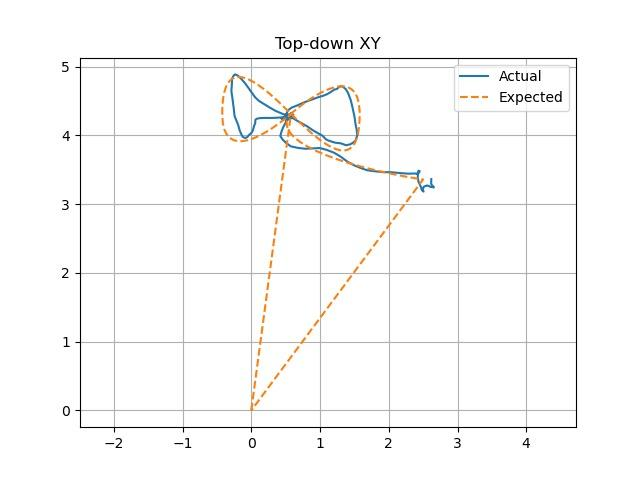

*Figure 1. Figure-8 trajectory — actual vs. expected path (single drone, baseline).*

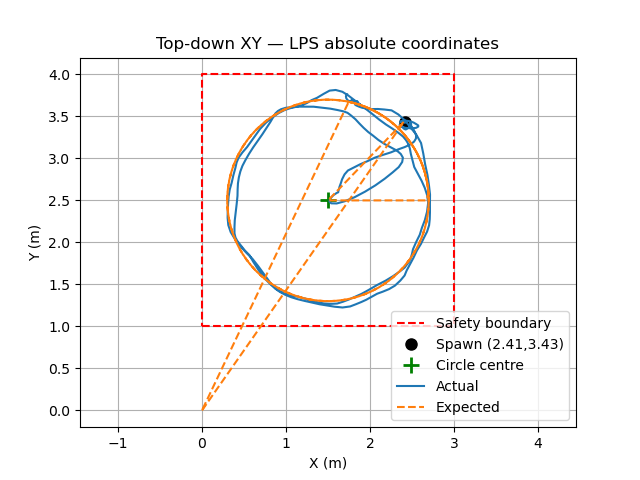

*Figure 2. Circle trajectory — actual vs. expected path, LPS absolute coordinates (baseline).*

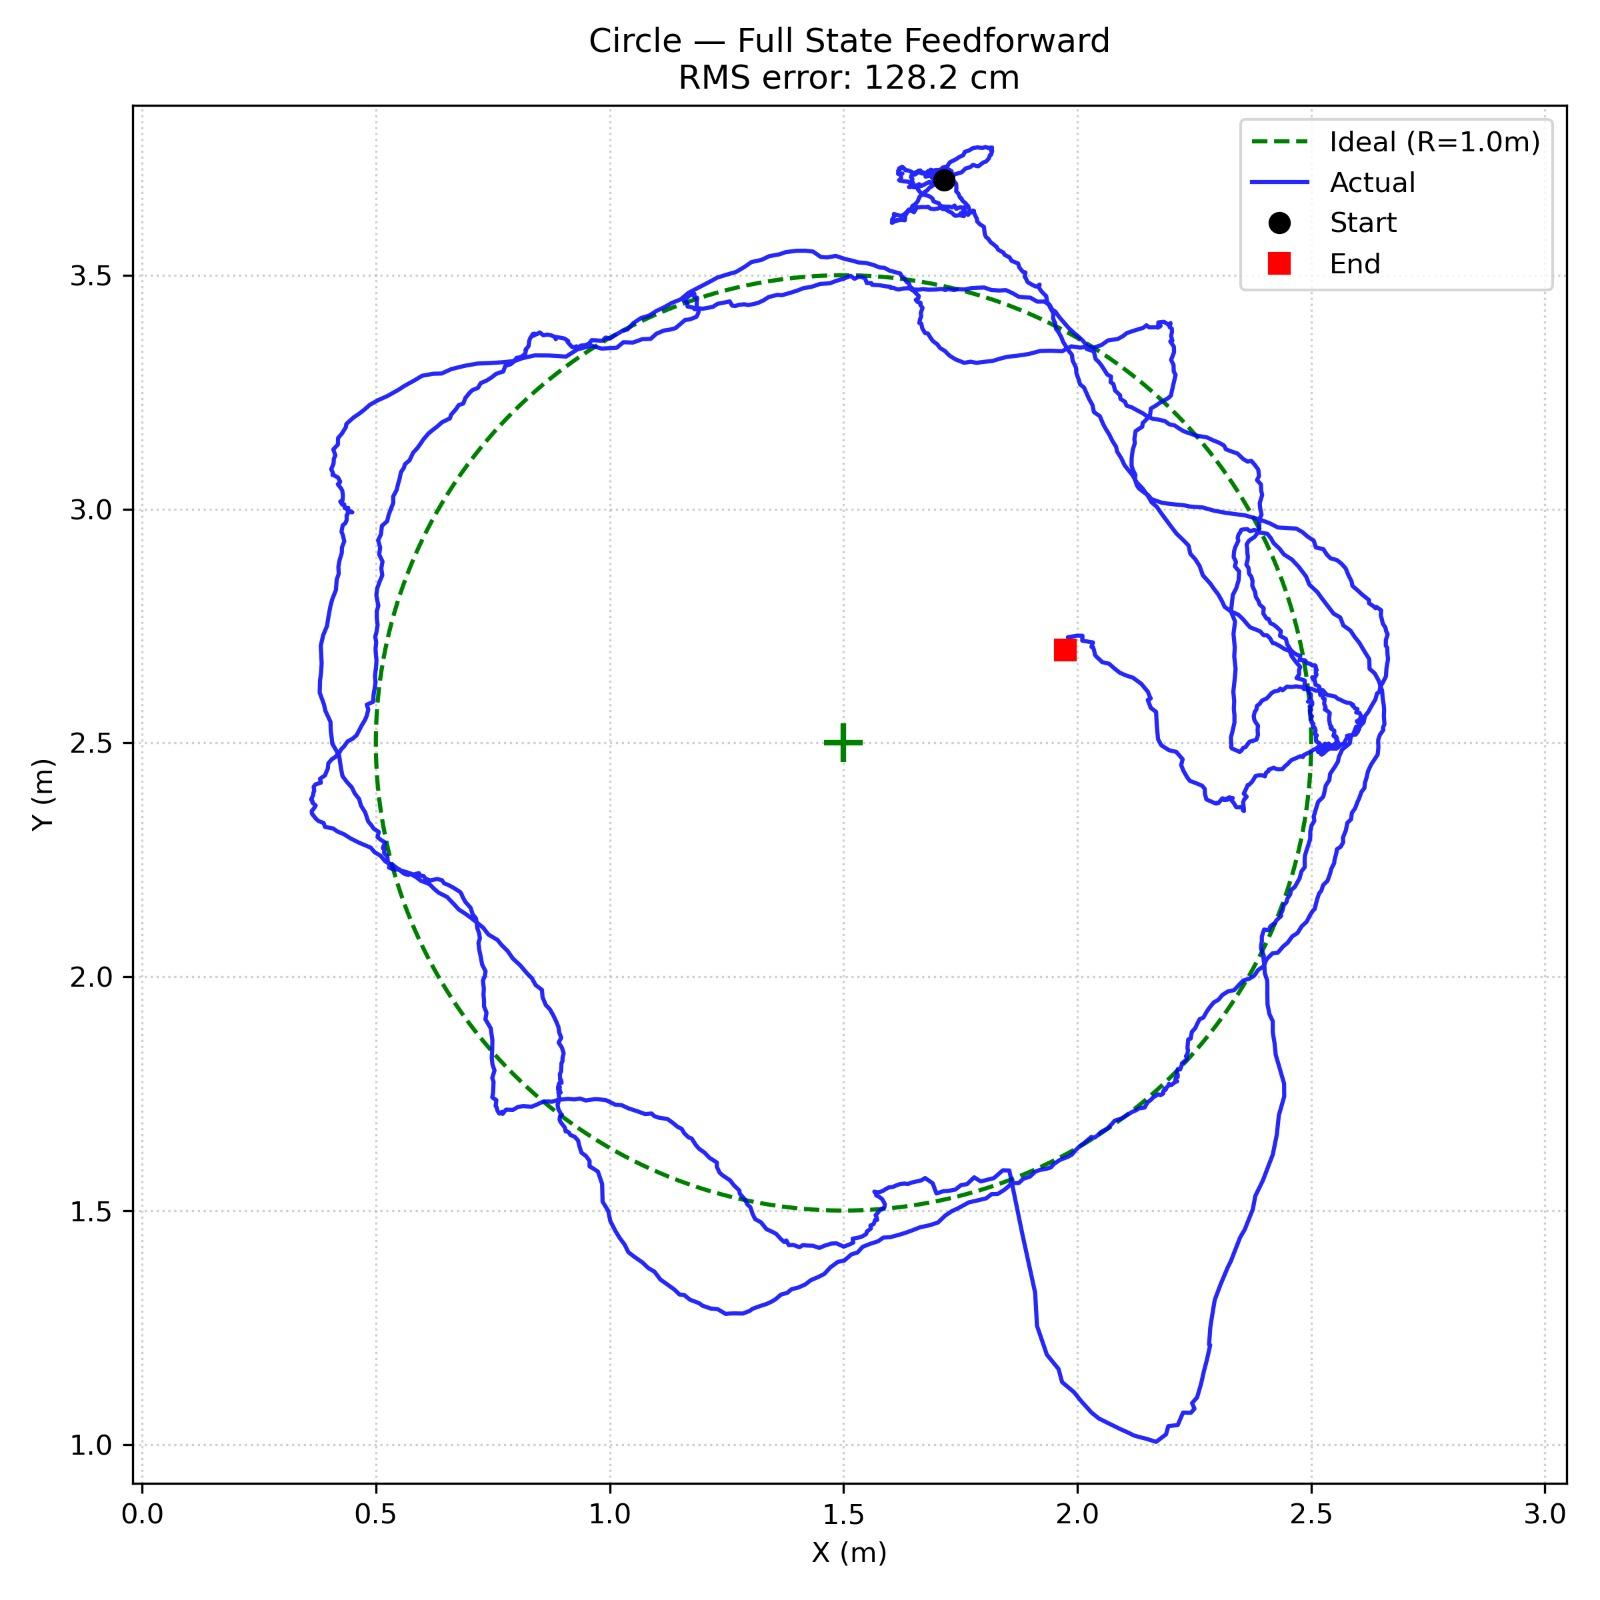

*Figure 3. Circle trajectory under full-state feedforward control — RMS error: 128.2 cm (baseline).*

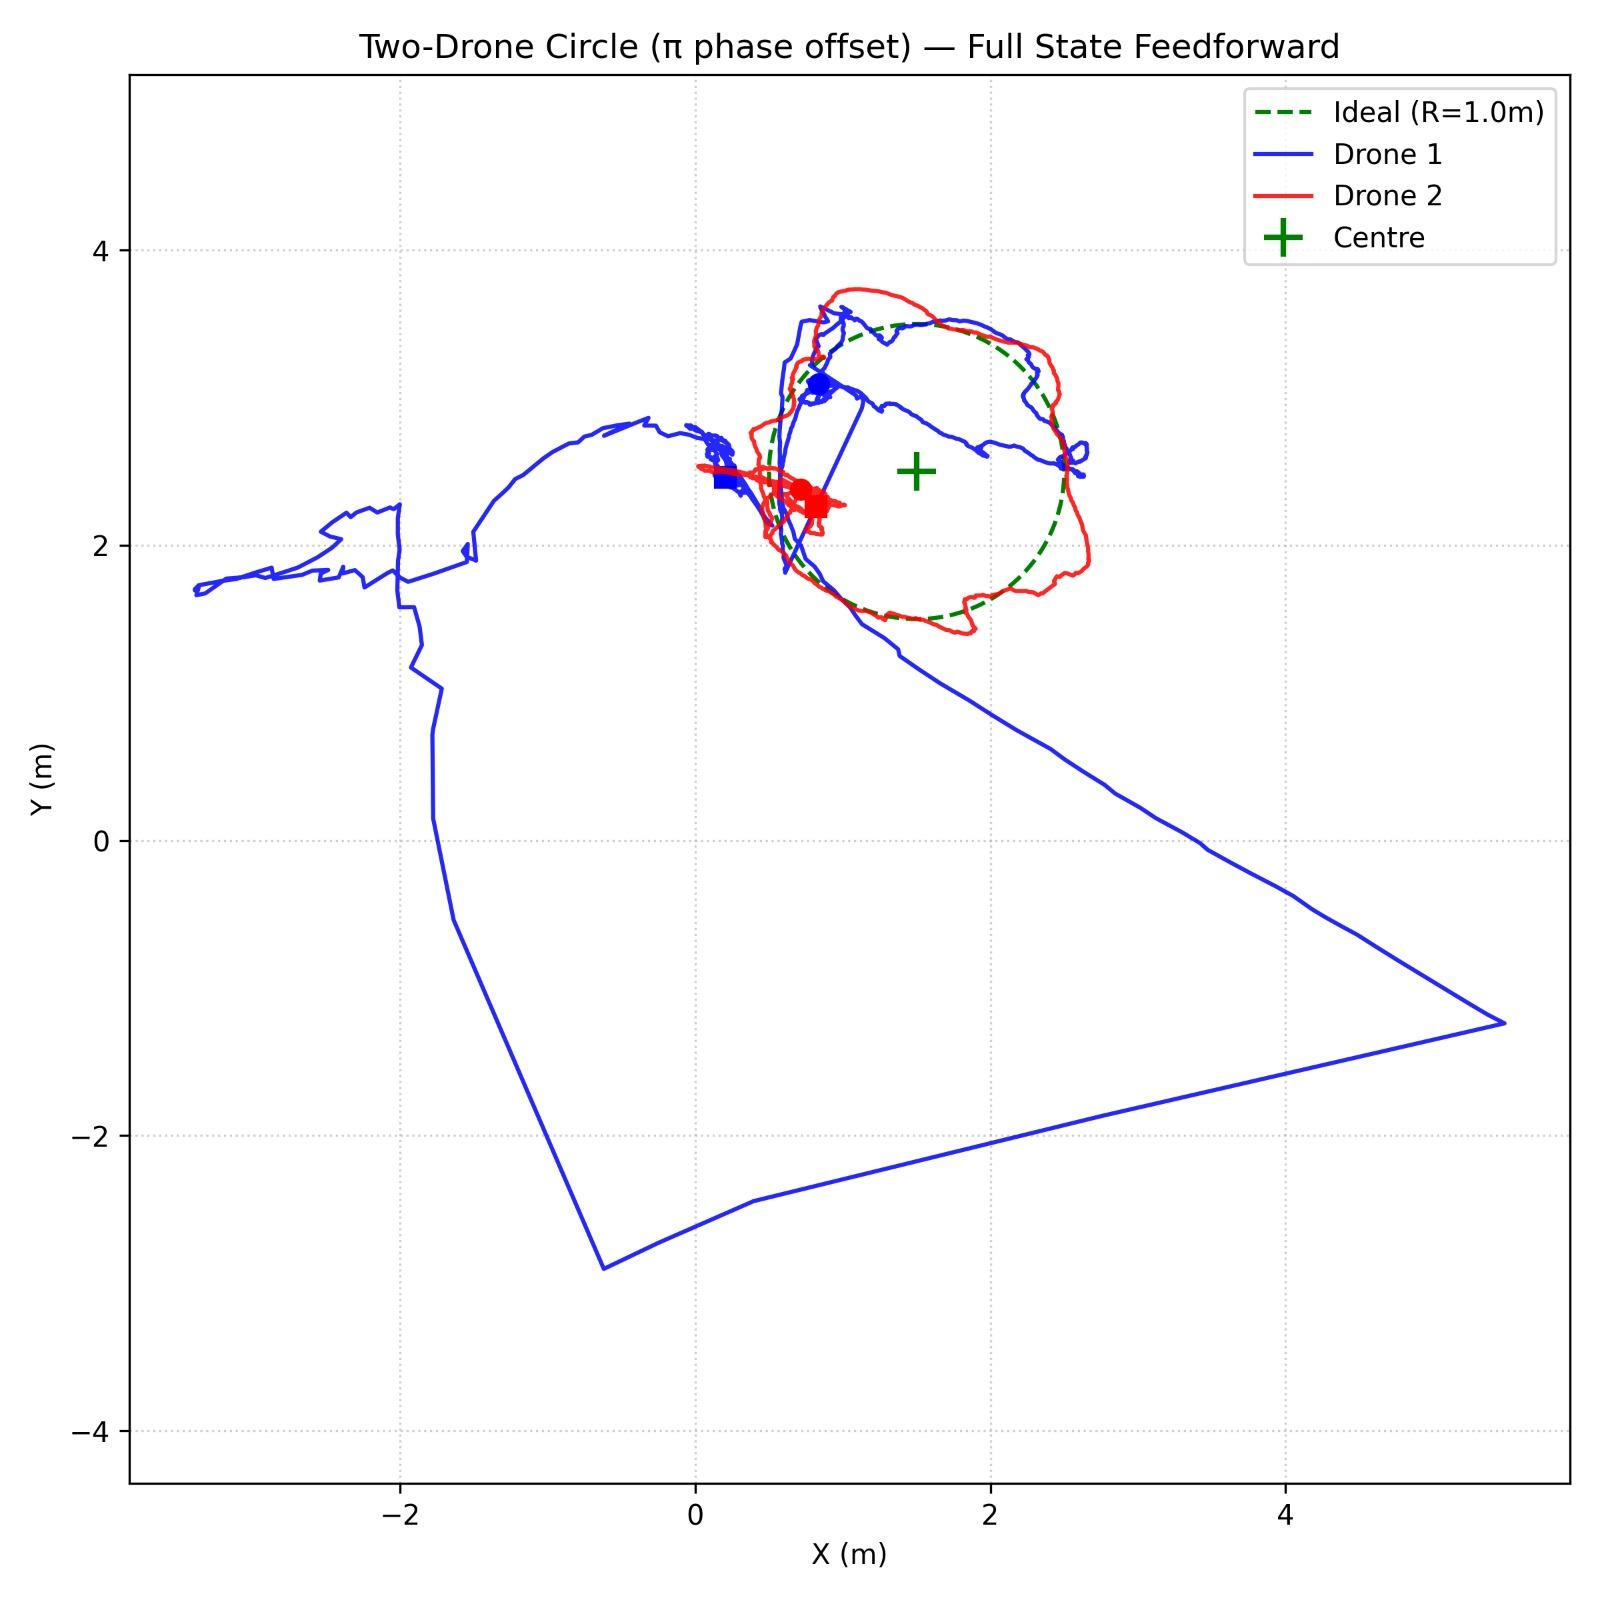

*Figure 4. Two-drone circle trajectory with π phase offset, full-state feedforward (baseline).*

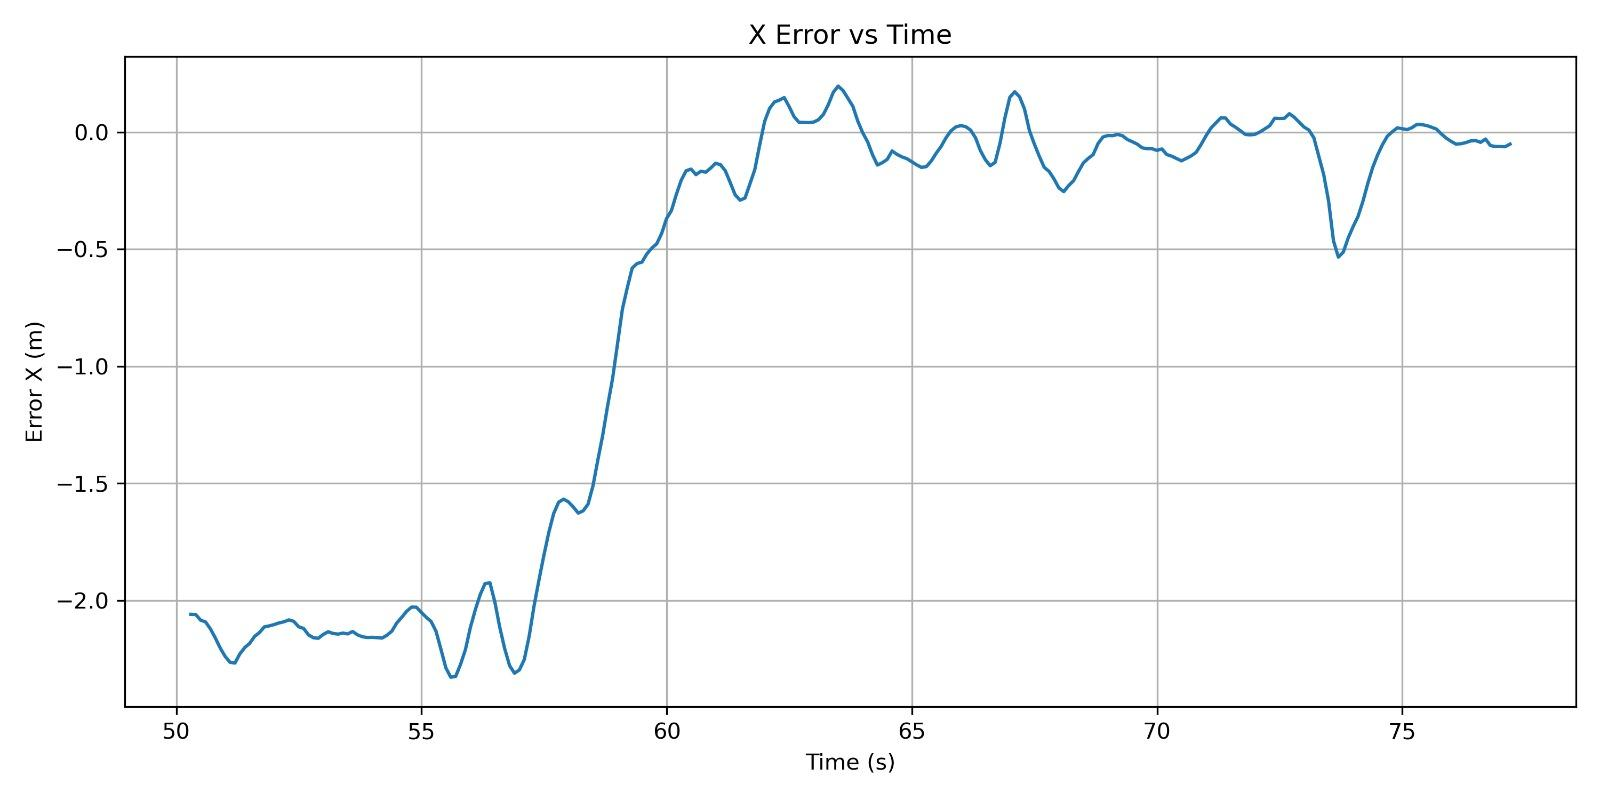

*Figure 5a. X-axis position error vs. time.*

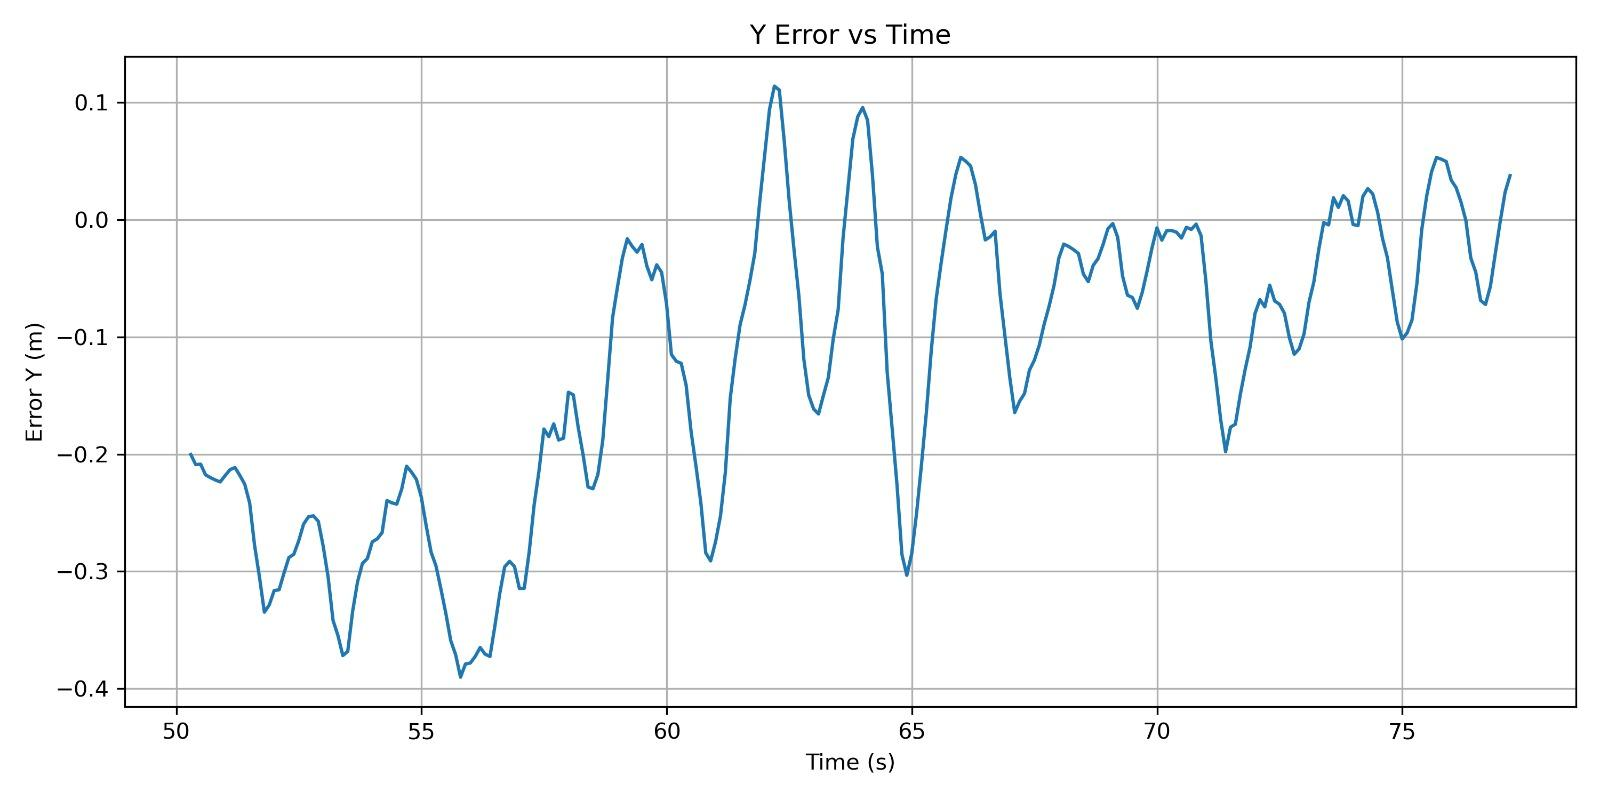

*Figure 5b. Y-axis position error vs. time.*

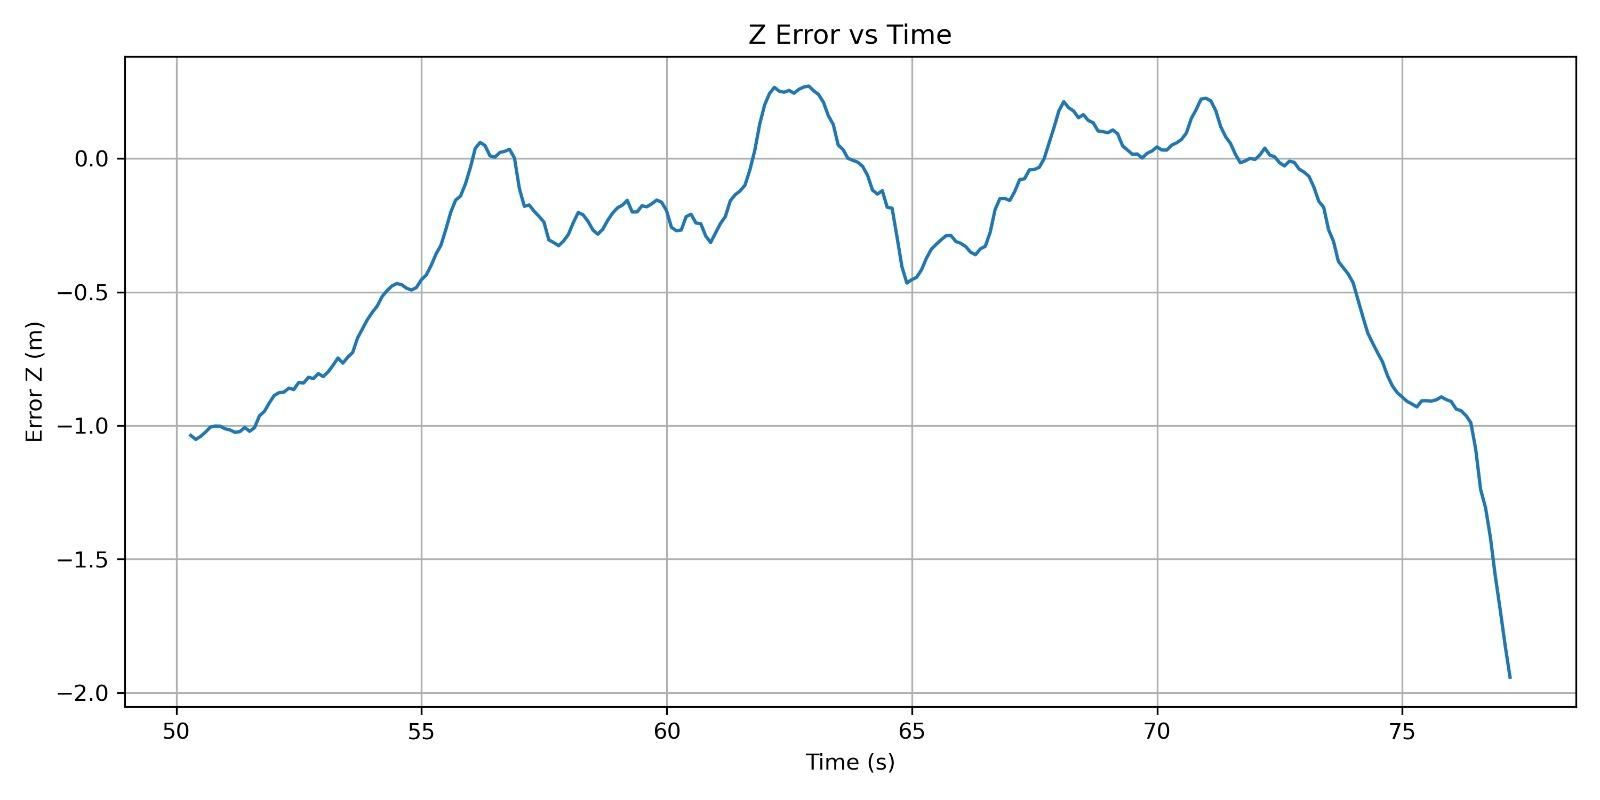

*Figure 5c. Z-axis position error vs. time.*

### 4.2 Optimized Trajectory Tracking (After Tuning)

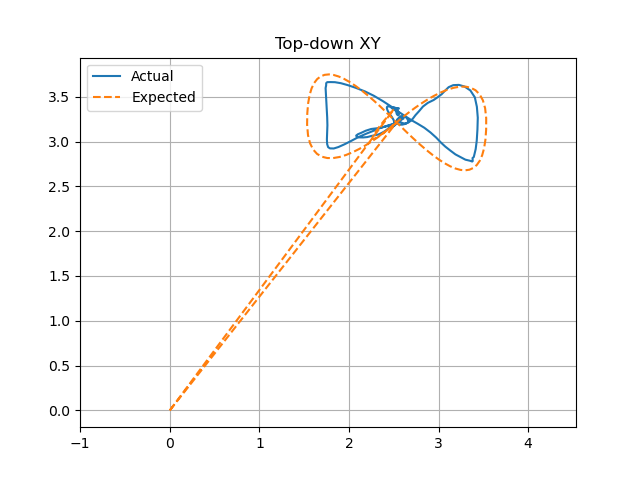

*Figure 6. Figure-8 trajectory — actual vs. expected path (single drone, after tuning).*

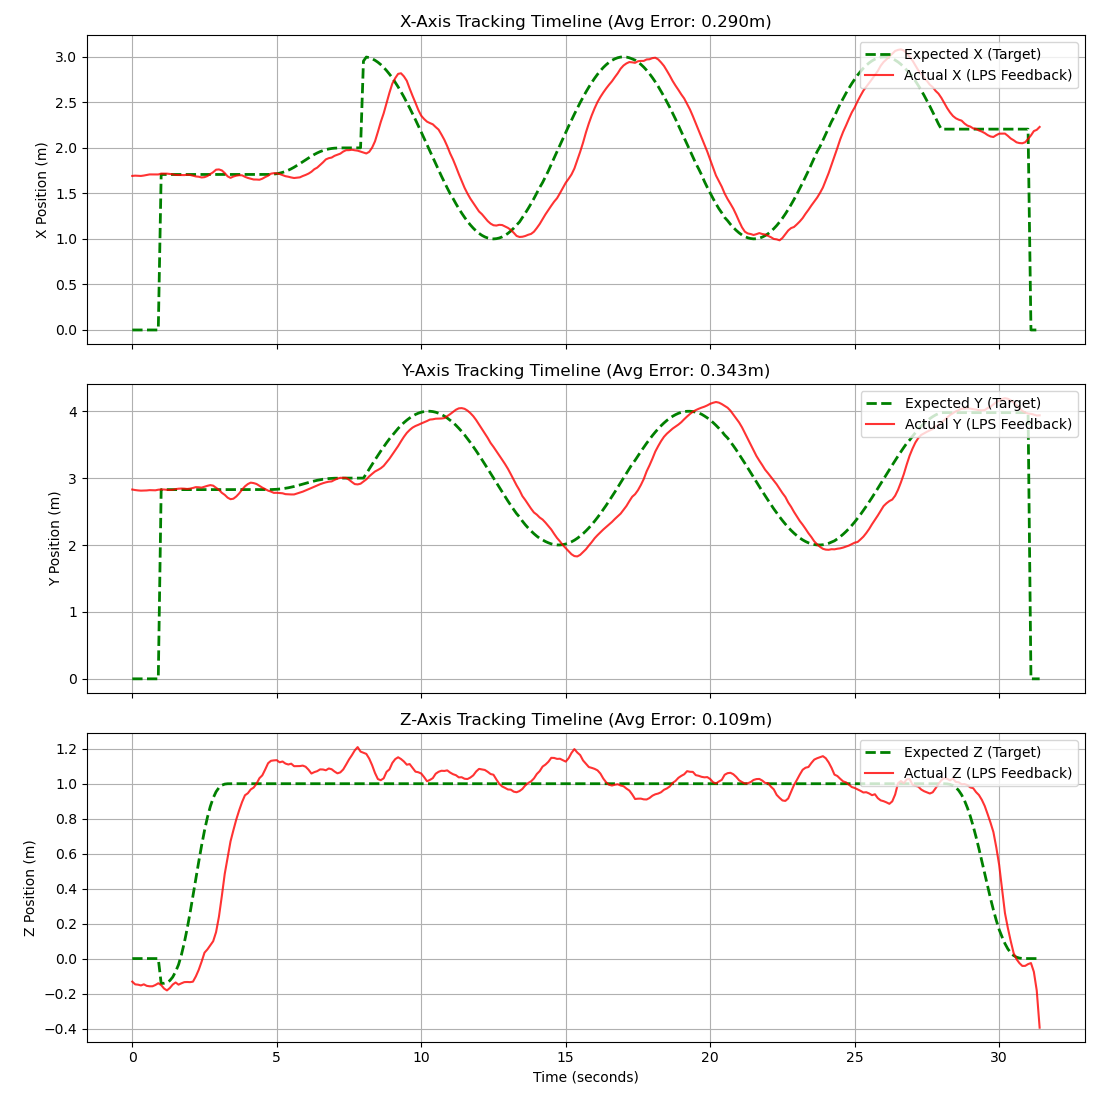

*Figure 7. Single drone — X, Y, and Z position vs. time (avg. error: X = 0.290 m, Y = 0.343 m, Z = 0.109 m).*

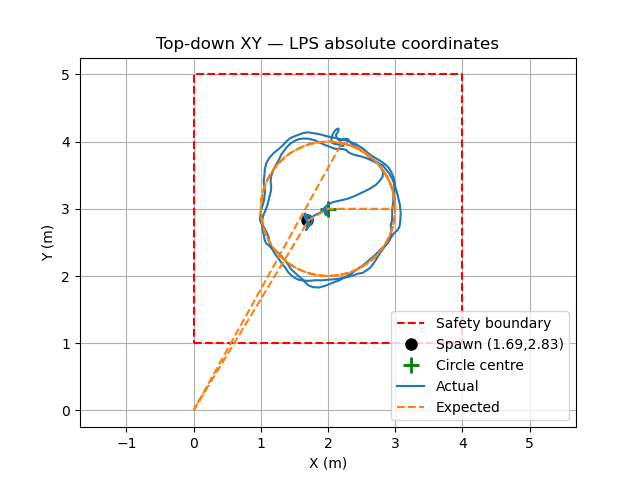

*Figure 8. Circle trajectory — actual vs. expected path, LPS absolute coordinates (after tuning).*

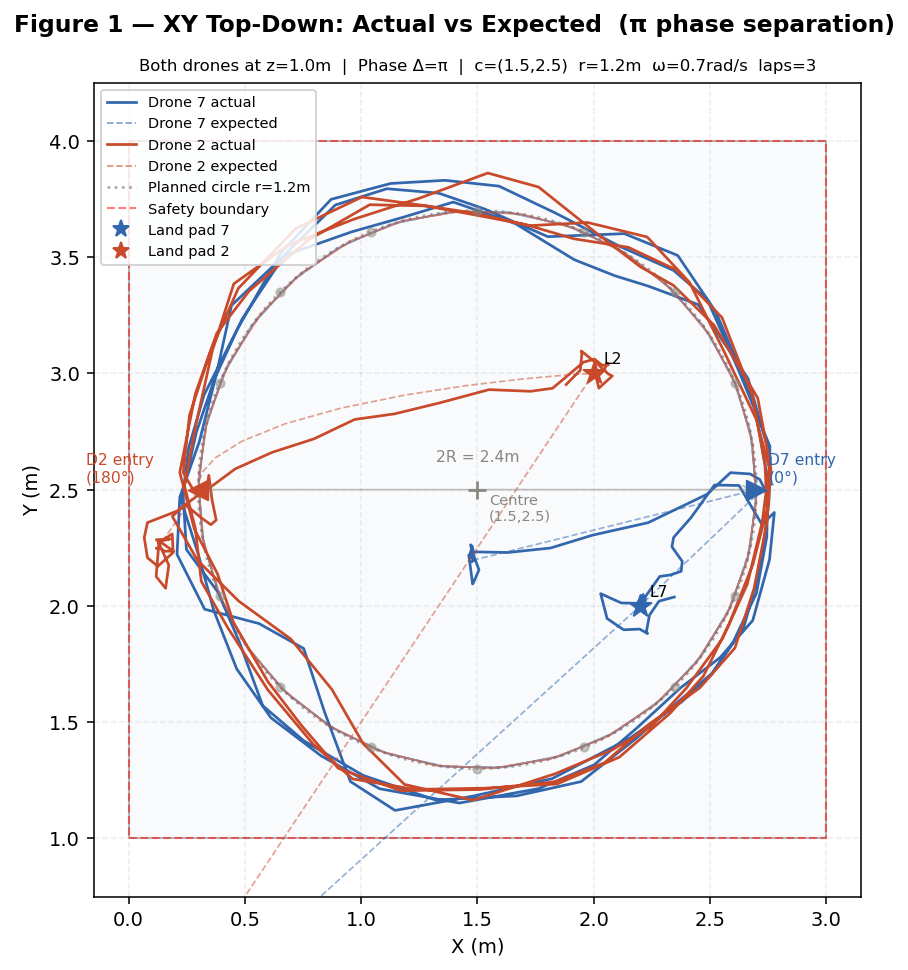

*Figure 9. Two-drone circle trajectory with π phase separation (after tuning).*

## 9. Common Issues & Troubleshooting

From the report (section 5):

**5.1 — UWB line-of-sight interference (TDoA2).** TDoA2 requires clear line-of-sight between all anchors and the drone; obstructions caused localization errors/garbage values and affected flight stability. Fixed by repositioning anchors closer to the testing area and ensuring no person/object blocked line-of-sight during flight. Firmware update/DSU flash on individual anchors can also help if the issue persists.

**5.2 — Drone charging.** Battery should always be fully charged before flight — a low battery reduces flight time and affects stability. Optimal results were seen flying after **4.0+ V**.

**5.3 — Position estimates.** Before takeoff, verify X/Y/Z in CFClient are stable and not unrealistic/rapidly changing. Incorrect estimates usually indicate LPS deck / anchor setup / positioning-mode issues — restarting the drone, reconnecting CFClient, and confirming TDoA2 mode typically resolves it.

**5.4 — Recovery after a crash.** Inspect for damaged propellers, loose components, or motor issues before flying again. Check motor variance in CFClient — should stay **below 15**; higher values may indicate a damaged propeller. Recover from the client also.
